# Swin2SR x4 — DIMER Guided Notebook: 4x image super-resolution (task inference, standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/swin2sr-x4-super-resolution-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/swin2sr-x4-super-resolution-pipeline/blob/main/tutorials/swin2sr_x4_super_resolution_colab.ipynb) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-caidas%2Fswin2SR--classical--sr--x4--64-ffcc4d?style=flat)](https://huggingface.co/caidas/swin2SR-classical-sr-x4-64) [![Upstream](https://img.shields.io/badge/Upstream-mv--lab%2Fswin2sr-181717?style=flat&logo=github&logoColor=white)](https://github.com/mv-lab/swin2sr) [![License](https://img.shields.io/badge/License-Apache--2.0-blue.svg)](https://www.apache.org/licenses/LICENSE-2.0)

**Profile:** `TASK-INFERENCE`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.2 — **standalone** (§4)  
**Capability:** 4x single-image super-resolution with a 12.2 M-parameter Swin2SR transformer (classical, bicubic degradation), scored with Y-channel PSNR and SSIM against bicubic and nearest-neighbour interpolation, plus reference-free inference on new images

**This notebook is standalone.** Section 2 carries the repository's package (4 modules under `src/swin2sr_x4_super_resolution_pipeline/`, at revision `c66e68e2d0f9`), the stage runner, the hash-locked requirements (45 packages), the snapshot manifest and the licence, and verifies every carried file against its SHA-256 before use, so the notebook keeps working after export even if the repository changes or disappears. Nothing is installed into the notebook kernel: a pinned `uv` (checked by size and SHA-256) builds an isolated Python environment from the lock with `--require-hashes`, and every stage runs there in its own process, so the hosted runtime's own packages are never replaced and no restart is needed. Its only external dependencies are PyPI, the managed CPython build that `uv` downloads, the Hugging Face Hub at the immutable revision `c69ef3e2d2ac5777ff4a9f2f5afcd86d20604b7e` (~49 MB, digest-verified before loading), and the public sample-data bucket named in the Prerequisites. It was generated by `tools/build_notebook.py` (build_notebook.py/3.0); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh Linux runtime — a Colab or Kaggle T4 GPU is recommended, a CPU-only runtime also works but is slower — builds an isolated Python environment from the carried hash-locked requirements (torch, transformers, safetensors, huggingface-hub, numpy, pillow and their dependencies) without touching the notebook kernel's own packages, then runs each stage below in its own process: it stages and digest-verifies the pinned 49 MB Swin2SR x4 snapshot from the Hub, fetches 27 CC0 iNaturalist photographs as digest-verified JPEGs (2.5 MB, no credential), turns 24 of them into 320 px references with 80 px inputs by 4x bicubic downsampling and validates every pair, upscales the 24 inputs and scores the model beside bicubic and nearest-neighbour interpolation with Y-channel PSNR and SSIM (4 px border crop) and a seeded bootstrap over images, upscales three native photo crops and a seeded synthetic scene that have no reference, and writes the panels, per-image scores, predictions and a provenance record under `outputs/`. The default path needs no repository clone, no DIMER worker or service, no credential, no upload dialog, no configuration edit and no runtime restart (NOTEBOOK_SPEC 2.2 §5). The recorded hosted run (Google Colab, Tesla T4, 5 October 2026, default fields, notebook generated from revision `a112444`) built the isolated environment in 86 s and spent about 43 s in the model stages; a second **Run all** in the same runtime reuses that environment.

**Bring Your Own Data:** After the default path completes, Section 8 lets you run the same validation, inference and output contract on your own images: set `USE_BYOD = True`, choose `BYOD_MODE` — `'hr'` when your image is the sharp original (it is cropped to a multiple of 4 px if needed, downsampled 4x by bicubic interpolation, upscaled and scored against itself and the two baselines) or `'lr'` when your image is the small input (it is upscaled only; nothing can be scored) — and either set `BYOD_PATH` to an image, folder or zip already in the runtime or leave it empty to get an upload dialog. The schema, the size limits and the privacy guidance are stated in the Prerequisites and in Section 8; uploaded files stay inside this runtime. BYOD is optional and never part of the default path.

Swin2SR (Conde et al., 2023) is a SwinV2 transformer (Liu et al., 2022) for image restoration. The checkpoint this notebook pins (named in Section 3) is the *classical* 4x super-resolution variant: it was trained to undo one known degradation — a sharp photograph shrunk 4x with bicubic interpolation — so it receives an `H × W` RGB image and returns a `4H × 4W` image in a single forward pass. Every input pixel is a token (`patch_size` 1), self-attention runs inside 8 × 8 windows over six residual groups, and a pixel-shuffle head rearranges channels into the 16 × larger output.

Two properties of the task shape this notebook. **Super-resolution has a ground truth only when you made the input yourself**: the notebook takes sharp photographs, shrinks them 4x, and asks the model to recover them, so the original is the reference. **The detail it adds is a prediction, not a recovery**: on an image that was never downscaled from a sharper one there is nothing to compare against, so Section 6 reports outputs without a score. Nothing is trained here: this is a pretrained model used as published, which is why the profile is task inference.

**Learning objectives:** by the end of this notebook you will be able to —

1. **Explain** the input → output contract of 4x super-resolution and why the window padding is added and cropped off (Sections 4–5).
2. **Diagnose** an invalid low-/high-resolution pair from a validation refusal before any model runs (Section 4).
3. **Compute and interpret** Y-channel PSNR and SSIM with a border crop, and **compare** the model with bicubic and nearest-neighbour interpolation on identical inputs (Section 5).
4. **Distinguish** a mean difference from its spread across images using a paired bootstrap (Section 5).
5. **Apply** the model to new images that have no reference and **identify** what can and cannot be claimed about them (Section 6).
6. **Predict**, run and **explain** how a mismatched degradation changes the model's advantage over bicubic, in an optional activity (Section 7).
7. **Write** an evidence-based conclusion that names the baseline, the spread and the limits of 24 photographs (Interpretation and conclusion).

**This notebook does not demonstrate:** x2 or x3 upscaling (the x2 checkpoint has its own repository), fine-tuning, compressed-input or real-world restoration (other upstream Swin2SR checkpoints that are not packaged here), face or text restoration, video, tiled inference of images larger than 256 px, perceptual or no-reference quality metrics, and any claim that PSNR or SSIM measures how good an image looks to a person. The repository exposes none of these.

## How to use this notebook

**Who this notebook is for.** Learners who can open a hosted notebook (Google Colab or Jupyter), run cells in order and read short Python, and who want to see how an image super-resolution model is checked against simple baselines. No prior experience with super-resolution is assumed: each term is explained where it is first needed, and the glossary below collects them. A GPU is recommended but not required; the **Prerequisites** give the details.

**Running it.** In Colab, optionally choose *Runtime → Change runtime type → T4 GPU*, then *Runtime → Run all*. The default path needs no edit, no upload, no account, no token and no runtime restart. Sections 1–3 build an isolated environment from hash-locked packages before any model runs (about 90 s in the recorded T4 run; a later Run all in the same runtime reuses the environment); read ahead while they finish, or run the notebook one cell at a time with *Shift + Enter*. Re-running the Section 1 cell on its own is safe: it keeps this session's run directory, so the cells after it keep working.

**Where the code runs.** The notebook kernel installs nothing and imports no model library. Each learner cell calls `run_stage('…')`, which runs one stage of the carried stage runner in its own process with the isolated environment's Python, streams what it prints, and stops the notebook with the stage's own error message if it fails. Stages hand results to each other only through files in the run directory: the verified snapshot, the photo cache and JSON records.

**Two kinds of cell.** *Learner cells* (Sections 4–8) are the machine-learning workflow; each runs one stage and prints compact dictionaries for you to read. *Infrastructure cells* (Sections 1–3: the runtime check, the carried code, the isolated install and the pinned-weight staging) are collapsed and titled **Infrastructure**. You may run them without studying their implementation: they exist for reproducibility and provenance, not as prerequisite machine-learning knowledge. Open one with *Show code* if you are curious.

**Form controls.** Two optional cells start with fields that Colab renders as a form: `RUN_ACTIVITY`, `ACTIVITY_KERNEL` and `ACTIVITY_JPEG_QUALITY` (Section 7), and `USE_BYOD`, `BYOD_MODE` and `BYOD_PATH` (Section 8). Leave them at their defaults for the first run: both branches are off, and the notes and sample answers describe the default path. The Section 1 infrastructure cell has one more, `NEW_RUN_DIRECTORY`, off by default.

**Section tags.** Each numbered heading carries one tag. **[Concept]** — what the model does and why. **[Evaluation practice]** — how the evidence is produced and how to read it. **[Engineering]** — reproducibility, provenance and packaging.

**Predict, then check.** Before each principal result a **Predict before running** prompt asks you to commit to an expectation; after it, **What to notice** describes normal output and a collapsed **Check your reasoning** answer follows each checkpoint. Write your own answer first, then open it. Exact numbers vary with the runtime and library versions, so the notes describe the shape of a normal result rather than fixed values.

## The task: Input → Model/System → Output

| Stage | Input | Model / system | Output |
|---|---|---|---|
| **Pairing (sample and BYOD `hr` mode)** | a sharp image (the reference) | crop to a multiple of 4 px, shrink 4x with bicubic interpolation | an input `lr` exactly ¼ the size of its reference `hr` |
| **Super-resolution** | one RGB image, 8..256 px per side | rescale to [0, 1] → pad to the next 8 px window → Swin2SR (six residual Swin groups, pixel-shuffle head) → crop the padding → clamp and round | one `4H × 4W` uint8 RGB image |
| **Evaluation** | the model's output, bicubic and nearest-neighbour enlargements of the same input, and the reference | Y-channel PSNR and SSIM after a 4 px border crop; a paired bootstrap over images | per-image scores, means, and the model-minus-bicubic difference with its spread |

An image with no sharper original (Section 6, BYOD `lr` mode) goes through the second row only: it gets an output and no score.

## Roadmap

| Section | Tag | What happens | What you read |
|---|---|---|---|
| 1. Check the runtime | [Engineering] | Linux and disk checked, GPU detected if present; a fresh run directory | the accelerator |
| 2. Carry the code, install the runtime | [Engineering] | carried files verified; an isolated hash-locked environment | versions |
| 3. Pin, stage and verify | [Engineering] | the snapshot downloaded at its pinned commit and digest-checked | file list |
| 4. Sample pairs and validation | [Evaluation practice] | 24 photographs → 24 pairs; refusal probes | pair sizes, padding, refusals |
| 5. Run the task and evaluate | [Evaluation practice] | model vs bicubic vs nearest on identical inputs | the principal result |
| 6. New-image inference and outputs | [Concept] | three photo crops and a synthetic scene with no reference | output sizes, files |
| Interpretation and conclusion | [Evaluation practice] | limits and an evidence-based conclusion | your conclusion |
| 7. Optional activity | [Concept] | change the degradation (off by default) | your comparison |
| 8. Bring Your Own Data | [Evaluation practice] | your images in `hr` or `lr` mode (off by default) | your results |
| Troubleshooting | [Engineering] | common hosted-runtime failures | when something fails |

**Fast path.** Short on time? Run all, then read Section 5 and the conclusion: they carry the principal result. The canonical path ends with Section 6; Sections 7 and 8 change nothing unless you switch them on.

<details>
<summary><strong>Glossary</strong> — open when a term is unfamiliar</summary>

| Term | Meaning in this notebook |
|---|---|
| **Super-resolution (SR)** | Producing a larger image from a smaller one by predicting the missing detail. |
| **Scale factor (x4)** | Each side of the output is 4 times the input's: an 80 px input becomes 320 px, 16 times as many pixels. |
| **Classical SR** | SR trained on inputs made by bicubic downscaling of clean photographs, as opposed to inputs with noise, blur or compression. |
| **LR / HR** | Low-resolution input / high-resolution reference. Here `lr` is `hr` shrunk 4x. |
| **Degradation** | The process that made the small image from the large one; here bicubic downsampling. A model trained for one degradation can fail on another. |
| **Bicubic interpolation** | A classical enlargement that blends 4 × 4 neighbouring pixels with a cubic kernel. The baseline any SR model must beat. |
| **Nearest-neighbour interpolation** | Enlargement by copying each pixel into a 4 × 4 block: the floor. |
| **Window / padding** | Swin2SR attends inside 8 × 8 pixel windows, so the input is padded on the right and bottom up to the next multiple of 8; the padding is cut off the output. |
| **Y channel (luma)** | The brightness component of an image (BT.601 formula). SR papers score on Y because the eye is most sensitive to brightness detail. |
| **Border crop** | Removing 4 px (the scale factor) from every edge before scoring, because edge pixels depend on the padding rule. |
| **PSNR** | Peak signal-to-noise ratio in dB: `10·log10(255² / mean squared error)`. Higher means pixel values closer to the reference; +1 dB is a clear change, but PSNR favours smooth images over textured ones. |
| **SSIM** | Structural similarity: compares local brightness, contrast and structure in 11 × 11 Gaussian windows; 1 means identical. |
| **Paired comparison** | Model and baseline are scored on the same images, and the per-image differences are analysed. |
| **Bootstrap interval** | Resample the 24 per-image differences with replacement many times (seeded) and take the middle 95 % of the resampled means: how much the mean could move with a different draw of similar images. |
| **Reference-free** | An input with no sharper original; its output can be inspected but not scored. |
| **Digest (SHA-256)** | A fingerprint of a file's bytes; a single changed byte changes it. |
| **Hash-locked environment** | A separate Python environment built from a requirements file that pins every package to one version and SHA-256; the installer refuses anything else. |
| **Stage** | One step of the workflow run as its own process by `run_stage`; it reads the files earlier stages wrote and writes its own. |
| **BYOD** | Bring Your Own Data: an optional branch that runs the same contract on your images. |

</details>

## Prerequisites

- **Runtime:** a fresh supported **Linux x86_64** runtime (Google Colab, Kaggle, or a Linux Jupyter kernel). A CUDA GPU such as a T4 is used automatically when present; without one every stage runs on the CPU in float32. The kernel's own Python version does not matter: the notebook installs nothing into it and runs every stage with CPython 3.12.12 in an isolated environment built from 45 hash-locked packages (torch 2.14.0, whose Linux wheel is the CUDA 13.0 build and also runs on a CPU). The Section 1 check asks for about 7 GB of free disk for that environment (it occupied 5.5 GB in a local CPU run; the rest is a margin) and 0.1 GB for the weights and photographs.
- **Time on the documented runtime:** in the recorded hosted run (Google Colab, Tesla T4, 5 October 2026, default fields, notebook generated from revision `a112444`; see `docs/release-verification.md`) the environment was built in 86 s and the stages took: weights 2.1 s, prepare 13.7 s, evaluate 20.5 s (0.23 s per image on CUDA), infer 6.9 s.
- **Time on a CPU:** measured for this architecture on a 4-vCPU host in float32, one forward pass took 3.2 s for an 80 px input, 4.6 s for 128 px and 28.7 s for 256 px (the largest accepted input). The 24 sample inputs are 80 px, so Section 5 is estimated (not measured) at one to two minutes on such a host, and longer on a 2-vCPU hosted runtime. These are measurements of the model's compute with random weights on that host, not of a hosted run of this notebook.
- **Knowledge:** you can run notebook cells and read short Python. No prior experience with super-resolution is assumed; the glossary below defines PSNR, SSIM, the Y channel and the other terms.
- **Weights:** only `model.safetensors` is loaded; the upstream repository's `pytorch_model.bin` (a pickle file) is never downloaded or unpickled, and no Hub-hosted code is executed — the model classes come from `transformers` on PyPI with `trust_remote_code=False`. The weights are released under Apache-2.0.
- **Pin status:** the model is pinned by an immutable Hugging Face commit and per-file SHA-256 digests recorded in the carried manifest. If the manifest still says `"revision": "unpinned"`, the notebook was generated before the maintainer recorded that commit; Section 3 then stops with a message instead of downloading unverified weights (see **Troubleshooting**).
- **Data contract:** an input is one RGB image (any mode; converted to RGB, alpha discarded) with sides of 8..256 px; the output is `4H × 4W × 3` uint8. A scored pair is `{id, hr, lr}` where `hr` has sides that are multiples of 4 within 32..1024 px and `lr` is exactly `hr` shrunk 4x. Nothing is resized silently: inputs outside the limits are refused with a message naming the rule.
- **Privacy:** Do not upload confidential or restricted data to a hosted runtime unless you are authorized to process it there — photographs of identifiable people, licence plates, medical or client images are exactly that. The default path uploads nothing, and BYOD files stay in this runtime; nothing is sent to any service other than the downloads named here.
- **External access (data):** besides the Hub, the default path fetches 27 pinned photographs (about 2.5 MB) from the public iNaturalist open-data bucket `inaturalist-open-data.s3.amazonaws.com` over HTTPS, digest-verified before decoding; every photo is CC0 and its observation page is recorded.
- **External access:** the Hugging Face Hub, to fetch the `caidas/swin2SR-classical-sr-x4-64` snapshot (~49 MB) at the revision in the carried manifest (`c69ef3e2d2ac`); PyPI (`files.pythonhosted.org`), for the pinned `uv` wheel and the 45 hash-locked packages; and the managed CPython build (python-build-standalone) that `uv` downloads for the isolated environment. No repository clone and no credentials are required; nothing is installed from this repository.

## 1. Check the runtime · [Engineering]

> **Infrastructure.** The code cells in Sections 1–3 are collapsed. You may run them without studying their implementation; they exist for reproducibility and provenance. The learning activities start in Section 4.

**Input:** a fresh hosted runtime. **System:** checks that it is Linux x86_64 with enough free disk, detects a GPU if one is attached, and creates a new run directory. **Output:** the accelerator and the directories this run will use. Each run writes to a new directory under `outputs/swin2sr_x4_super_resolution/`, so an earlier export cannot be mistaken for a current result. The verified snapshot and photographs are kept in `weights/` and reused by a later run.

In [ ]:
# @title Infrastructure: check the runtime, accelerator and disk; create or keep this session's run directory
NEW_RUN_DIRECTORY = False  # @param {type:"boolean"}
import hashlib
import json
import os
import platform
import shutil
import subprocess
import tempfile
import time
import uuid
from pathlib import Path

SESSION_START = time.perf_counter()
if platform.system() != 'Linux' or platform.machine() != 'x86_64':
    raise RuntimeError('This notebook needs a Linux x86_64 runtime (Google Colab, Kaggle, or a Linux Jupyter kernel): its locked environment is built for manylinux x86_64 wheels. Windows, macOS and ARM kernels are refused.')
try:
    probe_gpu = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], capture_output=True, text=True)
    GPU = probe_gpu.stdout.strip() if probe_gpu.returncode == 0 and probe_gpu.stdout.strip() else None
except FileNotFoundError:
    GPU = None
STEM = 'swin2sr_x4_super_resolution'
RUNS = Path.cwd() / 'outputs' / STEM
# Re-running this cell on its own keeps the run directory of this session, so the cells after it keep working; only a
# new kernel (or NEW_RUN_DIRECTORY) starts a fresh one, which then needs Sections 2 and 3 again.
previous_root = globals().get('ROOT')
if not NEW_RUN_DIRECTORY and isinstance(previous_root, Path) and previous_root.parent == RUNS and previous_root.is_dir():
    ROOT = previous_root
    print('Keeping the run directory of this session:', ROOT, '(tick NEW_RUN_DIRECTORY for a fresh one, then run Sections 2 and 3 again).')
else:
    ROOT = RUNS / uuid.uuid4().hex[:12]
    ROOT.mkdir(parents=True)
WEIGHTS = Path.cwd() / 'weights'
WEIGHTS.mkdir(exist_ok=True)
# The isolated environment is keyed on the lock digest, the managed Python and the uv version, not on the run: a later
# Run all in the same runtime reuses a complete environment built from the same lock instead of building another.
ENV_KEY = '68febdfc4307a5b3'
ENV_ROOT = Path(tempfile.gettempdir()) / (STEM + '_env_' + ENV_KEY)
staged_gib = sum(p.stat().st_size for p in WEIGHTS.rglob('*') if p.is_file()) / 1024**3
need = {'weights': max(0.0, 0.1 - staged_gib), 'environment': 0.0 if (ENV_ROOT / 'ready.json').is_file() else 7.0}
free = {'weights': shutil.disk_usage(WEIGHTS).free / 1024**3, 'environment': shutil.disk_usage(tempfile.gettempdir()).free / 1024**3}
if os.stat(WEIGHTS).st_dev == os.stat(tempfile.gettempdir()).st_dev:
    short = free['weights'] < need['weights'] + need['environment']
else:
    short = free['weights'] < need['weights'] or free['environment'] < need['environment']
if short:
    raise RuntimeError(f'Not enough free disk: need about {need} GiB, free {free} GiB. Start a fresh runtime (see Troubleshooting).')
print({'gpu': GPU or 'none: the stages will run on the CPU (slower; see Prerequisites)', 'kernel_python': platform.python_version(), 'run_directory': str(ROOT), 'weights': str(WEIGHTS), 'environment': str(ENV_ROOT), 'free_gib': {k: round(v, 1) for k, v in free.items()}})

{'gpu': 'Tesla T4, 15360 MiB', 'kernel_python': '3.13.15', 'run_directory': '/content/outputs/swin2sr_x4_super_resolution/f80f1454373f', 'weights': '/content/weights', 'environment': '/tmp/swin2sr_x4_super_resolution_env_68febdfc4307a5b3', 'free_gib': {'weights': 193.3, 'environment': 193.3}}


**Expected result:** one dictionary naming the GPU (for example `Tesla T4, 15360 MiB`) or saying that the stages will run on the CPU, the kernel's Python version, the run directory, the weights directory, the isolated environment's directory and the free disk. If the cell stops with a platform or disk message, see **Troubleshooting**.

## 2. Carry the code and install the locked runtime · [Engineering]

> **Infrastructure.** The next two code cells are collapsed. The first **is** the repository's code, carried so that this notebook works on its own; the second builds the environment every stage runs in.

The first cell holds, as text, the files the workflow needs: the package's four modules under `src/swin2sr_x4_super_resolution_pipeline/` (identity constants, snapshot verification and staging, input validation, the pipeline class, the metrics and baselines, the pinned sample and the BYOD loaders), the stage runner `tutorial_stages.py`, the hash-locked `requirements.txt` (45 packages), the snapshot manifest and the licence. It writes each file into the run directory and checks its SHA-256 against `CARRIED_HASHES`, stopping on any mismatch. The text is the repository's files byte for byte; the repository's parity test (`tests/test_notebook_parity.py`) fails whenever the two diverge, so what runs here is what the repository tests. Nothing in this cell runs a model.

In [ ]:
# @title Infrastructure: write and verify the carried package, stage runner, lock and manifests
CARRIED_FILES = {'src/swin2sr_x4_super_resolution_pipeline/__init__.py': '"""4x single-image super-resolution with the pinned Swin2SR classical-SR checkpoint (TASK-INFERENCE pipeline)."""\n\nfrom .metrics import (\n    BORDER,\n    METRIC_DEFINITIONS,\n    bicubic_baseline,\n    compare,\n    interpolate,\n    luma,\n    nearest_baseline,\n    paired_bootstrap,\n    psnr_rgb,\n    psnr_y,\n    score_pair,\n    sr_metrics,\n    ssim_y,\n)\nfrom .pipeline import (\n    DEFAULT_WEIGHTS_DIR,\n    INPUT_SCHEMA,\n    MANIFEST_NAME,\n    MAX_INPUT_SIDE,\n    MIN_INPUT_SIDE,\n    MODEL_ID,\n    MODEL_KEY,\n    MODEL_LICENSE,\n    MODEL_REVISION,\n    PAD_MODE,\n    PARAMETER_COUNT,\n    PIN_COMMAND,\n    TILING,\n    UNPINNED,\n    UPSCALE,\n    WEIGHT_FILE,\n    WINDOW,\n    Swin2SRX4Pipeline,\n    UnpinnedSnapshotError,\n    describe_input,\n    stage_missing_files,\n    validate_image,\n    validate_inputs,\n    verify_snapshot,\n    window_padding,\n)\nfrom .samples import (\n    BYOD_MODES,\n    CORPUS_BASE_URL,\n    CORPUS_BYTES,\n    CORPUS_LICENSE,\n    CORPUS_NAME,\n    DEFAULT_CACHE_DIR,\n    DEFAULT_KERNEL,\n    EVAL_RECORDS,\n    HR_CROP,\n    KERNELS,\n    LR_SIDE,\n    MAX_HR_SIDE,\n    MIN_HR_SIDE,\n    NEW_INPUT_CROP,\n    NEW_RECORDS,\n    SPECIES,\n    SYNTHETIC_SEED,\n    build_new_inputs,\n    build_sample_pairs,\n    centre_crop,\n    dataset_digest,\n    degrade,\n    fetch_photos,\n    image_digest,\n    prepare_byod,\n    read_byod_files,\n    synthetic_scene,\n    validate_pairs,\n    write_pairs_csv,\n)\n\n__all__ = [\n    "BORDER",\n    "BYOD_MODES",\n    "CORPUS_BASE_URL",\n    "CORPUS_BYTES",\n    "CORPUS_LICENSE",\n    "CORPUS_NAME",\n    "DEFAULT_CACHE_DIR",\n    "DEFAULT_KERNEL",\n    "DEFAULT_WEIGHTS_DIR",\n    "EVAL_RECORDS",\n    "HR_CROP",\n    "INPUT_SCHEMA",\n    "KERNELS",\n    "LR_SIDE",\n    "MANIFEST_NAME",\n    "MAX_HR_SIDE",\n    "MAX_INPUT_SIDE",\n    "METRIC_DEFINITIONS",\n    "MIN_HR_SIDE",\n    "MIN_INPUT_SIDE",\n    "MODEL_ID",\n    "MODEL_KEY",\n    "MODEL_LICENSE",\n    "MODEL_REVISION",\n    "NEW_INPUT_CROP",\n    "NEW_RECORDS",\n    "PAD_MODE",\n    "PARAMETER_COUNT",\n    "PIN_COMMAND",\n    "SPECIES",\n    "SYNTHETIC_SEED",\n    "Swin2SRX4Pipeline",\n    "TILING",\n    "UNPINNED",\n    "UPSCALE",\n    "UnpinnedSnapshotError",\n    "WEIGHT_FILE",\n    "WINDOW",\n    "bicubic_baseline",\n    "build_new_inputs",\n    "build_sample_pairs",\n    "centre_crop",\n    "compare",\n    "dataset_digest",\n    "degrade",\n    "describe_input",\n    "fetch_photos",\n    "image_digest",\n    "interpolate",\n    "luma",\n    "nearest_baseline",\n    "paired_bootstrap",\n    "prepare_byod",\n    "psnr_rgb",\n    "psnr_y",\n    "read_byod_files",\n    "score_pair",\n    "sr_metrics",\n    "ssim_y",\n    "stage_missing_files",\n    "synthetic_scene",\n    "validate_image",\n    "validate_inputs",\n    "validate_pairs",\n    "verify_snapshot",\n    "window_padding",\n    "write_pairs_csv",\n]\n', 'src/swin2sr_x4_super_resolution_pipeline/pipeline.py': '"""4x single-image super-resolution with the ``caidas/swin2SR-classical-sr-x4-64`` checkpoint.\n\nThe pipeline loads weights only from a digest-verified local snapshot (``weights/<MODEL_KEY>/``) through the\nTransformers ``Swin2SRForImageSuperResolution`` and ``Swin2SRImageProcessor`` classes with\n``trust_remote_code=False`` and ``local_files_only=True``. Only ``model.safetensors`` is loaded; the upstream\n``pytorch_model.bin`` (a pickle checkpoint) is never staged or deserialised.\n\nUntil ``tools/pin_snapshot.py`` has recorded an immutable revision and every file\'s SHA-256 in the manifest,\n``MODEL_REVISION`` is ``"unpinned"`` and the package refuses to stage, verify or load weights: an unpinned\nsnapshot is never trusted and there is no fallback to a mutable branch.\n"""\n\nfrom __future__ import annotations\n\n# ruff: noqa: E501  -- refusal messages name the condition and the corrective action on one line\nimport hashlib\nimport json\nimport time\nfrom collections.abc import Callable, Sequence\nfrom dataclasses import dataclass, field\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\nfrom PIL import Image\n\nMODEL_ID = "caidas/swin2SR-classical-sr-x4-64"\nMODEL_REVISION = "c69ef3e2d2ac5777ff4a9f2f5afcd86d20604b7e"\nMODEL_LICENSE = "apache-2.0"\nMODEL_KEY = "swin2sr-x4-64"\nDEFAULT_WEIGHTS_DIR = Path(__file__).resolve().parents[2] / "weights" / MODEL_KEY\nMANIFEST_NAME = "dimer-base-manifest.json"\nUNPINNED = "unpinned"\nPIN_COMMAND = "python tools/pin_snapshot.py"\nWEIGHT_FILE = "model.safetensors"\n\nUPSCALE = 4  # config.json "upscale": 4\nWINDOW = 8  # config.json "window_size": 8; preprocessor_config.json "pad_size": 8\nPARAMETER_COUNT = 12_239_283  # counted from a model built from the pinned config.json (tests check it)\n# Input ceilings. Swin2SR runs windowed attention over every input pixel (patch_size 1), so time and activation\n# memory grow with the input area. Measured for this architecture on a 4-vCPU CPU host (float32, one forward pass):\n# 80 px 3.2 s, 128 px 4.6 s, 256 px 28.7 s, 512 px 184.1 s. The 256 px ceiling (1024 px output) keeps one call under\n# about a minute on a 2-vCPU hosted CPU runtime; see MODEL_CARD.md, Runtime.\nMIN_INPUT_SIDE = 8\nMAX_INPUT_SIDE = 256\nPAD_MODE = "symmetric"  # Swin2SRImageProcessor.pad: bottom/right, numpy "symmetric"\nTILING = "none"  # the whole image runs in one forward pass; the ceiling is enforced instead of tiling\n\n\nclass UnpinnedSnapshotError(RuntimeError):\n    """The package or a manifest carries no immutable revision or no per-file digest."""\n\n\ndef _sha256(path: Path) -> str:\n    digest = hashlib.sha256()\n    with open(path, "rb") as fh:\n        for chunk in iter(lambda: fh.read(1 << 20), b""):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef _read_manifest(root: Path) -> dict[str, Any]:\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f"manifest not found: {manifest_path}")\n    with open(manifest_path, encoding="utf-8") as fh:\n        return json.load(fh)\n\n\ndef _require_pinned(manifest: dict[str, Any]) -> None:\n    """Refuse an unpinned package constant, an unpinned manifest or a manifest entry without a digest."""\n    if MODEL_REVISION == UNPINNED or manifest.get("revision") in (None, UNPINNED):\n        raise UnpinnedSnapshotError(\n            f"{MODEL_ID} is not pinned yet (MODEL_REVISION={MODEL_REVISION!r}, manifest revision={manifest.get(\'revision\')!r}): "\n            f"run `{PIN_COMMAND}` on a machine that can reach huggingface.co, commit the manifest, then regenerate the notebook"\n        )\n    unhashed = [entry["path"] for entry in manifest.get("files", []) if not entry.get("sha256")]\n    if unhashed:\n        raise UnpinnedSnapshotError(f"manifest lists files without a SHA-256: {unhashed}; run `{PIN_COMMAND}`")\n\n\ndef verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    """Check a local snapshot against its DIMER manifest; raise naming the first mismatch."""\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    manifest = _read_manifest(root)\n    if manifest.get("modelId") != MODEL_ID:\n        raise ValueError(f"manifest modelId {manifest.get(\'modelId\')!r} != {MODEL_ID!r}")\n    _require_pinned(manifest)\n    if manifest.get("revision") != MODEL_REVISION:\n        raise ValueError(f"manifest revision {manifest.get(\'revision\')!r} != {MODEL_REVISION!r}")\n    for entry in manifest["files"]:\n        file_path = root / entry["path"]\n        if not file_path.is_file():\n            raise FileNotFoundError(f"snapshot file missing: {file_path}")\n        size = file_path.stat().st_size\n        if size != entry["bytes"]:\n            raise ValueError(f"{entry[\'path\']}: size {size} != manifest {entry[\'bytes\']}")\n        digest = _sha256(file_path)\n        if digest != entry["sha256"]:\n            raise ValueError(f"{entry[\'path\']}: sha256 {digest} != manifest {entry[\'sha256\']}")\n    if not any(entry["path"] == WEIGHT_FILE for entry in manifest["files"]):\n        raise ValueError(f"manifest does not list {WEIGHT_FILE}; only SafeTensors weights are loaded")\n    return {\n        "path": str(root),\n        "model_id": manifest["modelId"],\n        "revision": manifest["revision"],\n        "files": [entry["path"] for entry in manifest["files"]],\n        "total_bytes": manifest.get("totalBytes"),\n    }\n\n\ndef _hub_download(relative_path: str, root: Path) -> None:\n    """Fetch one manifest-listed file at MODEL_REVISION straight into the snapshot directory."""\n    from huggingface_hub import hf_hub_download\n\n    hf_hub_download(MODEL_ID, relative_path, revision=MODEL_REVISION, local_dir=str(root))\n\n\ndef stage_missing_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    """Fetch manifest-listed files that are absent locally (a fresh clone commits the manifest but git-ignores the\n    weights). Returns the relative paths fetched; `verify_snapshot` still has to run afterwards."""\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    manifest = _read_manifest(root)\n    if manifest.get("modelId") != MODEL_ID:\n        raise ValueError(f"manifest names {manifest.get(\'modelId\')}, package pins {MODEL_ID}; refusing to stage")\n    _require_pinned(manifest)\n    if manifest.get("revision") != MODEL_REVISION:\n        raise ValueError(f"manifest names {MODEL_ID}@{manifest.get(\'revision\')}, package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage")\n    missing = [entry["path"] for entry in manifest["files"] if not (root / entry["path"]).is_file()]\n    if not missing:\n        return []\n    if not allow_download:\n        raise FileNotFoundError(f"snapshot at {root} is missing {missing}; pass allow_download=True to fetch them at {MODEL_REVISION}")\n    fetch = downloader or _hub_download\n    for relative_path in missing:\n        fetch(relative_path, root)\n    return missing\n\n\n# ---------------------------------------------------------------------------------------------------------\n# Input contract\n# ---------------------------------------------------------------------------------------------------------\n\n\ndef window_padding(width: int, height: int) -> tuple[int, int]:\n    """Pixels the image processor adds on the right and at the bottom: it always pads up to the next multiple of\n    the 8 px window *above* the current size, so a side that is already a multiple of 8 still gains 8 px."""\n    return (width // WINDOW + 1) * WINDOW - width, (height // WINDOW + 1) * WINDOW - height\n\n\ndef validate_image(image: Any, *, name: str = "image") -> Image.Image:\n    """Type- and size-check one low-resolution input and return it as RGB. The message names the failed rule and the fix."""\n    if not isinstance(image, Image.Image):\n        raise TypeError(f"{name}: expected a PIL.Image.Image, got {type(image).__name__}; open the file with PIL.Image.open first")\n    width, height = image.size\n    if min(width, height) < MIN_INPUT_SIDE:\n        raise ValueError(f"{name}: shorter side {min(width, height)} px < MIN_INPUT_SIDE {MIN_INPUT_SIDE}; supply an image of at least {MIN_INPUT_SIDE} x {MIN_INPUT_SIDE} px")\n    if max(width, height) > MAX_INPUT_SIDE:\n        raise ValueError(\n            f"{name}: longer side {max(width, height)} px > MAX_INPUT_SIDE {MAX_INPUT_SIDE} (the output would be {max(width, height) * UPSCALE} px); "\n            f"crop or downscale the input to at most {MAX_INPUT_SIDE} px first — the pipeline never resizes silently"\n        )\n    return image.convert("RGB")\n\n\ndef describe_input(image: Image.Image, *, name: str = "image") -> dict[str, Any]:\n    """The per-input record of the validation stage: what is accepted, what preprocessing will change, what comes out."""\n    rgb = validate_image(image, name=name)\n    pad_right, pad_bottom = window_padding(rgb.width, rgb.height)\n    return {\n        "id": name,\n        "mode": image.mode,\n        "converted_to_rgb": image.mode != "RGB",\n        "alpha_discarded": "A" in image.getbands(),\n        "size": [rgb.width, rgb.height],\n        "output_size": [rgb.width * UPSCALE, rgb.height * UPSCALE],\n        "padding": {"right": pad_right, "bottom": pad_bottom, "mode": PAD_MODE, "removed_after_upscale": True},\n        "tiling": TILING,\n    }\n\n\nINPUT_SCHEMA: dict[str, Any] = {\n    "input": "one PIL.Image.Image per call (any mode; converted to RGB, alpha discarded)",\n    "image_side_px": [MIN_INPUT_SIDE, MAX_INPUT_SIDE],\n    "scale": UPSCALE,\n    "output": f"uint8 RGB array of shape ({UPSCALE}H, {UPSCALE}W, 3)",\n    "preprocessing": (\n        f"rescale to [0, 1]; pad bottom/right with {PAD_MODE} reflection up to the next multiple of the {WINDOW} px "\n        f"attention window above the input size; the padding is cropped off at output scale ({UPSCALE}x)"\n    ),\n    "tiling": "none: the whole image runs in one forward pass, so the side ceiling is enforced instead",\n}\n\n\ndef validate_inputs(images: Any, *, names: Sequence[str] | None = None) -> dict[str, Any]:\n    """Validation stage: the input manifest (schema, per-input observations, verdict). Raises on the first invalid\n    input with the same message `upscale` would raise."""\n    batch = [images] if isinstance(images, Image.Image) else images\n    if not isinstance(batch, Sequence) or isinstance(batch, str | bytes):\n        raise TypeError("images must be a PIL.Image.Image or a sequence of them")\n    if len(batch) < 1:\n        raise ValueError("at least one image is required")\n    if names is not None and len(names) != len(batch):\n        raise ValueError("names must have one entry per image")\n    if names is not None and len(set(names)) != len(names):\n        raise ValueError("names must be unique; duplicate ids would make outputs ambiguous")\n    inputs = [describe_input(image, name=names[i] if names else f"image-{i}") for i, image in enumerate(batch)]\n    return {\n        "schema": dict(INPUT_SCHEMA),\n        "inputs": inputs,\n        "n_images": len(inputs),\n        "verdict": "accepted",\n        "model_id": MODEL_ID,\n        "model_revision": MODEL_REVISION,\n    }\n\n\n# ---------------------------------------------------------------------------------------------------------\n# Inference\n# ---------------------------------------------------------------------------------------------------------\n\n\n@dataclass\nclass Swin2SRX4Pipeline:\n    """4x single-image super-resolution over the pinned Swin2SR classical-SR checkpoint."""\n\n    _runner: Callable[[Image.Image], np.ndarray]\n    device: str\n    _model: Any = field(default=None, repr=False)\n    weight_sha256: str | None = None\n\n    @classmethod\n    def from_pretrained(cls, device: str | None = None, weights_dir: str | Path | None = None, allow_download: bool = False) -> Swin2SRX4Pipeline:\n        root = Path(weights_dir) if weights_dir is not None else DEFAULT_WEIGHTS_DIR\n        if not (root / MANIFEST_NAME).is_file():\n            raise FileNotFoundError(f"no snapshot manifest at {root}; stage {MODEL_ID} under weights/{MODEL_KEY} first")\n        stage_missing_files(root, allow_download=allow_download)\n        verify_snapshot(root)  # refuse invalid snapshots before importing model libraries\n        entries = _read_manifest(root)["files"]\n        weight_sha256 = next(e["sha256"] for e in entries if e["path"] == WEIGHT_FILE)\n\n        import torch\n        from transformers import Swin2SRForImageSuperResolution, Swin2SRImageProcessor\n\n        resolved = device or ("cuda:0" if torch.cuda.is_available() else "cpu")\n        kwargs = {"local_files_only": True, "trust_remote_code": False}\n        processor = Swin2SRImageProcessor.from_pretrained(str(root), **kwargs)\n        model = Swin2SRForImageSuperResolution.from_pretrained(str(root), use_safetensors=True, **kwargs)\n        return cls.from_components(model, processor, resolved, weight_sha256=weight_sha256)\n\n    @classmethod\n    def from_components(cls, model: Any, processor: Any, device: str = "cpu", *, weight_sha256: str | None = None) -> Swin2SRX4Pipeline:\n        """Wrap an already-built model and processor (the loader above, or a test\'s tiny random-init model)."""\n        import torch\n\n        model = model.to(device).eval()\n        for param in model.parameters():\n            param.requires_grad_(False)\n        if int(model.config.upscale) != UPSCALE:\n            raise ValueError(f"model upscale {model.config.upscale} != {UPSCALE}")\n\n        def runner(image: Image.Image) -> np.ndarray:\n            inputs = processor(images=image, return_tensors="pt").to(device)\n            with torch.inference_mode():\n                reconstruction = model(**inputs).reconstruction\n            out = reconstruction[0, :, : image.height * UPSCALE, : image.width * UPSCALE]  # crop the window padding\n            out = out.clamp(0.0, 1.0).mul(255.0).round().to(torch.uint8)\n            return out.permute(1, 2, 0).cpu().numpy()\n\n        return cls(runner, device, model, weight_sha256)\n\n    def upscale(self, image: Image.Image, *, name: str = "image") -> dict[str, Any]:\n        """Return the 4x-upscaled RGB image as a uint8 array of shape (4H, 4W, 3) with the input record."""\n        record = describe_input(image, name=name)\n        rgb = image.convert("RGB")\n        expected = (rgb.height * UPSCALE, rgb.width * UPSCALE, 3)\n        started = time.perf_counter()\n        result = np.asarray(self._runner(rgb))\n        seconds = time.perf_counter() - started\n        if result.shape != expected or result.dtype != np.uint8:\n            raise RuntimeError(f"backend returned {result.shape} {result.dtype}, expected {expected} uint8")\n        return {\n            "image": result,\n            "scale": UPSCALE,\n            "input": record,\n            "input_size": tuple(record["size"]),\n            "output_size": tuple(record["output_size"]),\n            "seconds": round(seconds, 4),\n            "device": self.device,\n            "model_id": MODEL_ID,\n            "model_revision": MODEL_REVISION,\n        }\n', 'src/swin2sr_x4_super_resolution_pipeline/metrics.py': '"""Super-resolution measures and two non-neural baselines, in numpy.\n\nThe principal measures follow the classical-SR evaluation convention the Swin2SR authors use: PSNR and SSIM on the\nBT.601 luma (Y) channel, with ``BORDER = UPSCALE`` (4) pixels cropped from every edge of both images before scoring,\nbecause the outermost pixels of an upscaled image depend on the padding rule rather than on the model. RGB PSNR\nwithout a crop is reported beside them as a secondary measure. SSIM uses an 11-tap Gaussian window of sigma 1.5.\n\nThe baselines upscale the same low-resolution input 4x with bicubic or nearest-neighbour interpolation (Pillow) and\nare scored by the same function, so every number in a comparison shares one definition.\n"""\n# ruff: noqa: E501  -- definition strings are kept on one line each\n\nfrom __future__ import annotations\n\nimport random\nfrom collections.abc import Mapping, Sequence\nfrom typing import Any\n\nimport numpy as np\nfrom PIL import Image\n\nfrom .pipeline import UPSCALE\n\nBORDER = UPSCALE  # pixels cropped from each edge before the Y-channel measures\nMETRIC_DEFINITIONS = {\n    "psnr_y": f"peak signal-to-noise ratio in dB on the BT.601 luma channel (16..235 scale, 255 peak) after cropping {BORDER} px from every edge; higher is better, inf for identical images",\n    "ssim_y": f"structural similarity on the BT.601 luma channel after cropping {BORDER} px from every edge (11-tap Gaussian window, sigma 1.5); in -1..1, higher is better",\n    "psnr_rgb": "peak signal-to-noise ratio in dB over the three RGB channels, no border crop; secondary measure",\n}\n_GAUSS = np.exp(-((np.arange(11) - 5) ** 2) / (2 * 1.5**2))\n_WINDOW = np.outer(_GAUSS, _GAUSS) / np.outer(_GAUSS, _GAUSS).sum()\nINTERPOLATIONS = {"bicubic": Image.Resampling.BICUBIC, "nearest": Image.Resampling.NEAREST}\n\n\ndef _check_pair(pred: Any, ref: Any) -> tuple[np.ndarray, np.ndarray]:\n    pred, ref = np.asarray(pred), np.asarray(ref)\n    if pred.shape != ref.shape:\n        raise ValueError(f"shape mismatch: pred {pred.shape} vs ref {ref.shape}")\n    if pred.dtype != np.uint8 or ref.dtype != np.uint8:\n        raise TypeError("metrics expect uint8 arrays")\n    if pred.ndim != 3 or pred.shape[2] != 3:\n        raise ValueError(f"metrics expect RGB arrays of shape (H, W, 3), got {pred.shape}")\n    return pred, ref\n\n\ndef luma(rgb: np.ndarray) -> np.ndarray:\n    """BT.601 luma (16..235) of a uint8 RGB array, as float64 — the Y channel of the classical-SR convention."""\n    arr = np.asarray(rgb, dtype=np.float64)\n    return 16.0 + (65.481 * arr[..., 0] + 128.553 * arr[..., 1] + 24.966 * arr[..., 2]) / 255.0\n\n\ndef _crop(arr: np.ndarray, border: int) -> np.ndarray:\n    if border <= 0:\n        return arr\n    if min(arr.shape[:2]) <= 2 * border:\n        raise ValueError(f"image {arr.shape[:2]} is too small for a {border} px border crop")\n    return arr[border:-border, border:-border]\n\n\ndef _psnr(a: np.ndarray, b: np.ndarray) -> float:\n    mse = float(np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2))\n    return float("inf") if mse == 0.0 else float(10.0 * np.log10(255.0**2 / mse))\n\n\ndef psnr_rgb(pred: Any, ref: Any) -> float:\n    """PSNR in dB over all RGB channels, no crop (see METRIC_DEFINITIONS)."""\n    pred, ref = _check_pair(pred, ref)\n    return _psnr(pred, ref)\n\n\ndef psnr_y(pred: Any, ref: Any, *, border: int = BORDER) -> float:\n    """PSNR in dB on the luma channel after a `border` px crop (see METRIC_DEFINITIONS)."""\n    pred, ref = _check_pair(pred, ref)\n    return _psnr(_crop(luma(pred), border), _crop(luma(ref), border))\n\n\ndef _filter(z: np.ndarray) -> np.ndarray:\n    from numpy.lib.stride_tricks import sliding_window_view\n\n    return np.einsum("ijkl,kl->ij", sliding_window_view(z, (11, 11)), _WINDOW)\n\n\ndef ssim_y(pred: Any, ref: Any, *, border: int = BORDER) -> float:\n    """SSIM on the luma channel after a `border` px crop (see METRIC_DEFINITIONS)."""\n    pred, ref = _check_pair(pred, ref)\n    x, y = _crop(luma(pred), border), _crop(luma(ref), border)\n    if min(x.shape) < 11:\n        raise ValueError(f"ssim needs at least 11 px per side after the {border} px crop, got {x.shape}")\n    mu_x, mu_y = _filter(x), _filter(y)\n    sxx, syy, sxy = _filter(x * x) - mu_x**2, _filter(y * y) - mu_y**2, _filter(x * y) - mu_x * mu_y\n    c1, c2 = (0.01 * 255) ** 2, (0.03 * 255) ** 2\n    s = ((2 * mu_x * mu_y + c1) * (2 * sxy + c2)) / ((mu_x**2 + mu_y**2 + c1) * (sxx + syy + c2))\n    return float(s.mean())\n\n\ndef score_pair(pred: Any, ref: Any) -> dict[str, float]:\n    """All three measures for one reconstruction."""\n    return {"psnr_y": psnr_y(pred, ref), "ssim_y": ssim_y(pred, ref), "psnr_rgb": psnr_rgb(pred, ref)}\n\n\ndef _mean(rows: Sequence[Mapping[str, Any]]) -> dict[str, Any]:\n    out: dict[str, Any] = {"n": len(rows)}\n    for key in METRIC_DEFINITIONS:\n        values = [r[key] for r in rows if np.isfinite(r[key])]\n        out[key] = round(float(np.mean(values)), 4) if values else float("inf")\n    return out\n\n\ndef sr_metrics(outputs: Sequence[np.ndarray], records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:\n    """Score one uint8 RGB reconstruction per record against `record[\'hr\']`: per-record rows (keeping each record\'s\n    id and category), means overall and per category, and the metric definitions."""\n    if len(outputs) != len(records) or not outputs:\n        raise ValueError("outputs and records must be non-empty and the same length")\n    rows = []\n    for output, record in zip(outputs, records, strict=True):\n        ref = np.asarray(record["hr"].convert("RGB"))\n        rows.append({"id": record["id"], "category": record.get("category"), **{k: round(v, 4) for k, v in score_pair(output, ref).items()}})\n    categories = sorted({r["category"] for r in rows if r["category"] is not None})\n    return {\n        **_mean(rows),\n        "per_category": {c: _mean([r for r in rows if r["category"] == c]) for c in categories},\n        "per_record": rows,\n        "border_px": BORDER,\n        "definitions": dict(METRIC_DEFINITIONS),\n    }\n\n\ndef interpolate(lr: Image.Image, method: str) -> np.ndarray:\n    """The low-resolution input upscaled 4x by `method` (\'bicubic\' or \'nearest\') as a uint8 RGB array."""\n    if method not in INTERPOLATIONS:\n        raise ValueError(f"method must be one of {sorted(INTERPOLATIONS)}")\n    rgb = lr.convert("RGB")\n    return np.asarray(rgb.resize((rgb.width * UPSCALE, rgb.height * UPSCALE), INTERPOLATIONS[method]), dtype=np.uint8)\n\n\ndef bicubic_baseline(records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:\n    """The classical reference: each low-resolution input upscaled 4x with bicubic interpolation."""\n    return {**sr_metrics([interpolate(r["lr"], "bicubic") for r in records], records), "baseline": "bicubic 4x interpolation of the LR input (Pillow)"}\n\n\ndef nearest_baseline(records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:\n    """The floor: each low-resolution input upscaled 4x by pixel replication."""\n    return {**sr_metrics([interpolate(r["lr"], "nearest") for r in records], records), "baseline": "nearest-neighbour 4x interpolation of the LR input (Pillow)"}\n\n\ndef paired_bootstrap(a: Sequence[float], b: Sequence[float], *, n_resamples: int = 2000, seed: int = 0) -> dict[str, Any]:\n    """Mean of the per-image differences ``a - b`` and a percentile 95 % interval from a seeded bootstrap over images.\n    It describes the spread over *these* images only; it is not a population confidence interval."""\n    if len(a) != len(b) or len(a) < 2:\n        raise ValueError("paired_bootstrap needs two equal-length sequences of at least two values")\n    diffs = [float(x) - float(y) for x, y in zip(a, b, strict=True)]\n    rng = random.Random(seed)\n    n = len(diffs)\n    means = sorted(sum(diffs[rng.randrange(n)] for _ in range(n)) / n for _ in range(n_resamples))\n    return {\n        "mean_difference": round(sum(diffs) / n, 4),\n        "ci95": [round(means[int(0.025 * n_resamples)], 4), round(means[int(0.975 * n_resamples) - 1], 4)],\n        "n_images": n,\n        "n_resamples": n_resamples,\n        "seed": seed,\n        "wins": sum(d > 0 for d in diffs),\n        "method": "percentile bootstrap over images (resampling the per-image differences with replacement)",\n    }\n\n\ndef compare(model: Mapping[str, Any], bicubic: Mapping[str, Any], nearest: Mapping[str, Any], *, seed: int = 0) -> dict[str, Any]:\n    """The comparison table: the three means per measure, and the model\'s paired difference to bicubic."""\n    table = {key: {"nearest": nearest[key], "bicubic": bicubic[key], "model": model[key]} for key in METRIC_DEFINITIONS}\n    model_rows = {r["id"]: r for r in model["per_record"]}\n    bicubic_rows = {r["id"]: r for r in bicubic["per_record"]}\n    ids = list(model_rows)\n    return {\n        "means": table,\n        "model_minus_bicubic": {\n            key: paired_bootstrap([model_rows[i][key] for i in ids], [bicubic_rows[i][key] for i in ids], seed=seed) for key in ("psnr_y", "ssim_y")\n        },\n        "n_images": len(ids),\n    }\n', 'src/swin2sr_x4_super_resolution_pipeline/samples.py': '"""Sample inputs and the data contract: digest-pinned CC0 photographs paired by 4x bicubic downsampling, a seeded\nsynthetic scene, structural validation of paired records, and the Bring-Your-Own-Data loaders.\n\n**Paired records** are ``{id, hr, lr, category?}``: ``hr`` is the high-resolution reference (RGB, both sides\nmultiples of ``UPSCALE``) and ``lr`` is exactly ``hr`` downsampled by ``UPSCALE`` — the input the model is asked to\nreverse. The default sample is 24 research-grade iNaturalist photographs of six North American bird species (four\nper species, every photo CC0 1.0, one photo per observer per species), pinned by photo id, byte size and SHA-256 and\nfetched from the public iNaturalist open-data bucket. Each photo\'s centred ``HR_CROP`` (320 px) square is the\nreference; its input is that crop downsampled 4x with Pillow\'s bicubic filter (``degrade``) to 80 px — the same\nkind of degradation the classical-SR checkpoint was trained to invert (the upstream training used MATLAB-style\nbicubic downsampling, which differs slightly from Pillow\'s).\n\n**New-image inputs** have no reference: three further pinned photographs, each cut to a native 96 px centre crop\nthat was never downsampled by this code, and a seeded synthetic scene (``synthetic_scene``) whose odd size shows the\nwindow padding.\n\n**BYOD** accepts one image, a directory or a zip of images in one of two modes: ``hr`` (your image is the reference;\nit is cropped to a multiple of 4 if needed, downsampled 4x and scored) or ``lr`` (your image is the input; it is\nupscaled only, with no score). Every rejection names the file, the rule and the fix.\n"""\n# ruff: noqa: E501  -- record and pin literals are kept on single lines\n\nfrom __future__ import annotations\n\nimport csv\nimport hashlib\nimport io\nimport re\nimport urllib.request\nimport zipfile\nfrom collections.abc import Callable, Mapping, Sequence\nfrom pathlib import Path, PurePosixPath\nfrom typing import Any\n\nimport numpy as np\nfrom PIL import Image, UnidentifiedImageError\n\nfrom .pipeline import MAX_INPUT_SIDE, MODEL_ID, UPSCALE, validate_image\n\nCORPUS_NAME = "iNaturalist CC0 bird photographs (six species)"\nCORPUS_BASE_URL = "https://inaturalist-open-data.s3.amazonaws.com/photos/"\nCORPUS_LICENSE = "CC0 1.0 (each photo\'s licence as published by its observer on iNaturalist; the observation page is kept per record)"\nDEFAULT_CACHE_DIR = Path("weights") / "inat-birds"\nHR_CROP = 320  # px; every pinned photo\'s shorter side is at least 328 px\nLR_SIDE = HR_CROP // UPSCALE  # 80 px\nNEW_INPUT_CROP = 96  # px; native crops used as reference-free new inputs (output 384 px)\nSYNTHETIC_SEED = 20260926\nSYNTHETIC_SIZE = (100, 76)  # (width, height): deliberately not multiples of the 8 px window\nKERNELS = {"bicubic": Image.Resampling.BICUBIC, "bilinear": Image.Resampling.BILINEAR, "box": Image.Resampling.BOX, "nearest": Image.Resampling.NEAREST}\nDEFAULT_KERNEL = "bicubic"\nMIN_HR_SIDE = 32  # after the 4 px border crop on each side SSIM still has a 24 px window field\nMAX_HR_SIDE = MAX_INPUT_SIDE * UPSCALE  # 1024: the reference whose input sits at the 256 px input ceiling\nMAX_RECORDS = 200\nMAX_BYOD_FILES = 64\nMAX_BYOD_BYTES = 200 * 1024 * 1024  # expanded bytes accepted from one directory or zip\nMAX_IMAGE_PIXELS = 4096 * 4096  # decoded pixels per BYOD file, checked before full decoding\nIMAGE_SUFFIXES = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp")\nBYOD_MODES = ("hr", "lr")\n_ID_RE = re.compile(r"^[A-Za-z0-9_.:-]{1,64}$")\nSPECIES: dict[str, tuple[str, str]] = {\n    "song_sparrow": ("Melospiza melodia", "Song Sparrow"),\n    "chipping_sparrow": ("Spizella passerina", "Chipping Sparrow"),\n    "white_throated_sparrow": ("Zonotrichia albicollis", "White-throated Sparrow"),\n    "dark_eyed_junco": ("Junco hyemalis", "Dark-eyed Junco"),\n    "house_finch": ("Haemorhous mexicanus", "House Finch"),\n    "american_goldfinch": ("Spinus tristis", "American Goldfinch"),\n}\n# (id, species key, iNat photo id, iNat observation id, observer login, bytes, sha256 of the served\n#  <photo id>/medium.<ext>, ext). The digests pin the served bytes.\nEVAL_RECORDS = (\n    (\'song_sparrow-00\', \'song_sparrow\', 129376982, 79016324, \'andywilson\', 43427, \'7a9d9304a82f202e992655ec5f65477cd3d7c1dce03aa89a214c2daa38f9d61d\', \'jpg\'),\n    (\'song_sparrow-01\', \'song_sparrow\', 480991086, 267636534, \'lyneisfilm\', 162073, \'11f77ff277dd2703c1000f2c787136ff0c3ca7ffad7017056892fe789d65efec\', \'jpg\'),\n    (\'song_sparrow-02\', \'song_sparrow\', 546060381, 302980489, \'swpollinators\', 27899, \'4e70b9519c6e5f7384a4495b91b45465f2b1599f86491d8f9f9b12635a4046f6\', \'jpg\'),\n    (\'song_sparrow-03\', \'song_sparrow\', 308625896, 177450028, \'radrat\', 70961, \'1211da4fdb24ae85ef0c6c3e2d03542c430457856aec661fe8f5f2de0027eee5\', \'jpeg\'),\n    (\'chipping_sparrow-00\', \'chipping_sparrow\', 198992636, 117809422, \'k-simpkins\', 62563, \'cf9f3b0c1863808e21af596b2e609b047ddbc28cb2ed076625e2546425ff0adf\', \'jpg\'),\n    (\'chipping_sparrow-01\', \'chipping_sparrow\', 248210057, 144599194, \'w_mark_c\', 193389, \'497d0a0fef81c326bcc87b5d1eb97fe987d559b8f2b71bb60fe422ae34dce150\', \'jpg\'),\n    (\'chipping_sparrow-02\', \'chipping_sparrow\', 156350853, 94266719, \'ellyne\', 142332, \'6a60ebac34476a372b4790a87d823432cdda8f72590930b5d18ae166cf4c7ba2\', \'jpeg\'),\n    (\'chipping_sparrow-03\', \'chipping_sparrow\', 16128796, 11327134, \'reuvenm\', 70532, \'5ad36c9cdd6c92e225a1b8ab3c04d2f65bc4e971d0243958f8ac090b0996115c\', \'jpeg\'),\n    (\'white_throated_sparrow-00\', \'white_throated_sparrow\', 339621218, 193338380, \'rawcomposition\', 31152, \'d1c08bfaca721bf0873437455b4cc010c6860d08b4777136c775007b0b9d07b6\', \'jpg\'),\n    (\'white_throated_sparrow-01\', \'white_throated_sparrow\', 166821399, 99992799, \'dziakj1\', 125954, \'c595a41fbc8948b0d918b59117340dc320e2ba80d29e92bb9dacaaed5b404852\', \'jpeg\'),\n    (\'white_throated_sparrow-02\', \'white_throated_sparrow\', 469820434, 261505977, \'joy4birds\', 111767, \'7ce091492c73c68395667bb45578dfff11457511b0958d1d0d320d1df3e55ceb\', \'jpg\'),\n    (\'white_throated_sparrow-03\', \'white_throated_sparrow\', 260413022, 150969515, \'andywilson\', 45958, \'fb7c533c92239775da6a5b353ff398f6bdd8f65c13445fc1dd72986af5a46466\', \'jpeg\'),\n    (\'dark_eyed_junco-00\', \'dark_eyed_junco\', 172110799, 102901486, \'schylerbrown\', 182973, \'185209c7a1111fc626a068e136ec3cfcdff3174d15f1c60af209d7b32fe7bef9\', \'jpeg\'),\n    (\'dark_eyed_junco-01\', \'dark_eyed_junco\', 46691943, 29901256, \'haida_gwaii\', 46823, \'a92dca21e6e58c375fc313f0d1da2c86c11408beb0df8fd96fc60ae035ae80d5\', \'jpg\'),\n    (\'dark_eyed_junco-02\', \'dark_eyed_junco\', 707222551, 386266764, \'ben142\', 289608, \'7bf320edf4d34a4848f3e9d175cfafa66cc5bab6a1a8f97c41c670263de3ff89\', \'jpg\'),\n    (\'dark_eyed_junco-03\', \'dark_eyed_junco\', 346777340, 196961623, \'zacharyfoster\', 46712, \'ea8f9f0eebb4d2f86193c705344a8fab09bf634bc2217a0874ee57c4f0f5b4ab\', \'jpg\'),\n    (\'house_finch-00\', \'house_finch\', 697940852, 381438133, \'ben142\', 196735, \'a89f8e0263fdabb404b462acaa592f5dd2ac88ee4615da444470de4a1fae82d5\', \'jpg\'),\n    (\'house_finch-01\', \'house_finch\', 176982307, 105476125, \'vicki936\', 22211, \'c377fb361df0324c7a856d9344968886ece3b94bd67188c9325b8d2d284d3a2f\', \'jpeg\'),\n    (\'house_finch-02\', \'house_finch\', 117990649, 72375345, \'kristen163\', 75945, \'eeafad0dd2e91ecfe45c9d1f27dd0392a01bd81099549c60fd2e36a4b4342a9f\', \'jpeg\'),\n    (\'house_finch-03\', \'house_finch\', 389479656, 220010434, \'aster-asti\', 82128, \'a8848197b4e7890e07538d492480c4275b75d04e10c1ae95aee91aaafe3319c5\', \'jpg\'),\n    (\'american_goldfinch-00\', \'american_goldfinch\', 84579952, 53187208, \'glennberry\', 59673, \'72d36079e592e0a83c2f774f9073bfd4cc81253452c925d1673217ddd4b52a36\', \'jpeg\'),\n    (\'american_goldfinch-01\', \'american_goldfinch\', 12533322, 9255418, \'braincellsgone\', 55661, \'6344e0125e74791f43ac6e07e5e1b9fbfce6d19bc62b6bb5d83b3caff9f7bcbc\', \'jpg\'),\n    (\'american_goldfinch-02\', \'american_goldfinch\', 131102823, 80016788, \'radrat\', 98990, \'232a944f7e3351d4916a12ef2f6d598e7b007caaa95a9b064a14c1ba3af2a6ff\', \'jpeg\'),\n    (\'american_goldfinch-03\', \'american_goldfinch\', 175048222, 104466897, \'eug302\', 44231, \'11c723482cc75fcc3a723ac1c0818a68e2fcf74c4ca684cf60195bf0d33f274e\', \'jpg\'),\n)\nNEW_RECORDS = (\n    (\'song_sparrow-04\', \'song_sparrow\', 494793016, 275349085, \'k-simpkins\', 58410, \'255538cf450197257e86ed3d41dc69fb78e594434e9cb338c6314288c6cff26e\', \'jpg\'),\n    (\'dark_eyed_junco-04\', \'dark_eyed_junco\', 8793471, 6892999, \'truthseqr\', 45302, \'f8241eab39797c4e097a1432b13658466287d61ed515448457907c17e60cf5e2\', \'jpeg\'),\n    (\'american_goldfinch-04\', \'american_goldfinch\', 68849595, 43390778, \'mefisher\', 154503, \'66f07bc59bb3fdedd65a4537ebabd0cafd457826b8bf4bb633181f584a3edfd1\', \'jpg\'),\n)\nCORPUS_BYTES = sum(r[5] for r in EVAL_RECORDS + NEW_RECORDS)\n\n\ndef _sha256_bytes(data: bytes) -> str:\n    return hashlib.sha256(data).hexdigest()\n\n\ndef photo_url(photo_id: int, ext: str = "jpg") -> str:\n    """The served object for a pinned photo (the bucket key is case-sensitive)."""\n    if ext.lower() not in ("jpg", "jpeg", "png"):\n        raise ValueError(f"unsupported photo extension {ext!r}")\n    return f"{CORPUS_BASE_URL}{photo_id}/medium.{ext}"\n\n\ndef observation_url(observation_id: int) -> str:\n    return f"https://www.inaturalist.org/observations/{observation_id}"\n\n\ndef _download(url: str) -> bytes:\n    request = urllib.request.Request(url, headers={"User-Agent": "swin2sr-x4-super-resolution-pipeline"})\n    with urllib.request.urlopen(request, timeout=60) as response:  # noqa: S310 - pinned https URL\n        return response.read()\n\n\ndef fetch_photos(*, cache_dir: str | Path | None = None, fetcher: Callable[[str], bytes] | None = None) -> dict[str, bytes]:\n    """Every pinned photo (bytes keyed by record id) from the cache or the open-data bucket; a cached or fetched file\n    is refused on any byte-size or SHA-256 mismatch."""\n    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR\n    cache.mkdir(parents=True, exist_ok=True)\n    fetch = fetcher or _download\n    out = {}\n    for rid, _label, photo_id, _obs, _user, size, digest, ext in EVAL_RECORDS + NEW_RECORDS:\n        local = cache / f"{photo_id}.{ext}"\n        data = local.read_bytes() if local.is_file() else b""\n        if len(data) != size or _sha256_bytes(data) != digest:\n            data = fetch(photo_url(photo_id, ext))\n            if len(data) != size:\n                raise ValueError(f"{rid}: photo {photo_id} is {len(data)} bytes, pinned {size}; re-run to fetch again")\n            got = _sha256_bytes(data)\n            if got != digest:\n                raise ValueError(f"{rid}: photo {photo_id} sha256 {got} != pinned {digest}; the served file changed, do not use it")\n            local.write_bytes(data)\n        out[rid] = data\n    return out\n\n\ndef centre_crop(image: Image.Image, size: int) -> Image.Image:\n    """The centred `size` x `size` crop of an image as RGB (raises when the image is smaller)."""\n    if image.width < size or image.height < size:\n        raise ValueError(f"image {image.size} is smaller than the {size} px crop")\n    left, top = (image.width - size) // 2, (image.height - size) // 2\n    return image.convert("RGB").crop((left, top, left + size, top + size))\n\n\ndef degrade(hr: Image.Image, *, kernel: str = DEFAULT_KERNEL, jpeg_quality: int | None = None) -> Image.Image:\n    """The low-resolution input for a reference: downsample by exactly UPSCALE with `kernel` (bicubic by default,\n    the degradation the checkpoint was trained on), optionally JPEG-compressed at `jpeg_quality`. Deterministic."""\n    if not isinstance(hr, Image.Image):\n        raise TypeError("hr must be a PIL image")\n    if kernel not in KERNELS:\n        raise ValueError(f"kernel must be one of {sorted(KERNELS)}, got {kernel!r}")\n    if hr.width % UPSCALE or hr.height % UPSCALE:\n        raise ValueError(f"hr sides must be multiples of {UPSCALE}: {hr.size}")\n    small = hr.convert("RGB").resize((hr.width // UPSCALE, hr.height // UPSCALE), KERNELS[kernel])\n    if jpeg_quality is None:\n        return small\n    if not 1 <= int(jpeg_quality) <= 95:\n        raise ValueError("jpeg_quality must be in 1..95")\n    buffer = io.BytesIO()\n    small.save(buffer, format="JPEG", quality=int(jpeg_quality))\n    return Image.open(io.BytesIO(buffer.getvalue())).convert("RGB")\n\n\ndef _decode(data: bytes, where: str) -> Image.Image:\n    try:\n        image = Image.open(io.BytesIO(data))\n        if image.width * image.height > MAX_IMAGE_PIXELS:\n            raise ValueError(f"{where}: {image.width} x {image.height} px exceeds {MAX_IMAGE_PIXELS:,} pixels; downscale it before use")\n        image.load()\n    except (UnidentifiedImageError, OSError) as exc:\n        raise ValueError(f"{where}: not a decodable image ({type(exc).__name__}); supply PNG, JPEG, BMP, TIFF or WebP") from exc\n    return image\n\n\ndef build_sample_pairs(files: Mapping[str, bytes], *, kernel: str = DEFAULT_KERNEL, jpeg_quality: int | None = None) -> list[dict[str, Any]]:\n    """The 24 evaluation records: centred HR_CROP reference, `degrade`d input, species as `category`, provenance."""\n    out = []\n    for rid, label, photo_id, obs_id, user, _size, _digest, _ext in EVAL_RECORDS:\n        if rid not in files:\n            raise ValueError(f"photo set is missing {rid}")\n        hr = centre_crop(_decode(files[rid], rid), HR_CROP)\n        out.append(\n            {\n                "id": rid,\n                "hr": hr,\n                "lr": degrade(hr, kernel=kernel, jpeg_quality=jpeg_quality),\n                "category": label,\n                "species": SPECIES[label][1],\n                "inat_photo_id": photo_id,\n                "inat_observation_url": observation_url(obs_id),\n                "observer": user,\n            }\n        )\n    return out\n\n\ndef build_new_inputs(files: Mapping[str, bytes], *, seed: int = SYNTHETIC_SEED) -> list[dict[str, Any]]:\n    """Reference-free new inputs: three native NEW_INPUT_CROP crops of photos outside the evaluation set and the\n    seeded synthetic scene."""\n    out = []\n    for rid, label, photo_id, obs_id, _user, _size, _digest, _ext in NEW_RECORDS:\n        out.append({"id": f"new-{rid}", "lr": centre_crop(_decode(files[rid], rid), NEW_INPUT_CROP), "category": label, "inat_photo_id": photo_id, "inat_observation_url": observation_url(obs_id), "kind": "native photo crop (never downsampled here)"})\n    out.append({"id": "new-synthetic-scene", "lr": synthetic_scene(seed=seed), "category": None, "kind": f"synthetic scene, seed {seed}"})\n    return out\n\n\ndef synthetic_scene(*, seed: int = SYNTHETIC_SEED, size: tuple[int, int] = SYNTHETIC_SIZE) -> Image.Image:\n    """A deterministic RGB test scene: a smooth gradient, a sharp-edged rectangle, a ring, fine stripes and seeded\n    low-amplitude noise. Same seed and size, same pixels."""\n    width, height = size\n    rng = np.random.default_rng(seed)\n    yy, xx = np.mgrid[0:height, 0:width].astype(np.float64)\n    img = np.zeros((height, width, 3))\n    img[..., 0] = 40 + 160 * xx / max(width - 1, 1)\n    img[..., 1] = 60 + 120 * yy / max(height - 1, 1)\n    img[..., 2] = 150\n    img[height // 5 : height // 2, width // 8 : width // 2] = (230, 220, 60)\n    r = np.hypot(xx - 0.72 * width, yy - 0.62 * height)\n    img[(r > 0.12 * min(size)) & (r < 0.2 * min(size))] = (20, 30, 200)\n    stripes = (np.sin(xx * 1.6) > 0) & (yy > 0.8 * height)\n    img[stripes] = (250, 250, 250)\n    img += rng.normal(0.0, 4.0, img.shape)\n    return Image.fromarray(np.clip(img, 0, 255).round().astype(np.uint8))\n\n\n# ---------------------------------------------------------------------------------------------------------\n# Record contract\n# ---------------------------------------------------------------------------------------------------------\n\n\ndef _check_record(record: Any, index: int) -> dict[str, Any]:\n    where = f"records[{index}]"\n    if not isinstance(record, Mapping):\n        raise ValueError(f"{where} must be a mapping with id/hr/lr")\n    for key in ("id", "hr", "lr"):\n        if key not in record:\n            raise ValueError(f"{where} is missing {key!r}")\n    rid = record["id"]\n    if not isinstance(rid, str) or not _ID_RE.match(rid):\n        raise ValueError(f"{where}: id must match {_ID_RE.pattern}")\n    hr, lr = record["hr"], record["lr"]\n    for name, image in (("hr", hr), ("lr", lr)):\n        if not isinstance(image, Image.Image):\n            raise ValueError(f"{where}.{name} ({rid}) must be a PIL.Image.Image, got {type(image).__name__}")\n    if min(hr.size) < MIN_HR_SIDE or max(hr.size) > MAX_HR_SIDE:\n        raise ValueError(f"{where} ({rid}): hr sides must be within {MIN_HR_SIDE}..{MAX_HR_SIDE} px, got {hr.size}")\n    if hr.width % UPSCALE or hr.height % UPSCALE:\n        raise ValueError(f"{where} ({rid}): hr sides must be multiples of {UPSCALE} px, got {hr.size}; crop the reference first")\n    if (lr.width * UPSCALE, lr.height * UPSCALE) != hr.size:\n        raise ValueError(f"{where} ({rid}): lr {lr.size} is not hr {hr.size} downscaled by exactly {UPSCALE}")\n    validate_image(lr, name=f"{where}.lr ({rid})")\n    item = {"id": rid, "hr": hr.convert("RGB"), "lr": lr.convert("RGB")}\n    for key in ("category", "species", "observer", "inat_photo_id", "inat_observation_url", "source", "preprocessing"):\n        if record.get(key) is not None:\n            item[key] = record[key]\n    return item\n\n\ndef validate_pairs(records: Sequence[Mapping[str, Any]], *, max_records: int = MAX_RECORDS) -> dict[str, Any]:\n    """Structural validation of paired records before any model import: ids, ×4 divisibility, exact pairing, ceilings."""\n    if isinstance(records, Mapping) or not isinstance(records, Sequence) or isinstance(records, str | bytes):\n        raise ValueError("records must be a list of {id, hr, lr} mappings")\n    if not 1 <= len(records) <= max_records:\n        raise ValueError(f"{len(records)} records; 1..{max_records} are accepted")\n    checked, ids, categories = [], set(), {}\n    for index, record in enumerate(records):\n        item = _check_record(record, index)\n        if item["id"] in ids:\n            raise ValueError(f"duplicate id {item[\'id\']!r}; ids must be unique so every output maps to one input")\n        ids.add(item["id"])\n        if item.get("category"):\n            categories[item["category"]] = categories.get(item["category"], 0) + 1\n        checked.append(item)\n    return {\n        "records": checked,\n        "n_records": len(checked),\n        "category_counts": dict(sorted(categories.items())),\n        "hr_sizes": sorted({tuple(r["hr"].size) for r in checked}),\n        "lr_sizes": sorted({tuple(r["lr"].size) for r in checked}),\n        "digest": dataset_digest(checked),\n        "model_id": MODEL_ID,\n    }\n\n\ndef image_digest(image: Image.Image) -> str:\n    """SHA-256 of the decoded RGB pixels (size-prefixed)."""\n    rgb = image.convert("RGB")\n    return _sha256_bytes(f"{rgb.width}x{rgb.height}:".encode() + rgb.tobytes())\n\n\ndef dataset_digest(records: Sequence[Mapping[str, Any]]) -> str:\n    """Order-independent SHA-256 over (id, hr pixel digest, lr pixel digest); an LR-only record contributes \'-\' for hr."""\n    parts = sorted(f"{r[\'id\']}:{image_digest(r[\'hr\']) if r.get(\'hr\') is not None else \'-\'}:{image_digest(r[\'lr\'])}" for r in records)\n    return _sha256_bytes("\\n".join(parts).encode("utf-8"))\n\n\ndef write_pairs_csv(records: Sequence[Mapping[str, Any]], path: str | Path) -> Path:\n    """A summary table (id, category, hr size, lr size, provenance), one row per record."""\n    out = Path(path)\n    out.parent.mkdir(parents=True, exist_ok=True)\n    with open(out, "w", encoding="utf-8", newline="") as handle:\n        writer = csv.writer(handle)\n        writer.writerow(["id", "category", "hr_width", "hr_height", "lr_width", "lr_height", "source"])\n        for r in records:\n            hr = r.get("hr")\n            writer.writerow([r["id"], r.get("category") or "", hr.width if hr else "", hr.height if hr else "", r["lr"].width, r["lr"].height, r.get("inat_observation_url") or r.get("source") or r.get("kind", "")])\n    return out\n\n\n# ---------------------------------------------------------------------------------------------------------\n# Bring Your Own Data\n# ---------------------------------------------------------------------------------------------------------\n\n\ndef _safe_member(name: str) -> str:\n    """Refuse absolute paths, drive letters and `..` traversal in an archive member name; return its base name."""\n    posix = PurePosixPath(name.replace("\\\\", "/"))\n    if posix.is_absolute() or ".." in posix.parts or re.match(r"^[A-Za-z]:", name):\n        raise ValueError(f"zip member {name!r} has an absolute or parent-relative path; rebuild the zip with plain relative names")\n    return posix.name\n\n\ndef read_byod_files(path: str | Path) -> list[tuple[str, bytes]]:\n    """(name, bytes) for every image in one file, a directory (recursively) or a zip. Nothing is extracted to disk;\n    symlinks, traversal paths, oversize archives, duplicate names and non-image files are refused with the reason."""\n    source = Path(path)\n    if not source.exists():\n        raise ValueError(f"BYOD path not found: {source}; upload the file or set BYOD_PATH to an existing file or directory")\n    items: list[tuple[str, bytes]] = []\n    if source.is_dir():\n        for file in sorted(source.rglob("*")):\n            if file.is_symlink():\n                raise ValueError(f"{file}: symbolic links are not accepted; copy the image itself")\n            if file.is_file() and not file.name.startswith("."):\n                items.append((file.name, file.read_bytes()))\n    elif zipfile.is_zipfile(source):\n        with zipfile.ZipFile(source) as archive:\n            infos = [i for i in archive.infolist() if not i.is_dir()]\n            if sum(i.file_size for i in infos) > MAX_BYOD_BYTES:\n                raise ValueError(f"{source.name}: expands to more than {MAX_BYOD_BYTES:,} bytes; split it into smaller zips")\n            for info in infos:\n                if (info.external_attr >> 16) & 0o170000 == 0o120000:\n                    raise ValueError(f"{source.name}: member {info.filename!r} is a symbolic link; symlinks are not accepted")\n                name = _safe_member(info.filename)\n                if name.startswith(".") or info.filename.startswith("__MACOSX/"):\n                    continue\n                items.append((name, archive.read(info)))\n    elif source.is_file():\n        items.append((source.name, source.read_bytes()))\n    else:\n        raise ValueError(f"{source} is neither a file, a directory nor a zip")\n    unknown = [name for name, _ in items if not name.lower().endswith(IMAGE_SUFFIXES)]\n    if unknown:\n        raise ValueError(f"not image files: {unknown[:5]}; BYOD accepts {\', \'.join(IMAGE_SUFFIXES)} only")\n    names = [name for name, _ in items]\n    duplicates = sorted({n for n in names if names.count(n) > 1})\n    if duplicates:\n        raise ValueError(f"duplicate file names {duplicates[:5]}; every image needs a distinct name because the name becomes its output id")\n    if not items:\n        raise ValueError(f"no image found in {source}")\n    if len(items) > MAX_BYOD_FILES:\n        raise ValueError(f"{len(items)} images; at most {MAX_BYOD_FILES} per run are accepted")\n    if sum(len(data) for _, data in items) > MAX_BYOD_BYTES:\n        raise ValueError(f"more than {MAX_BYOD_BYTES:,} bytes of images; use fewer or smaller files")\n    return items\n\n\ndef _byod_id(name: str) -> str:\n    return re.sub(r"[^A-Za-z0-9_.:-]", "_", Path(name).stem)[:64] or "image"\n\n\ndef prepare_byod(path: str | Path, mode: str) -> dict[str, Any]:\n    """Validate BYOD images in `mode` \'hr\' (reference → crop to a multiple of 4, downsample 4x, score later) or \'lr\'\n    (input → upscale only). Every change made to an image is recorded under `preprocessing`; invalid images raise."""\n    if mode not in BYOD_MODES:\n        raise ValueError(f"BYOD mode must be one of {BYOD_MODES}, got {mode!r}: \'hr\' = I have the sharp original, \'lr\' = upscale my small image")\n    records = []\n    for name, data in read_byod_files(path):\n        image = _decode(data, name)\n        rid = _byod_id(name)\n        if mode == "lr":\n            validate_image(image, name=name)\n            records.append({"id": rid, "lr": image.convert("RGB"), "source": name, "preprocessing": {"converted_to_rgb": image.mode != "RGB", "alpha_discarded": "A" in image.getbands()}})\n            continue\n        width, height = image.size\n        if min(width, height) < MIN_HR_SIDE:\n            raise ValueError(f"{name}: shorter side {min(width, height)} px < {MIN_HR_SIDE} px, too small to score in \'hr\' mode; use \'lr\' mode to upscale it instead")\n        if max(width, height) > MAX_HR_SIDE:\n            raise ValueError(f"{name}: longer side {max(width, height)} px > {MAX_HR_SIDE} px; in \'hr\' mode the 4x-downsampled input must stay within {MAX_INPUT_SIDE} px, so crop the image first")\n        cropped = (width - width % UPSCALE, height - height % UPSCALE)\n        hr = image.convert("RGB").crop((0, 0, *cropped))\n        records.append(\n            {\n                "id": rid,\n                "hr": hr,\n                "lr": degrade(hr),\n                "source": name,\n                "preprocessing": {\n                    "converted_to_rgb": image.mode != "RGB",\n                    "alpha_discarded": "A" in image.getbands(),\n                    "cropped_to_multiple_of_4": [width % UPSCALE, height % UPSCALE] != [0, 0],\n                    "pixels_removed": {"right": width % UPSCALE, "bottom": height % UPSCALE},\n                    "degradation": f"{DEFAULT_KERNEL} downsampling by {UPSCALE} (Pillow)",\n                },\n            }\n        )\n    ids = [r["id"] for r in records]\n    clashes = sorted({i for i in ids if ids.count(i) > 1})\n    if clashes:\n        raise ValueError(f"file names map to the same id {clashes}; rename the files so their stems differ")\n    if mode == "hr":\n        validate_pairs(records, max_records=MAX_BYOD_FILES)\n    return {"mode": mode, "records": records, "n_images": len(records), "digest": dataset_digest(records)}\n', 'tutorial_stages.py': '"""Stage runner for the standalone Swin2SR x4 tutorial (NOTEBOOK_SPEC 2.2 §25.13 isolated-environment pattern).\n\nThe tutorial notebook carries this file verbatim (as ``tutorial_stages.py`` in its run directory, beside the carried\npackage under ``src/``) and runs every stage with the interpreter of an isolated, hash-locked environment::\n\n    python -u tutorial_stages.py --root RUN_DIR --weights WEIGHTS_DIR --stage prepare\n\nNothing is installed into the notebook kernel. Each stage is a separate process, so a stage starts from files only:\nthe verified snapshot under ``--weights``, the digest-pinned photographs cached beside it, and the JSON records of\nearlier stages. Learner-facing exports go to ``RUN_DIR/outputs``; hand-off state goes to ``RUN_DIR/state``. On\nfailure a stage writes ``RUN_DIR/state/<stage>.error.json`` with the exception type and message, which the notebook\nre-raises in the kernel.\n\nStages: weights → prepare → evaluate → infer, plus the optional ``activity`` and ``byod``.\n"""\n# ruff: noqa: E501  -- the printed dictionaries are the learner-facing output; they are kept on one line each\nfrom __future__ import annotations\n\nimport argparse\nimport csv\nimport hashlib\nimport json\nimport platform\nimport shutil\nimport sys\nimport time\nimport traceback\nfrom pathlib import Path\nfrom typing import Any\n\nSTEM = "swin2sr_x4_super_resolution"\nSNAPSHOT_KEY = "swin2sr-x4-64"\nSAMPLE_CACHE = "inat-birds"\nBOOTSTRAP_SEED = 0\nPANEL_IDS = ("song_sparrow-00", "dark_eyed_junco-01", "american_goldfinch-02")\n\n\n# --------------------------------------------------------------------------------------------------\n# run context and small helpers\n# --------------------------------------------------------------------------------------------------\n\n\nclass Run:\n    """Paths of one run: carried sources and state under ``root``, the snapshot and photo cache under ``weights``."""\n\n    def __init__(self, root: Path, weights: Path, options: argparse.Namespace) -> None:\n        self.root = root\n        self.weights = weights\n        self.options = options\n        self.out = root / "outputs"\n        self.state = root / "state"\n        self.out.mkdir(parents=True, exist_ok=True)\n        self.state.mkdir(parents=True, exist_ok=True)\n\n    @property\n    def snapshot(self) -> Path:\n        return self.weights / SNAPSHOT_KEY\n\n    def write_state(self, name: str, value: Any) -> Path:\n        path = self.state / name\n        path.write_text(json.dumps(value, indent=2), encoding="utf-8")\n        return path\n\n    def read_state(self, name: str, needed_by: str) -> Any:\n        path = self.state / name\n        if not path.is_file():\n            raise RuntimeError(f"{name} is missing: run the stage that writes it before \'{needed_by}\' (run the notebook from the top)")\n        return json.loads(path.read_text(encoding="utf-8"))\n\n    def write_output(self, name: str, value: Any) -> Path:\n        path = self.out / name\n        path.parent.mkdir(parents=True, exist_ok=True)\n        path.write_text(json.dumps(value, indent=2), encoding="utf-8")\n        return path\n\n\ndef runtime_versions() -> dict[str, Any]:\n    import numpy\n    import PIL\n    import torch\n    import transformers\n\n    return {\n        "python": platform.python_version(),\n        "torch": torch.__version__,\n        "transformers": transformers.__version__,\n        "numpy": numpy.__version__,\n        "pillow": PIL.__version__,\n        "cuda": torch.cuda.is_available(),\n        "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else platform.processor() or platform.machine(),\n    }\n\n\ndef file_sha256(path: Path) -> str:\n    return hashlib.sha256(path.read_bytes()).hexdigest()\n\n\ndef save_png(array: Any, path: Path) -> Path:\n    from PIL import Image\n\n    path.parent.mkdir(parents=True, exist_ok=True)\n    Image.fromarray(array).save(path)\n    return path\n\n\ndef panel(rows: list[list[tuple[str, Any]]], path: Path, tile: int = 320) -> Path:\n    """A labelled grid: one row per image, one column per (label, uint8 array or PIL image)."""\n    import numpy as np\n    from PIL import Image, ImageDraw\n\n    label_h = 18\n    columns = max(len(r) for r in rows)\n    sheet = Image.new("RGB", (tile * columns, (tile + label_h) * len(rows)), "white")\n    draw = ImageDraw.Draw(sheet)\n    for r, row in enumerate(rows):\n        for c, (label, image) in enumerate(row):\n            im = image if isinstance(image, Image.Image) else Image.fromarray(np.asarray(image))\n            scale = tile / max(im.size)  # keep the aspect ratio; nearest-neighbour so pixels stay visible\n            im = im.convert("RGB").resize((max(1, round(im.width * scale)), max(1, round(im.height * scale))), Image.Resampling.NEAREST)\n            x, y = c * tile, r * (tile + label_h)\n            sheet.paste(im, (x + (tile - im.width) // 2, y + label_h + (tile - im.height) // 2))\n            draw.text((x + 4, y + 3), label, fill=(0, 0, 0))\n    path.parent.mkdir(parents=True, exist_ok=True)\n    sheet.save(path)\n    return path\n\n\n# --------------------------------------------------------------------------------------------------\n# model and data factories (the CPU pre-flight test replaces load_pipeline with a tiny random-init model)\n# --------------------------------------------------------------------------------------------------\n\n\ndef load_pipeline(run: Run) -> Any:\n    from swin2sr_x4_super_resolution_pipeline import Swin2SRX4Pipeline\n\n    return Swin2SRX4Pipeline.from_pretrained(weights_dir=run.snapshot, allow_download=False)\n\n\ndef load_photos(run: Run) -> dict[str, bytes]:\n    from swin2sr_x4_super_resolution_pipeline import fetch_photos\n\n    return fetch_photos(cache_dir=run.weights / SAMPLE_CACHE)\n\n\ndef load_pairs(run: Run, stage: str, *, kernel: str = "bicubic", jpeg_quality: int | None = None) -> tuple[list[dict[str, Any]], dict[str, Any]]:\n    """Rebuild the evaluation pairs recorded by `prepare` and refuse if the default pairs changed."""\n    from swin2sr_x4_super_resolution_pipeline import build_sample_pairs, dataset_digest\n\n    data = run.read_state("data.json", stage)\n    files = load_photos(run)\n    if (kernel, jpeg_quality) == ("bicubic", None):\n        records = build_sample_pairs(files)\n        digest = dataset_digest(records)\n        if digest != data["dataset_digest"]:\n            raise RuntimeError(f"the sample pairs changed since \'prepare\' (digest {digest[:16]}… != {data[\'dataset_digest\'][:16]}…); re-run from Section 4")\n    else:\n        records = build_sample_pairs(files, kernel=kernel, jpeg_quality=jpeg_quality)\n    return records, data\n\n\ndef upscale_all(pipe: Any, records: list[dict[str, Any]]) -> tuple[list[Any], list[float]]:\n    outputs, seconds = [], []\n    for record in records:\n        result = pipe.upscale(record["lr"], name=record["id"])\n        outputs.append(result["image"])\n        seconds.append(result["seconds"])\n    return outputs, seconds\n\n\ndef write_scores_csv(path: Path, model: dict[str, Any], bicubic: dict[str, Any], nearest: dict[str, Any]) -> Path:\n    rows = {r["id"]: r for r in model["per_record"]}\n    b = {r["id"]: r for r in bicubic["per_record"]}\n    n = {r["id"]: r for r in nearest["per_record"]}\n    with open(path, "w", encoding="utf-8", newline="") as handle:\n        writer = csv.writer(handle)\n        writer.writerow(["id", "category", "model_psnr_y", "bicubic_psnr_y", "nearest_psnr_y", "model_ssim_y", "bicubic_ssim_y", "nearest_ssim_y", "model_psnr_rgb", "bicubic_psnr_rgb"])\n        for rid, r in rows.items():\n            writer.writerow([rid, r["category"] or "", r["psnr_y"], b[rid]["psnr_y"], n[rid]["psnr_y"], r["ssim_y"], b[rid]["ssim_y"], n[rid]["ssim_y"], r["psnr_rgb"], b[rid]["psnr_rgb"]])\n    return path\n\n\n# --------------------------------------------------------------------------------------------------\n# stages\n# --------------------------------------------------------------------------------------------------\n\n\ndef stage_weights(run: Run) -> None:\n    """Section 3: install the carried manifest, fetch the absent files at the pinned revision, verify every file."""\n    from swin2sr_x4_super_resolution_pipeline import (\n        MANIFEST_NAME,\n        MODEL_ID,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        PIN_COMMAND,\n        UNPINNED,\n        stage_missing_files,\n        verify_snapshot,\n    )\n\n    carried = run.root / "weights" / SNAPSHOT_KEY / MANIFEST_NAME\n    manifest = json.loads(carried.read_text(encoding="utf-8"))\n    if (manifest["modelId"], manifest["revision"]) != (MODEL_ID, MODEL_REVISION):\n        raise RuntimeError("the carried manifest does not name the identity pinned by the package; regenerate the notebook")\n    if MODEL_REVISION == UNPINNED:\n        raise RuntimeError(\n            f"this notebook revision carries no immutable revision for {MODEL_ID} (MODEL_REVISION is {UNPINNED!r}), so it refuses to download unverified weights. "\n            f"A maintainer must run `{PIN_COMMAND}` and regenerate the notebook; see Troubleshooting"\n        )\n    target = run.snapshot\n    target.mkdir(parents=True, exist_ok=True)\n    shutil.copyfile(carried, target / MANIFEST_NAME)\n    print({"model_id": MODEL_ID, "revision": MODEL_REVISION, "license": MODEL_LICENSE, "files": len(manifest["files"]), "total_bytes": manifest["totalBytes"]}, flush=True)\n    fetched = stage_missing_files(target, allow_download=True)\n    print({"weights_dir": str(target), "fetched": fetched}, flush=True)\n    verified = verify_snapshot(target)\n    print({"verified_files": verified["files"], "revision": verified["revision"]}, flush=True)\n    run.write_output("weights.json", {"model_id": MODEL_ID, "revision": MODEL_REVISION, "license": MODEL_LICENSE, "files": verified["files"], "fetched": fetched, "total_bytes": verified["total_bytes"]})\n\n\ndef stage_prepare(run: Run) -> None:\n    """Section 4: fetch the pinned photographs, build the x4 pairs, validate them, and probe the refusals."""\n    from PIL import Image\n\n    from swin2sr_x4_super_resolution_pipeline import (\n        CORPUS_BYTES,\n        HR_CROP,\n        INPUT_SCHEMA,\n        LR_SIDE,\n        MAX_INPUT_SIDE,\n        build_new_inputs,\n        build_sample_pairs,\n        validate_inputs,\n        validate_pairs,\n        write_pairs_csv,\n    )\n\n    t0 = time.perf_counter()\n    files = load_photos(run)\n    records = build_sample_pairs(files)\n    print({"photos": len(files), "bytes": sum(len(v) for v in files.values()), "pinned_bytes": CORPUS_BYTES, "seconds": round(time.perf_counter() - t0, 1)})\n    report = validate_pairs(records)\n    print({"pairs": report["n_records"], "per_species": report["category_counts"], "hr_sizes": report["hr_sizes"], "lr_sizes": report["lr_sizes"], "digest": report["digest"][:16] + "..."})\n    manifest = validate_inputs([r["lr"] for r in records], names=[r["id"] for r in records])\n    first = manifest["inputs"][0]\n    print({"first_input": first})\n    print({"schema": INPUT_SCHEMA})\n    new_inputs = build_new_inputs(files)\n    new_manifest = validate_inputs([r["lr"] for r in new_inputs], names=[r["id"] for r in new_inputs])\n    for item in new_manifest["inputs"]:\n        print({"new_input": item["id"], "size": item["size"], "output_size": item["output_size"], "padding": item["padding"]})\n\n    good = records[0]\n    probes = {\n        "lr is not hr/4": [{**good, "lr": good["hr"].resize((HR_CROP // 2, HR_CROP // 2))}],\n        "hr not divisible by 4": [{**good, "hr": good["hr"].crop((0, 0, HR_CROP - 2, HR_CROP)), "lr": good["lr"]}],\n        "pair above the size ceiling": [{"id": "too-large", "hr": Image.new("RGB", ((MAX_INPUT_SIDE + 8) * 4, 64)), "lr": Image.new("RGB", (MAX_INPUT_SIDE + 8, 16))}],\n        "duplicate id": [good, good],\n        "lr not an image": [{**good, "lr": "photo.jpg"}],\n    }\n    probe_results = []\n    for name, probe in probes.items():\n        try:\n            validate_pairs(probe)\n            probe_results.append({"probe": name, "verdict": "accepted"})\n        except (TypeError, ValueError) as exc:\n            probe_results.append({"probe": name, "rejected": str(exc)[:160]})\n        print(probe_results[-1])\n    if any(p.get("verdict") == "accepted" for p in probe_results):\n        raise AssertionError(f"a refusal probe was accepted: {probe_results}")\n\n    csv_path = write_pairs_csv(records + new_inputs, run.out / f"{STEM}_inputs.csv")\n    input_manifest = {\n        "sample": {"pairs": manifest, "new_inputs": new_manifest},\n        "pairing": f"hr = centred {HR_CROP} px crop of the served photo; lr = hr downsampled 4x with Pillow bicubic ({LR_SIDE} px)",\n        "dataset_digest": report["digest"],\n        "probes": probe_results,\n    }\n    run.write_output(f"{STEM}_input_manifest.json", input_manifest)\n    print({"input_manifest": f"outputs/{STEM}_input_manifest.json", "inputs_csv": str(csv_path.relative_to(run.root))})\n    run.write_state("data.json", {"dataset_digest": report["digest"], "ids": [r["id"] for r in records], "new_ids": [r["id"] for r in new_inputs]})\n\n\ndef stage_evaluate(run: Run) -> None:\n    """Section 5: upscale every sample input, score the model and the two baselines on the Y channel, write panels."""\n    from swin2sr_x4_super_resolution_pipeline import (\n        BORDER,\n        METRIC_DEFINITIONS,\n        bicubic_baseline,\n        compare,\n        interpolate,\n        nearest_baseline,\n        sr_metrics,\n    )\n\n    records, data = load_pairs(run, "evaluate")\n    pipe = load_pipeline(run)\n    t0 = time.perf_counter()\n    outputs, seconds = upscale_all(pipe, records)\n    model = sr_metrics(outputs, records)\n    bicubic, nearest = bicubic_baseline(records), nearest_baseline(records)\n    comparison = compare(model, bicubic, nearest, seed=BOOTSTRAP_SEED)\n    print({"device": pipe.device, "images": len(records), "model_seconds_total": round(sum(seconds), 1), "seconds_per_image": round(sum(seconds) / len(seconds), 2), "border_px": BORDER})\n    for key, row in comparison["means"].items():\n        print({key: row})\n    for key, row in comparison["model_minus_bicubic"].items():\n        print({f"model_minus_bicubic_{key}": {k: row[k] for k in ("mean_difference", "ci95", "wins", "n_images")}})\n    for category, row in model["per_category"].items():\n        print({"species": category, "model_psnr_y": row["psnr_y"], "bicubic_psnr_y": bicubic["per_category"][category]["psnr_y"], "n": row["n"]})\n\n    by_id = {r["id"]: (r, o) for r, o in zip(records, outputs, strict=True)}\n    rows = []\n    for rid in PANEL_IDS:\n        record, output = by_id[rid]\n        rows.append([(f"{rid} input 80px", record["lr"]), ("bicubic x4", interpolate(record["lr"], "bicubic")), ("Swin2SR x4", output), ("reference 320px", record["hr"])])\n    panel_path = panel(rows, run.out / f"{STEM}_panels.png")\n    scores_csv = write_scores_csv(run.out / f"{STEM}_scores.csv", model, bicubic, nearest)\n    for record, output in zip(records, outputs, strict=True):\n        save_png(output, run.out / f"{STEM}_sample_outputs" / f"{record[\'id\']}_x4.png")\n    report = {\n        "task": "4x single-image super-resolution (classical SR, bicubic degradation)",\n        "estimation": f"{len(records)} images, one deterministic pass; means over images; paired percentile bootstrap over images (seed {BOOTSTRAP_SEED}) for the model-minus-bicubic difference",\n        "evidence_level": "tutorial sample evidence on 24 CC0 photographs, not a benchmark",\n        "definitions": METRIC_DEFINITIONS,\n        "border_px": BORDER,\n        "dataset_digest": data["dataset_digest"],\n        "model": model,\n        "baselines": {"bicubic": bicubic, "nearest": nearest},\n        "comparison": comparison,\n        "device": pipe.device,\n        "seconds_per_image": seconds,\n        "elapsed_seconds": round(time.perf_counter() - t0, 1),\n    }\n    run.write_output(f"{STEM}_evaluation_report.json", report)\n    run.write_state("evaluate.json", {"comparison": comparison, "model_means": {k: model[k] for k in METRIC_DEFINITIONS}, "seconds_per_image": round(sum(seconds) / len(seconds), 3)})\n    print({"panels": str(panel_path.relative_to(run.root)), "scores_csv": str(scores_csv.relative_to(run.root)), "report": f"outputs/{STEM}_evaluation_report.json"})\n\n\ndef stage_infer(run: Run) -> None:\n    """Section 6: upscale the reference-free new inputs, export them, and write the result/provenance record."""\n    from swin2sr_x4_super_resolution_pipeline import (\n        CORPUS_BASE_URL,\n        CORPUS_LICENSE,\n        MODEL_ID,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        PARAMETER_COUNT,\n        build_new_inputs,\n        interpolate,\n    )\n\n    data = run.read_state("data.json", "infer")\n    evaluated = run.read_state("evaluate.json", "infer")\n    new_inputs = build_new_inputs(load_photos(run))\n    if [r["id"] for r in new_inputs] != data["new_ids"]:\n        raise RuntimeError("the new inputs changed since \'prepare\'; re-run from Section 4")\n    pipe = load_pipeline(run)\n    predictions = []\n    rows = []\n    for record in new_inputs:\n        result = pipe.upscale(record["lr"], name=record["id"])\n        path = save_png(result["image"], run.out / f"{STEM}_new_outputs" / f"{record[\'id\']}_x4.png")\n        predictions.append({"id": record["id"], "kind": record["kind"], "input": result["input"], "output_file": str(path.relative_to(run.root)), "output_sha256": file_sha256(path), "seconds": result["seconds"], "verdict": "not-measurable (no high-resolution reference)"})\n        print({k: predictions[-1][k] for k in ("id", "seconds", "output_file")} | {"input_size": result["input_size"], "output_size": result["output_size"], "padding": result["input"]["padding"]})\n        rows.append([(f"{record[\'id\'][4:30]} input", record["lr"]), ("bicubic x4", interpolate(record["lr"], "bicubic")), ("Swin2SR x4", result["image"])])\n    panel_path = panel(rows, run.out / f"{STEM}_new_panels.png")\n    with open(run.out / f"{STEM}_predictions.csv", "w", encoding="utf-8", newline="") as handle:\n        writer = csv.writer(handle)\n        writer.writerow(["id", "kind", "input_width", "input_height", "output_width", "output_height", "pad_right", "pad_bottom", "output_file", "output_sha256"])\n        for p in predictions:\n            writer.writerow([p["id"], p["kind"], *p["input"]["size"], *p["input"]["output_size"], p["input"]["padding"]["right"], p["input"]["padding"]["bottom"], p["output_file"], p["output_sha256"]])\n\n    source_path = run.root / "source.json"\n    notebook_source = json.loads(source_path.read_text(encoding="utf-8")) if source_path.is_file() else None\n    weights = json.loads((run.out / "weights.json").read_text(encoding="utf-8")) if (run.out / "weights.json").is_file() else None\n    result_payload = {\n        "notebook_source": notebook_source,\n        "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "license": MODEL_LICENSE, "parameters": PARAMETER_COUNT, "weight_sha256": pipe.weight_sha256, "device": pipe.device, "precision": "float32"},\n        "provenance": {"snapshot": weights, "safetensors_only": True, "remote_code_executed": False, "data_base_url": CORPUS_BASE_URL, "data_license": CORPUS_LICENSE, "dataset_digest": data["dataset_digest"]},\n        "runtime": {**runtime_versions(), "environment": "isolated hash-locked environment (one process per stage)"},\n        "evaluation": evaluated["comparison"],\n        "new_inputs": predictions,\n        "outputs_dir": "outputs/",\n    }\n    run.write_output(f"{STEM}_result.json", result_payload)\n    print({"new_panels": str(panel_path.relative_to(run.root)), "result": f"outputs/{STEM}_result.json"})\n    print("outputs/:")\n    for path in sorted(run.out.rglob("*")):\n        if path.is_file() and "_sample_outputs" not in path.parts[-2]:\n            print(f"  - {path.relative_to(run.root).as_posix()} ({path.stat().st_size / 1024:.1f} KB)")\n    print(f"  - outputs/{STEM}_sample_outputs/ ({len(list((run.out / f\'{STEM}_sample_outputs\').glob(\'*.png\')))} PNG files)")\n\n\ndef stage_activity(run: Run) -> None:\n    """Section 7 (optional): change one thing — the downsampling kernel (or add JPEG) — and re-score model and bicubic."""\n    from swin2sr_x4_super_resolution_pipeline import bicubic_baseline, compare, nearest_baseline, sr_metrics\n\n    opts = run.options\n    quality = opts.jpeg_quality or None\n    records, _data = load_pairs(run, "activity", kernel=opts.kernel, jpeg_quality=quality)\n    default = run.read_state("evaluate.json", "activity")["comparison"]["means"]\n    pipe = load_pipeline(run)\n    outputs, _seconds = upscale_all(pipe, records)\n    changed = compare(sr_metrics(outputs, records), bicubic_baseline(records), nearest_baseline(records), seed=BOOTSTRAP_SEED)\n    label = opts.kernel + (f" + JPEG {quality}" if quality else "")\n    rows = {}\n    for key in ("psnr_y", "ssim_y"):\n        rows[key] = {"bicubic-degraded input (default)": {k: default[key][k] for k in ("model", "bicubic")}, f"{label} input": {k: changed["means"][key][k] for k in ("model", "bicubic")}}\n        print({key: rows[key]})\n    print({"model_minus_bicubic_psnr_y": {"default": round(default["psnr_y"]["model"] - default["psnr_y"]["bicubic"], 3), label: changed["model_minus_bicubic"]["psnr_y"]["mean_difference"], "ci95": changed["model_minus_bicubic"]["psnr_y"]["ci95"]}})\n    run.write_output(f"{STEM}_activity.json", {"degradation": label, "comparison": rows, "detail": changed})\n\n\ndef stage_byod(run: Run) -> None:\n    """Section 8 (optional): validate the reader\'s images, upscale them, and score them in \'hr\' mode."""\n    from swin2sr_x4_super_resolution_pipeline import (\n        MODEL_ID,\n        MODEL_REVISION,\n        bicubic_baseline,\n        compare,\n        interpolate,\n        nearest_baseline,\n        prepare_byod,\n        sr_metrics,\n        validate_inputs,\n    )\n\n    opts = run.options\n    prepared = prepare_byod(Path(opts.byod_path), opts.byod_mode)  # raises before any model import on invalid input\n    records = prepared["records"]\n    manifest = validate_inputs([r["lr"] for r in records], names=[r["id"] for r in records])\n    for record, item in zip(records, manifest["inputs"], strict=True):\n        print({"id": record["id"], "source": record["source"], "input_size": item["size"], "output_size": item["output_size"], "padding": item["padding"], "preprocessing": record["preprocessing"]})\n    pipe = load_pipeline(run)\n    out_dir = run.out / f"{STEM}_byod_{opts.byod_mode}"\n    shutil.rmtree(out_dir, ignore_errors=True)\n    outputs, seconds = upscale_all(pipe, records)\n    files = []\n    for record, output in zip(records, outputs, strict=True):\n        path = save_png(output, out_dir / f"{record[\'id\']}_x4.png")\n        files.append({"id": record["id"], "source": record["source"], "output_file": str(path.relative_to(run.root)), "output_sha256": file_sha256(path)})\n    payload: dict[str, Any] = {"mode": opts.byod_mode, "model_id": MODEL_ID, "model_revision": MODEL_REVISION, "device": pipe.device, "input_digest": prepared["digest"], "inputs": manifest["inputs"], "preprocessing": {r["id"]: r["preprocessing"] for r in records}, "outputs": files, "seconds_per_image": seconds, "data_movement": "files stayed inside this runtime"}\n    if opts.byod_mode == "hr":\n        model = sr_metrics(outputs, records)\n        comparison = compare(model, bicubic_baseline(records), nearest_baseline(records), seed=BOOTSTRAP_SEED) if len(records) >= 2 else None\n        payload.update({"model": model, "comparison": comparison, "evidence_level": "your images under a synthetic bicubic degradation; not evidence about real low-resolution captures"})\n        for row in model["per_record"]:\n            print({"id": row["id"], "psnr_y": row["psnr_y"], "ssim_y": row["ssim_y"]})\n        if comparison:\n            for key, row in comparison["means"].items():\n                print({key: row})\n        rows = [[("input", r["lr"]), ("bicubic x4", interpolate(r["lr"], "bicubic")), ("Swin2SR x4", o), ("your original", r["hr"])] for r, o in list(zip(records, outputs, strict=True))[:4]]\n    else:\n        payload.update({"verdict": "not-measurable (lr mode: no reference)"})\n        rows = [[("your input", r["lr"]), ("bicubic x4", interpolate(r["lr"], "bicubic")), ("Swin2SR x4", o)] for r, o in list(zip(records, outputs, strict=True))[:4]]\n    panel(rows, out_dir / "panels.png")\n    run.write_output(f"{STEM}_byod_{opts.byod_mode}/byod_result.json", payload)\n    print({"byod_outputs": str(out_dir.relative_to(run.root)), "images": len(records), "result": f"{out_dir.relative_to(run.root)}/byod_result.json"})\n\n\nSTAGES = {\n    "weights": stage_weights,\n    "prepare": stage_prepare,\n    "evaluate": stage_evaluate,\n    "infer": stage_infer,\n    "activity": stage_activity,\n    "byod": stage_byod,\n}\n\n\ndef parse_args(argv: list[str] | None = None) -> argparse.Namespace:\n    parser = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)\n    parser.add_argument("--root", type=Path, required=True, help="run directory holding the carried sources")\n    parser.add_argument("--weights", type=Path, required=True, help="directory holding the snapshot and the photo cache")\n    parser.add_argument("--stage", choices=sorted(STAGES), required=True)\n    parser.add_argument("--kernel", default="bilinear", choices=("bicubic", "bilinear", "box", "nearest"), help="activity: downsampling kernel")\n    parser.add_argument("--jpeg-quality", type=int, default=0, help="activity: JPEG quality applied after downsampling (0 = none)")\n    parser.add_argument("--byod-path", default="", help="byod: an image, a directory or a zip")\n    parser.add_argument("--byod-mode", default="hr", choices=("hr", "lr"), help="byod: hr = score against your original; lr = upscale only")\n    return parser.parse_args(argv)\n\n\ndef main(argv: list[str] | None = None) -> int:\n    options = parse_args(argv)\n    root = options.root.resolve()\n    carried_src = root / "src"\n    if carried_src.is_dir() and str(carried_src) not in sys.path:\n        sys.path.insert(0, str(carried_src))\n    run = Run(root, options.weights.resolve(), options)\n    error_file = run.state / f"{options.stage}.error.json"\n    error_file.unlink(missing_ok=True)\n    started = time.perf_counter()\n    try:\n        STAGES[options.stage](run)\n    except Exception as exc:  # the notebook re-raises this message in the kernel\n        traceback.print_exc()\n        message = str(exc) or repr(exc)\n        error_file.write_text(json.dumps({"stage": options.stage, "type": type(exc).__name__, "message": message}), encoding="utf-8")\n        print(f"STAGE FAILED ({options.stage}): {type(exc).__name__}: {message}", flush=True)\n        return 2\n    print({"stage": options.stage, "status": "ok", "seconds": round(time.perf_counter() - started, 1)}, flush=True)\n    return 0\n\n\nif __name__ == "__main__":\n    raise SystemExit(main())\n', 'requirements.txt': '# This file was autogenerated by uv via the following command:\n#    uv pip compile pyproject.toml --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tutorials/requirements-colab.lock.txt\ncertifi==2026.7.22 \\\n    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \\\n    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55\n    # via requests\ncharset-normalizer==3.5.2 \\\n    --hash=sha256:01077390b03f7988f11d700a2194e69b119741a86b1a638b1db88891e3eced8e \\\n    --hash=sha256:01b0c0d2262a9e28e8484a278c7e1b5d650e3ac8cf2683d2967e25899f208bdf \\\n    --hash=sha256:04851f73ae72b8413dddadb16a49dfee95263553741fd42d546f7d66907e6be5 \\\n    --hash=sha256:0521c5665880b33d603717defa76c094048900010897909952397feb3039da56 \\\n    --hash=sha256:0774bf9bf620249fee3e0b8b9fd3065de213be30f3aa94ce2494b3b638949e26 \\\n    --hash=sha256:0891b9d3903c5571c03771ca669a4b0ec5618ca722a5c957d3d29cd4e5062848 \\\n    --hash=sha256:0c951d5e6dd9c2ff60609476752bee49da4206adde960ebc247766937f72e718 \\\n    --hash=sha256:0fed1d06615f022ee3b13caf5e8b180cfea32bb2c5aded8a9d44277afc040f93 \\\n    --hash=sha256:114e4d0c92d618409ed82a99e22b5c5e768fe995f2973f78265f4524f49d4640 \\\n    --hash=sha256:11912e4bb14baae7c5d8791aa55ba0a3a03ec6729073307b0f57270abaa713d3 \\\n    --hash=sha256:11a4d68a6ecda3292cb1e50239e111543ba5d709bb62a6b4ea1afcfa729d8875 \\\n    --hash=sha256:124fbf1a8ff966d87ae05bb8bd45a71f966055ed8bba320d0c7cf450bc5f4d0e \\\n    --hash=sha256:1461ac396c4fdb983a675f20aa555624f0ee18ac83d832b9244ffff3d8055275 \\\n    --hash=sha256:1503bccbeb36d5527790c3930327704c39af22de3112f1b1666a9f3ce15ee204 \\\n    --hash=sha256:15bb4005af6320d259dc7593ca84a38d7fe06a421dbcf7b910ae23979101e787 \\\n    --hash=sha256:15c44f7edfd477b06f517a5cc317fc1707edb9de2c865f43d4b6513907473234 \\\n    --hash=sha256:16fa0eccf81304b79c5cd87f9271c3b85dd9dd99245e4422ae9c0dd45e0f99d3 \\\n    --hash=sha256:183b88127acdb4fabe59d951ab424faf1af7b63cdbb5f776186c1ea2ffcaed98 \\\n    --hash=sha256:195c26fb65950f8fce54e26349852b7bdd7c5f120aeefbcc440b8a20faaed4a3 \\\n    --hash=sha256:1afb975bd5d68d5ce9f6b6d44fdf2f7e34b895a35e95708a7a91b20a3b51d187 \\\n    --hash=sha256:1b4cbc7c3491ccb4aa17fcd8165649d01cf39f76de1696da8631b5f71b85401d \\\n    --hash=sha256:1bc0baf5ef96b6ede57d47f4b8fe4d9d84019c3bfcbeb20a41edc6a6ee341f1f \\\n    --hash=sha256:1c50fe28bbc2ced33386f298650d91218076c05420e6cbd790b913adc41659e7 \\\n    --hash=sha256:1db38f4c5496827c1a501846d64d14c3b80c7e6714e406cd7dc36a9899fa1011 \\\n    --hash=sha256:211d5a3eb6af8f513b8d4ca19a8c1b7accab1b5f0d3175f9826b03c1a920dc1f \\\n    --hash=sha256:23851fb4e1b85ed3f6c2a27b777cdfe2e19fb5b38429a8faf38c7542b7665869 \\\n    --hash=sha256:254eb48b9fa5ee9898a3c445825a1f340fe53712a098904b39b0bddba8ea3cb1 \\\n    --hash=sha256:2625388c6c754520c37abaf3b41eb34d1cc4a373f457898f08606c8e362b891d \\\n    --hash=sha256:281cb91036248400f4cc957495cccd44c275c2e0c5854f7e45ac5cf7dc193847 \\\n    --hash=sha256:28a15fdad492a99b6eccfaaed66ef3f74050680545ea61ec8b2f4c538f1f1320 \\\n    --hash=sha256:28b4f0d66fb834ff90f28209ac7bce77868c45d8c93e26f906709d9b7c2e1af9 \\\n    --hash=sha256:2a925889534b3748302dae5dead07cc13480de1dac3aea80a941b729b471ef93 \\\n    --hash=sha256:2b7b3bbfb4fe8ef40600792d762fbaa9057559f9d3fad209525b7a22b99e91fd \\\n    --hash=sha256:2c9ad19a6cfcd5ea5c0d41161d22f9df1dcc277e9bef2751391334546a314c00 \\\n    --hash=sha256:2cc961b171b3f3440f410489ab3573e86aea8736134ebbb40ea1338b7f0831bc \\\n    --hash=sha256:2ce45c6627b22c47e390bc91a41c3d13032192e699fa0bea96e9671b373d69b0 \\\n    --hash=sha256:2e06a3a98f916dd41d27f3105e02e7a40181c98c94b9158733d03a6f80506c09 \\\n    --hash=sha256:304d5463e65a35d7bb0850550e0780395395f6fcf452f04db7d5ca7cecc425ac \\\n    --hash=sha256:304d8e4d493af723536393eee0c689eb7813f4a474c8b479dee63f1fdd98f621 \\\n    --hash=sha256:30fcd120b732aa79317f08dee04d7de0847822e4cf7ee0e9f445bb958832252c \\\n    --hash=sha256:31f3930700408d211f13378ccbe1c40845d8da54bd0681fac3a9b5aae81c7aa8 \\\n    --hash=sha256:34276fd796040bf0993ab33a369aa572e6979c7aab225a88893667ad8eac8f7a \\\n    --hash=sha256:355ad8011081dec5412240c087a9a0c9d4d5039f3ed11a3f13e18c2b29b56c51 \\\n    --hash=sha256:38a873987f3be698494da8b2e3085e29da02da7b633dce73e79c699a113d7bf0 \\\n    --hash=sha256:39de2a259fc954455c57274dc94c79d5842774e1247a016aff30bc0efed0f4ef \\\n    --hash=sha256:3d14b50de6bf4d0edf857a9386836846f982b8f524e188e2e68b96d702bcf4aa \\\n    --hash=sha256:3d21b8b13c7592db2ac5e544a6d83187b995257472b0c9e8351b6d507ae37ed6 \\\n    --hash=sha256:3d31298449090ab8d47b7b1b2a555ff73cac7ed438a08b7ac160980c7ebed649 \\\n    --hash=sha256:3ddacd27458c45bdacd6bd6db644bfb730efbf9e830310186e3045c9c5be8fb2 \\\n    --hash=sha256:3df041de8887954562c9b261cba85ca0e9ded74048daf125f45edcfaa4832229 \\\n    --hash=sha256:40ab6bffa02ae10a0581e6c198be7d2d8ca5c2a0c64e4ed3465d766df457573e \\\n    --hash=sha256:4275811936e2f06feff5e598fb42a1b7ae852da8e39605211892b56b81a34efd \\\n    --hash=sha256:443eae2bf318abeaf6f15d785138f71fd6de770e99a92158b8b814265e079115 \\\n    --hash=sha256:447441e76ec720b15e64418d32e092297340387053047c7c694f579efb0ee1d9 \\\n    --hash=sha256:4495c5002a7b28557e7e222e77e0b661183e432b7d6d2e788101e3f240e05b8c \\\n    --hash=sha256:44bd4fbb29dfbeba60e7d2bd000c59e4b21ddb3cc53912b14048d37092706d7c \\\n    --hash=sha256:4685902cf26edf013ed7a3da0f426ebba7a00ebb9541386d835afbf002c11cab \\\n    --hash=sha256:498dc3188ca05a68231ac3fdbfc7f57eb67e1343c30e0fea17f8218c1599b253 \\\n    --hash=sha256:4c2b5031f63e331e3839b40aed2dd6f191e9c07edbde303e7876846ea1946995 \\\n    --hash=sha256:4d48f2d08b9de5864e2c8744d4461b862fb149a18274abc8b698c45975573438 \\\n    --hash=sha256:4f87960d57feabfb618e4e0af6e7371645fa26a277860739d6e5d6e0012c92f0 \\\n    --hash=sha256:50e3adfb96fc189eb27b1cf62d3b598b89b4bb0420d93a3d3e42e137409011be \\\n    --hash=sha256:51cf45226a9b588d0d2b4880c62d686934b63ab0bd79ca23ab0e9762eb27441b \\\n    --hash=sha256:52aa6992700996af31f375de0c6bacd402b0097fe40b53c426b9f51a90ebabc7 \\\n    --hash=sha256:55ea99acb17b9325618de155a0cd6a2e8f5d10be008113e1d433bbb58db543b2 \\\n    --hash=sha256:56bc200a365efb37383b7852e4cc5898d3b2da5987289b543956cf8cad71018a \\\n    --hash=sha256:588461c2e8384d309bd63e5826019b6977bc66d629b99ac8737bb795d7b2cb5a \\\n    --hash=sha256:58ca3755ee7ff7f59b57789ec9833c9de9ea275405cdd240eda1f193112e398a \\\n    --hash=sha256:58f361dcbab699cf8f42db3f47c8e7fd1036f138c23a5d08de9fde5f425a730c \\\n    --hash=sha256:598a11a2c7ebaa5334bf698bf29568c9c390abac6a154d8170fedecd1cea38c5 \\\n    --hash=sha256:59f63901b0031c3136cf64704dcb21de0bbae62ce2c9529bc39d27665463de37 \\\n    --hash=sha256:5cde776b7cc66e4f6c99612cea4aa7269aa65863f7a15841b2c264f103822f4e \\\n    --hash=sha256:5e2b6b57e9733d39f0c9fd3185efa6b8e29652c4cd8fe94180272cf6ed9a78c4 \\\n    --hash=sha256:5fb29fb8cd1a46c27a1bf9613ad5ec2599310d46b4025d9556404a6b6a292800 \\\n    --hash=sha256:6045373d5a89a5ec71afde535db987ca28e76dfa276c2d4c818265b375d4b055 \\\n    --hash=sha256:619799369eeef6366ed3e8755a5670f4f2f0fb6b30a0fd7264dc0fdc2357058e \\\n    --hash=sha256:62588a277bfb59def052abd940703fa35107152bf479781a878617d60faf8fb5 \\\n    --hash=sha256:62603db9a7caa0802eaa28c1c46fecd7b3a263a774069c24c3c28c302448721c \\\n    --hash=sha256:65cd72beeeca9d3aaea1201e5923859f308f952f9c71de93f06063c79f0f7a3b \\\n    --hash=sha256:68eb192d85ab8e5f6ec69c2bc6ac0179fbf04a5ac1569d12fbef74883fe102d0 \\\n    --hash=sha256:6bd128f206a7752ae1f2ab6c61bf8a24ba28913a10df8b14c2637b973ff97a80 \\\n    --hash=sha256:6be488a102b8cf28d0391d8c4ba7748938ae28b78ad901f8585520fca33ead1a \\\n    --hash=sha256:7218e8f32b0956cfcd048fd42d9d5779809745ca1d86113ca56f66e7ae1549c4 \\\n    --hash=sha256:7441d755b7ab94f8d4eb3e43ec05482d760842fd263d003a99102d742cd835e2 \\\n    --hash=sha256:749e97e1b32313717a565abbe321bc2190bc8b35f1a67e4cdbc7c56c8d8ffe58 \\\n    --hash=sha256:75a3ceed0724d625d64b86ca20aba182e4df462e04c2414fc941c0f523f06aac \\\n    --hash=sha256:780fbe7cab297b81dad9fb8dc5eb003c0468ffb0d9e5f65068c53a34661a96bc \\\n    --hash=sha256:78456a747de8dc58360ffa581f30a002baf5aa28cb262536545e91f113ed7639 \\\n    --hash=sha256:7967d08cf06dee78443b874f98c98036f624f3a4e73e11f9f64f5be4d25393cf \\\n    --hash=sha256:7a881931aa470808df94a8c380eed2bbbc76cd9dc622310f99665658c821eb6d \\\n    --hash=sha256:7dcd882da75ef9adf94903b1e3b9419e8aa8fb4c7396822b834b9ef7fb96954f \\\n    --hash=sha256:7e841fb9010836c992c9f12fcbd43a831de93a5f726fc1ccd8ca1d0268c5014c \\\n    --hash=sha256:7fdde2c9fd9e3eca40631e024664cf2584272cc8f96308cbe5fdfc930f51d8bc \\\n    --hash=sha256:8024d00c3faf3fc0c16e07a69f4405e8eac7cc0ab15f65fe6cf43827c4cf72b4 \\\n    --hash=sha256:80d02b6f04e92601a081dd97b23d3128033098bff5d35d392ddcc0476ea11253 \\\n    --hash=sha256:838dcc90063569a0448120554591a1d6c4a4ffe11babf048908793154ab86ade \\\n    --hash=sha256:849df64e889b2e17230d58410a03dba311a65b163508fd33679b2b737d4b7858 \\\n    --hash=sha256:87475fabc8d9996fd9c27debb395e642e8c838d78a00b6e932227a0e06b81e26 \\\n    --hash=sha256:87e50a3e7cb90af586b6c5faf23e302a970415ac73bd7bd90a515a04b427ef96 \\\n    --hash=sha256:89b53f3cda69831909888e0494f4fa0bcd3537e3e138dabeb620bd6ad946bae8 \\\n    --hash=sha256:8a893cc101149f80a653f82062ebc95b34525a2614382e1da5458fe7c6997249 \\\n    --hash=sha256:8b2bfab86aa71ae13aa41a6a26aab338e0db2b8bc75434b05aea89e011ff35a4 \\\n    --hash=sha256:8d86d6fc60743dc916eb79e2eb1ec4818e21e427731543af40a3021851174a13 \\\n    --hash=sha256:915563965d418f986e7e145accc592eae9e1a1be3566ff98a05d7a9ec42a76e1 \\\n    --hash=sha256:92888bb3187c5ba50500b00b3b310c9f2c651709d28036077680cb5255450a03 \\\n    --hash=sha256:93223adc95033dd47133a46ccfc316a0139176fd79085762e27202ec56018f03 \\\n    --hash=sha256:9373ad13ef0d2c0fb761e04e55bfdee5a08b52cef2c882c8fbe9935b1517152e \\\n    --hash=sha256:9409a8bf35cf78353942504b24a57de3d75b708997a1e4bd8db71ac8633ce364 \\\n    --hash=sha256:9b7f416ff0978e2f2249330527f0ad6fa02f4932e6199692d3b52da2048c19e4 \\\n    --hash=sha256:9bde855991b7e362c146535e3136a50bfaffc0487d38b33ca7e5edefc6e23849 \\\n    --hash=sha256:9cae88599c7219005d879f98e5ed53341e9a122af585e1091200358a3003d2a0 \\\n    --hash=sha256:9cf9b1a857e25c4baceeb3624e92a56df3668f398c4acba74e174d81fb4d1d3a \\\n    --hash=sha256:9f56f72050826f63dcee7a7f55b0a77168cb3bfc553fd405e7f8f9ece75a4036 \\\n    --hash=sha256:a090bb2c68df85450502e3e20d665e3a5af9c65a84d6508ed477badd49166fd3 \\\n    --hash=sha256:a192e2c40070d92c3ccf777e3a5c4ff515573cd2bb7ed0c537fdadbbec5bbf21 \\\n    --hash=sha256:a19a731138fc27d5682277d3b9df22855cea1239bce7fcec5f78f42ef2d1f3c3 \\\n    --hash=sha256:a66c3bc5ab1f0ff2164fc9965ddd611ff0802173f4b9d24554c563f6ab7e1d6e \\\n    --hash=sha256:a815775b6c38d4e0ff7bcffbeba67feded90202bb6a226b8dd35f1c855217413 \\\n    --hash=sha256:a89012d6d5476ee112d20d998570ed58df2260a852afb1758809cd6900411d21 \\\n    --hash=sha256:ae4f5fea5b8b8ccff88238cc8569303e5ee95efae67fa62922a311397a71f346 \\\n    --hash=sha256:b6856554c4f44d79fc2307d5768854310a8f0096e501c75637542c82292b0429 \\\n    --hash=sha256:b6b751274acb69d77b3323d6b7dbaa3c7fdfc1eb829b7eb61d262f32e1af9685 \\\n    --hash=sha256:b736353c0a625bbd5fcec108576e2385db3496f4f771f785ff32e108d3c3bc45 \\\n    --hash=sha256:b7fd005a73d9e657273b7a10dc71a9e03c8fb9ee6999798d6918ce095b81ac7f \\\n    --hash=sha256:b91363207bd9dc966a691e959bb47f64b30f7ac4b072be9968b366982f7db77c \\\n    --hash=sha256:ba0b1d2620edf869789c3879223f52bf2afc5d31b3cb47cc57b3a12c05e2aa9d \\\n    --hash=sha256:bbbfc8e28816f19d7c0f1816664980c0a9875d01b27cdf8eedddb639d9e108ad \\\n    --hash=sha256:bd16aabe4a02a297c23417aa17ac6299dbd8c49f673bcd645b4929b11f5a4400 \\\n    --hash=sha256:c0afc6800ba57ccc350374c5bd6150419915d95ce93cdbab2d783d75eaf30ecb \\\n    --hash=sha256:c6708715abcf3c73b99508253e961a9967f02fe536532834149574eda6de0d1c \\\n    --hash=sha256:c7c9ab723cde841fefb34efbad91e87f00a674b1fe1cd0784fde742bf2c154dc \\\n    --hash=sha256:c8f3d67aeaf55f017982b73683f0e7342ba2f6635a78f69ce89ebb26aa411e5c \\\n    --hash=sha256:c9790464842f85f437dbbb54417eda1e0e6bfc52dd8d22d6fd1c994b73b2dc74 \\\n    --hash=sha256:ca403d7e4798f525fdfc78e258820419cbbd0f0ecbab9de7840e3c017cf6b8cf \\\n    --hash=sha256:d008d90a7f2471519aef0c90dfbe73b3e6e4d5e66ac48e19154c17e89e98b604 \\\n    --hash=sha256:d19fbd981a488e22cd04883659ca6b08f50b5974f9fd7c95655ef6a043e5893f \\\n    --hash=sha256:d1befeed746d247c81127bb14de9dc3d30edb6e5976d34f83f86ed262b1d9105 \\\n    --hash=sha256:d2374b62878abb00cd8309b32af6c0b715cd02dec0ca74ef12e5069bdc64144a \\\n    --hash=sha256:d376bbd28b3a8999db1a103b3b388aee6f1ddeb3e51bc2172993efdcd86e064d \\\n    --hash=sha256:d4a7319f304a774bed22115bc891618e45f85065ab44ea6acd07d274e750519a \\\n    --hash=sha256:d6734d2ef8a50fbf8445c139477da401f50d62a0606bf00e20ec6d87773fefb1 \\\n    --hash=sha256:d760fe2a4d7c3b226cb9026d6a842868d52a7901bd98420e1baf14e80da85cf5 \\\n    --hash=sha256:d913de495d90407cd859d263bee2e5d1a4ed3eb6573c04e70d9ec619a7cbed7f \\\n    --hash=sha256:db19d07e2e0129e974a0e65d0064fc222a446cd5122c2fd4184d2af9fc734a9e \\\n    --hash=sha256:dca9ab98072a5a54ebacebdc45f53e645336b320c667410b061be1ca588ae709 \\\n    --hash=sha256:ddc7dacc8ece3a182e7f15cb862d1fd616b46d076cb1ae9dd232b2c38b655874 \\\n    --hash=sha256:ddf19c062bea7a0cc80f519243d2c01dd091be0cf952a0750d4ad576709559f5 \\\n    --hash=sha256:def79fa35ef0cef8d2accec024f4fdc7ead3012ff02f5215c783f39f03ef8cfc \\\n    --hash=sha256:df29a0a7107f7011e77f4eebdddec4c7331e24d787a0b21a46d63bdf7445da95 \\\n    --hash=sha256:e09a3942ecbdee5cce73ea9d42da82b81b72ac1bf031ce069b93b5adf4eac8cd \\\n    --hash=sha256:e242bb1c5e76e97dfa9e7f209a71e93a01d7f19ffdd5cfbb2e2d55b4f08f8ab0 \\\n    --hash=sha256:e243bd13217235fc7290c621941c3f5cc8b66e4872495be821d7436ba2fb838d \\\n    --hash=sha256:e2af3aad578aa6bd1384bcf4750fc285e5a9de53f40b7d41e5a0bf748edeb2b3 \\\n    --hash=sha256:e4e81e09c1578b8df602e3db08b0b3ea0a6947ad612f52bf8dc5ea8d47691f0c \\\n    --hash=sha256:e54da4baf05720032d527874d40b65fa4d7e5c6c6a43d0c3adbeffcaf275a2b3 \\\n    --hash=sha256:e80e6c2f55656b4824d72065abb4ddd6a525c74bd78a0aab5d9fc2cf4fb5af50 \\\n    --hash=sha256:ed2a239c0ea213acc1908150a3037257083c7c083128f1a4cec2ec4b97dca491 \\\n    --hash=sha256:ed905975ab14056a2e5eb1c376cb2e1ebc5396baf84163939c518556fccde9f5 \\\n    --hash=sha256:ee21e28f0430bd6dc9086c6e525d5e818a44a5ad19720c8a0ef766792f3eb5e5 \\\n    --hash=sha256:ee43c17b173d46a3212baa6ead3ae258eeabdae48c263a01ccf0218c366dd655 \\\n    --hash=sha256:ef4fcbf3327382cd4c9f540babd61248208af7b93eec4de397b4d5f58a09e288 \\\n    --hash=sha256:eff0ac9dbe711a4aee69bf04a83896aa9b85f19641264053a9f6d48573abb7dd \\\n    --hash=sha256:f0aa869112ef88429ae17820d99c3dd9504c9e9c671d3c246f3d7442cb051084 \\\n    --hash=sha256:f3c96f633825733f735c5a9cf21d21a257d8e1edf0b1cee0a064b9c424ca0f7d \\\n    --hash=sha256:f5833ad231be5eb6553de524a70f48d71b2c8563101750531e0b80184e175cd4 \\\n    --hash=sha256:f5ec61164adcec446f8969a3358ec3f9b26bbda3b9213e5586d219afa8df2915 \\\n    --hash=sha256:f7d486c83842422badd511868fd8a9a20e9407ace71564b6af47ce7e60a336c1 \\\n    --hash=sha256:fb9e68df06293761f9fe66ade60a9bc6d0f5e42b8acf2939a9158af86ab0e5bd \\\n    --hash=sha256:fc14a032f813bf5fe624d991960ea83e9715adc27e4c1830a2361eb1d02ac341 \\\n    --hash=sha256:fcff63213e8e6e47770541a4607175404f47cbb3ebea7b6058cc82d524a0e424 \\\n    --hash=sha256:fd1fbe0f116b6e55da77aca2c6ddcddcfac2186cbf78bdebf40fc156efca389d \\\n    --hash=sha256:fe9753dfee015c570d73df76f899f18444d41388bffcde097deba51c4fadbb9f\n    # via requests\ncuda-bindings==13.4.3 \\\n    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \\\n    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \\\n    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \\\n    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \\\n    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \\\n    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \\\n    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \\\n    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \\\n    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \\\n    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \\\n    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \\\n    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \\\n    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \\\n    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \\\n    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \\\n    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \\\n    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \\\n    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \\\n    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \\\n    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \\\n    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \\\n    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \\\n    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368\n    # via torch\ncuda-pathfinder==1.8.3 \\\n    --hash=sha256:e29e59829c297a7a5233bd9cc71094fc5bddbd076951482670178f9eade39b1f\n    # via cuda-bindings\ncuda-toolkit==13.0.3.0 \\\n    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f\n    # via torch\nfilelock==4.0.10 \\\n    --hash=sha256:00d6a81f976a6332551c2c10f39e12b4abb7e01c64d4c497b81a615bc9186f1f \\\n    --hash=sha256:698048d158dc3c9e18cc5e88b3efdd4bd0e77d76686b22adb4511cc4b2c2f0db\n    # via\n    #   huggingface-hub\n    #   torch\n    #   transformers\nfsspec==2026.9.0 \\\n    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \\\n    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f\n    # via\n    #   huggingface-hub\n    #   torch\nhf-xet==1.6.0 \\\n    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \\\n    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \\\n    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \\\n    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \\\n    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \\\n    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \\\n    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \\\n    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \\\n    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \\\n    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \\\n    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \\\n    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \\\n    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \\\n    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \\\n    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \\\n    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \\\n    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b\n    # via huggingface-hub\nhuggingface-hub==0.36.2 \\\n    --hash=sha256:1934304d2fb224f8afa3b87007d58501acfda9215b334eed53072dd5e815ff7a \\\n    --hash=sha256:48f0c8eac16145dfce371e9d2d7772854a4f591bcb56c9cf548accf531d54270\n    # via\n    #   swin2sr-x4-super-resolution-pipeline (pyproject.toml)\n    #   tokenizers\n    #   transformers\nidna==3.20 \\\n    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \\\n    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c\n    # via requests\njinja2==3.1.6 \\\n    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \\\n    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67\n    # via torch\nmarkupsafe==3.0.4 \\\n    --hash=sha256:007e1ffd9bf65bb6ee96df7b258fc632a4868dd5566037986c64781f35a36e98 \\\n    --hash=sha256:02fa4acbc6a3fc5c693c34d4dd8c1130b7fe99cc915181b0ddd6f72aeb296002 \\\n    --hash=sha256:03470d1a8268e692ecf79ecd565593e59d44219377a7ead61f1f1b94c1f7ff6b \\\n    --hash=sha256:04e7902ba80ee4bac1d50a549606527a1dcf0476cd81403db41099d3b60ec653 \\\n    --hash=sha256:051417f74bcaaefa316276e0ff723f541616ca51043d070da00249d9bddd3e3c \\\n    --hash=sha256:05295589e619b9bed252a86b532b8e27350abc372d18ba89b59375325e91ec1e \\\n    --hash=sha256:06de8ef6331f6e822c28d577dc8bf43fe398800477c49498f38fc38b67ff33fc \\\n    --hash=sha256:0764a13d34cae40db7bbf3a09b7e9b491bf4603e20b263a7a9d6b8e324975d0a \\\n    --hash=sha256:077293e425f28ec737dbcad442a71752e28f8ae27cde3d68acd1fb212091cd92 \\\n    --hash=sha256:0930db9bdc62d22944e10b066448bb65dc9abe9112880c7cab8da54db4284d5f \\\n    --hash=sha256:0cee7cb0f9a1b6892ea482237d9403b3d1b4603aee057d0ff01f0fac2d019a97 \\\n    --hash=sha256:0d9c47709875fdb321452056622e930c52afbc07a7d780762fbb8b4d91ce6fa4 \\\n    --hash=sha256:11935df9bf455ed0c04eb87bcd720f02b1fe5e02128a9430f23aed6f93336fc7 \\\n    --hash=sha256:12a606a492de952afcb43b59a14aaaaad120e708d3663dd0fdf2d738d427a691 \\\n    --hash=sha256:14bd2d845d62ab678eaf81da89d7b621b51756c72346745c1a594c09d49207a2 \\\n    --hash=sha256:15ba9e28640feef770374b116a6f019c21f52404aeabe516aa7f800587b98cfc \\\n    --hash=sha256:18a801868a884f216e784d7d14db2a4077143ce7610440aee2ce8f734e7cfcde \\\n    --hash=sha256:1c0df495a977d10460a94941799c72d5b5ab03d3858d949b55b5a66c8f371c99 \\\n    --hash=sha256:1caa2fa5a6184fb233153b35f654e6687bd555476f6170f29d8ee9be1a8b0af9 \\\n    --hash=sha256:1e1451fab512d1bcc3dc26988ec1edb0b82c2db909132872cd9356070a6b63df \\\n    --hash=sha256:1f1f9477e174582b0a1b583d60b66e1f2cf5d3fe12cee985e4aedf44766600e5 \\\n    --hash=sha256:2628d3a8cb648ecebb3c5d6b0a1052d400e4d8b7ac0fb786be8d285b50040d17 \\\n    --hash=sha256:26e9867520db70d37f7fb421a7f0d8adb40171011fb84ce869afa1a83370dfa8 \\\n    --hash=sha256:2a6ef68ae94aed8721934072b27a3b654ea2100b97e4ab864cf1489c90926fbc \\\n    --hash=sha256:2b2b1e18af909b448bb3cf9e3433366f7a8726271fc214e8b10e0f62a78c724b \\\n    --hash=sha256:2cb3dd71fc6be918ad4264346a8ed69485f9b7ed7bf35495d8e22807cd6b8bea \\\n    --hash=sha256:2d1b7d9308288661f56672b1b157d75fc536714d3638487bbea17b6318a78248 \\\n    --hash=sha256:2dad610540cb2e6272855c178f08ae9a1c7ac258a7fb71660553a5f104b42741 \\\n    --hash=sha256:2e5a7cd7fdd14fcb1ae5d7d8bf23d24fbd1daefd1fbca2580132e1ea75f098b5 \\\n    --hash=sha256:2e9ad7dd851bf45fab9f75cbff4cb493fee9979e8d8c7c9c3ee119022518edd6 \\\n    --hash=sha256:340cbb1957ba99929cbf19a75626d36ba1ae21d1730b287d1cf7f824a20c4fc7 \\\n    --hash=sha256:34bdde374c5932765d7dc685c4a1d191a3207852d67e8e0a9eb6ea85156181f1 \\\n    --hash=sha256:353bd63081912ab8cfa6a0c7d185934cdf8426f04c618bba6bc4b394f2069b67 \\\n    --hash=sha256:387d8cd30e69b3f0a72877b9ae717033396404e19095b17fe89753a981fda44f \\\n    --hash=sha256:3882fb412298575bae3b9c46868251f15cc69307359f87bb1b382e53d6e5a2c9 \\\n    --hash=sha256:38fc55594dab834470b6733dead2ee9e3f657fb0608c769dcafa0ba5ab52f45c \\\n    --hash=sha256:396ec4e65cc889f69786b3b89478b471cee5a3bcf468b9d9bb03e1a30fb291fc \\\n    --hash=sha256:39dbacefc411633db5b4378b066a9aca70a3d7e2922c9e578d825f844026eeba \\\n    --hash=sha256:3a93d9616ddecfb393727a0041a562cf0b15a244e20f2bd25efc7949be4c4f17 \\\n    --hash=sha256:3d23795802fc8bd72534836d64489bbf0f67c088959091bdb22e10735a5107bf \\\n    --hash=sha256:434139499bb20b502ed3baa1f169e618f924a97e7a777fea1a49446d80106cf6 \\\n    --hash=sha256:436e3ffc6310d3c41878c601db29098102fe5d8a467c49da4a4125254e0980f2 \\\n    --hash=sha256:489505b03f692c3f376394e49194fa7a7f9e8558d6e293a7056a0032b0c38163 \\\n    --hash=sha256:4a540e2d3192792fc84eced57bef37851ccb2b41f73291bb17408eea77bcd278 \\\n    --hash=sha256:4a7cdc2a420ca01058182da4253329764d4bfa055564d1eced90e6ba1e8b1d3d \\\n    --hash=sha256:4bced6e2a6dba6a28f7dd3c6ce14df1b2dd495923f16ea484cad03decd463b2b \\\n    --hash=sha256:4cf3468d5ec187ffffcaca8e61929a37448f215dafc1386a12c750a72fe53634 \\\n    --hash=sha256:4e2c4809c14559aa7ef426f27fb35afbb38104c349a903bf8f3600456764bb38 \\\n    --hash=sha256:4ed644d75aa94a2baf7ec3a96eaa160ea58c742eb9d27c6506053c5c40fc84ed \\\n    --hash=sha256:4f6e0852a0283b1b1fd776eeb7b766a5f440b3e2bd31ab51af3b400585f3965c \\\n    --hash=sha256:5066b244f576f91afc8ee3ba029a89f99d39c79b1853fe9d39bea9f0afbec148 \\\n    --hash=sha256:5086f9975abb1ab531ee6afca1761e4b59a19b446f3f6522ed776963228cfe5a \\\n    --hash=sha256:50b5bedc9ed8a94fc8857a42ef4f84a81ea88f8d4f05dc8705fb23ee6d8dcca7 \\\n    --hash=sha256:52704c5d36eb6dda8866493decd61111fff86244c9b1ad225ca01b9e91e5970f \\\n    --hash=sha256:55ffd6ce583d97dc71dc92e930324c8c0d25aea7e3ade6ae54ef77cedb096811 \\\n    --hash=sha256:569d65055d367e3dcdf30c3f41119467b73d9ee9faf332bdf40402644f5ac08e \\\n    --hash=sha256:57f9947a7e57a081c1e3e0a2dd0d2dcf290a4531450e6f611e30084c222a7295 \\\n    --hash=sha256:5989cb26b2e1efc6a42216a9f6b5ee495ce5ace2e5b352a9af489976b32d1ee2 \\\n    --hash=sha256:5c22873ad1f0532ba40fa1727f3c0fc1bbbaab6d373d4cbe3f0dc74b2e2521c7 \\\n    --hash=sha256:5e8b3d0b18fd623afa12ecb2ce8d8becef69f9b5440c6330c7972200e0bb84b0 \\\n    --hash=sha256:61631e08084be9e21a8967ec3139c7616ed7c5e9368e05c86d1b39562c8a57b6 \\\n    --hash=sha256:64511c54db4e4987aef4c41923235927428729e8174c5dba488429be70a998ed \\\n    --hash=sha256:6669c1bf34080161ce49c589cc512ef24d4c704ac9d2b2d3667f519c60418378 \\\n    --hash=sha256:672d207103e6b16ca098611b0f9efad6bc00afd47c03d6ef62186495ca677dc0 \\\n    --hash=sha256:6768d67d1bce64270e0fdc2e69309d68b9b18ae56ddf6c711d168e9d051c2cac \\\n    --hash=sha256:6a45c3d514f2436064db00d7fc8778d888f0236ebfed649b53d13a59e69ad51b \\\n    --hash=sha256:6bd9e1788e15bfcf6a9082de42e30387e7b85d211ab21e57a939bb8cfaaf8d96 \\\n    --hash=sha256:6d2a9efe686f9de00d0d1ea32a4a5a86d558a2277501bd78d964214eab625e59 \\\n    --hash=sha256:6da83a088f8ef93b2d483a8232a4dbf4d69d3d8496b568a03c56becac43e1808 \\\n    --hash=sha256:7018d4af1cd272e847aa5917983ab5e83e4f6579f9dbfecd4a79c0ca80b144c2 \\\n    --hash=sha256:71f88e749ea29f67f21f3b36433c1dc54c7729ed2a6d9e2da2e0d9e0d7b224eb \\\n    --hash=sha256:737c9c3981998eba27f11786f84fddcbabc74068b72a4a1f454ea02094b57b65 \\\n    --hash=sha256:73e77980c7207854f00fc4e71fb1626868d5740ab4012623d55c7a99ad122a72 \\\n    --hash=sha256:799c39bdf5e2f1292fedd3009f7b3c9e760f10b2420cb9638d56920840ff6db8 \\\n    --hash=sha256:7a83aa6e4805df46fed18e989d3d16f86ef60cb50bbc8d9ce3a6be89165fbf6e \\\n    --hash=sha256:7d3391b2188d18737cb2fa147028b1096236eaa7e156446c650a489fa2cadc91 \\\n    --hash=sha256:7e1636da3d8dfc220b6dd10264db5f2b165e4888c4518594898fbe381049af8a \\\n    --hash=sha256:805c8b84534fa10891890f0e4be39f3a99e94615d93e8836bf9fa1fdca2feeb2 \\\n    --hash=sha256:811d02d5122171c1941357efd8f9bf4ffe907b7f0a1a4e729a880e4be3f46e3e \\\n    --hash=sha256:8138eb83940ec7299024d92d4dee45f601b9e6c5ffde9d25f4e35e326203c707 \\\n    --hash=sha256:83b3944fea42a8400edf92fd1770fb8d0d4f7de651353bd2d8525a92dba69a21 \\\n    --hash=sha256:849dd2bb0e5e4ab2b71c7191726a4a8d5aa8a610daa584728cbee0b710ddc4ef \\\n    --hash=sha256:8698d70a8081ee8c090dbb394768b5789a1da8b131b5499f89d071dd3cfaf6be \\\n    --hash=sha256:8781a792a070cf2bd1b86d3aa943894115faaba6e88122a7bf32d62072742453 \\\n    --hash=sha256:88d59b473bfb03259722600839af9bbd7fa13a2eb514beefeedb95997882f69a \\\n    --hash=sha256:8909c2f1c6dd65e054ac4b573a91c8384d1492281e55d82d159d653f7a13adf6 \\\n    --hash=sha256:8965520ac587c94a4ac48b729be3d8b8de00af39699b17585dfb599babe77977 \\\n    --hash=sha256:8b5d563170ff8ba3181caa967c99a3c804d1dedb702c7cb93a6a7c32247da978 \\\n    --hash=sha256:8e124f974786f831d6043728e38296969d3579db8896fe004682f5758e613581 \\\n    --hash=sha256:8f0fac8b13d14bb06c68195f849371924ae53dd7b1c00fed24650f704383b692 \\\n    --hash=sha256:9240187afb63d2f9ddc3e032c670356fe941f6e20662ea168a5dc3f1f317e1b3 \\\n    --hash=sha256:925f929d6b59a8b3f8b8c6ac363cd0af7eecc81efb3071770b3c6717c450a369 \\\n    --hash=sha256:9348cbb300d224fe3b89793262cb093504d4ae927004468463f745188a193e4a \\\n    --hash=sha256:9388003072b95f2f1e3fd908604194d653ba21330d811961a78b7da1a77e9e36 \\\n    --hash=sha256:9438a2648b2195980cb2dd8e53ed7b8df91319e2d0b70ae61a9e1d1bc8d3bec9 \\\n    --hash=sha256:94e4c421742086aeee4c32a506eec8859d7634aad943f7e6aacf70f813478768 \\\n    --hash=sha256:94f5407f7bc64fa6463906b896f9904beeeb7dd8dc116ee8e9056c8714ff9916 \\\n    --hash=sha256:971a3bbb75d97ae4e2e8f7d4834236f86f85f0c85e04ab2e191db1123b04f80b \\\n    --hash=sha256:9e227f3dbe6bde7491cf0a9965d00b88c6b1a4a95d11480ddf88bb96d397c19f \\\n    --hash=sha256:9e25feb9e330b63edb0278a0acdf85e50d0cb0fbf49c3084abbe4e24ae195346 \\\n    --hash=sha256:9f098115c247e11d138ab83a28fa0323c77015007ea2df73ba5fd714dfefd67c \\\n    --hash=sha256:a18f38cafc329bac5e3c2b96c765b4c96d3d103421ed22ab7988c1e3fce27464 \\\n    --hash=sha256:a4bbd2d87dd233b9fc5812160c3d0ffbe42edc22a26ce0469f58479ede633fe9 \\\n    --hash=sha256:a5fcffb37e602b0b3c1638a97746b9b96125caa9bcf6fa41d337a9261de231ee \\\n    --hash=sha256:a8e9f292fcda89b324f2f5c91d13f1424a153e40fc2756f38ee23b15835ff300 \\\n    --hash=sha256:a9f54054101545a9a9cccefddf54316aa6e4491611fcbef9e91b3b6bebec04f6 \\\n    --hash=sha256:aa2c838cc024642cc04c6854232f32b43e5e22833dd11119c1766c7873b8370d \\\n    --hash=sha256:ac0c7c9f1609b0c4c114feb1d7a3409564c7fb77e360bed9e97e5d25dfeaf868 \\\n    --hash=sha256:add96447a86d205ab616665d53b2950ee81083757f56e6ea833c8b2917646b46 \\\n    --hash=sha256:ae9dcb8fbe244cb82f8a6458b455b927a03685e383d9bacf1ea5ce180b96dc97 \\\n    --hash=sha256:b4a635a0487774f841cb1fb62e907e7195cc95bc761e053184b8acc3ceb20733 \\\n    --hash=sha256:b4d12837e0203bbace818ff4a7461afdcd78bcd782351cea148139180d7bcffe \\\n    --hash=sha256:b61687d0828e72bf5cda24a2690188f37170bd31c9359ac97e4e66569f120a16 \\\n    --hash=sha256:b807e598953730f82e4eae3bd30f6a122cf6b31c398c6b504c0e04c13c170429 \\\n    --hash=sha256:b8cd1f918b26fd7b1832ece557cc18f2d8747309ff8b3f0ef9d4250c5ad67a39 \\\n    --hash=sha256:b91cc9d336957239ff200f30097e6fea2dc6d6fb3c81e853eaa09eac904fd894 \\\n    --hash=sha256:bd3ce56ae2cbae3ba82b683bc425cd7e48d2ed8b10f3e818186b6f5646d9271c \\\n    --hash=sha256:be6cb0c799abb0e2ba3e618e6d28ddddf7e485f6c2ce938dfa237daf3905072c \\\n    --hash=sha256:befb4158af32106b9a93db8d6d1d1cbbd418c0d5aca0cabb7b1780abf0c89169 \\\n    --hash=sha256:bf053da3c97a4bc5ecfbb218cdd2983febd91c617be8367d139882aa11e490aa \\\n    --hash=sha256:c02e8f18bdedba082cef725942ac823b9b60656db07f7e265cb31618dfd00d77 \\\n    --hash=sha256:c1bc67752d5f21013cfe430df4062441714eab79f65a6a05e01505957e9c35fe \\\n    --hash=sha256:c61750fadcd119d0825bcb7d7d675dd264dcc89cc05292aab5be68ebdbb374ad \\\n    --hash=sha256:c90d5b3d4e944e065a301d741b3c1d784f6bd1f503aa68b4967e32b2ba313d85 \\\n    --hash=sha256:c9a7f43c0b202b334cc9184af09bb8f21d3a209e038efaf106936fb69e6b026e \\\n    --hash=sha256:cb96e6e088d6cf71c1ea977510948320234824cf226e32f6f6e044f7a9c82b34 \\\n    --hash=sha256:cf63c214fe879a65e69a386f915e36104fc84254ab141240f8854602d8e0be2a \\\n    --hash=sha256:d1aca03ede943eb80ab3d63bb082c84b7aab85ea83bd0fd0c200260945fb49d9 \\\n    --hash=sha256:d2e56fd3b00222722abfb3f5f0759ddbae4b90811b5ad4343c64030ad1bde70c \\\n    --hash=sha256:d5f93ebbeb8032d47e349328ec8662d973d9b05a70b3c35df1f91fe419b84749 \\\n    --hash=sha256:d882a373d8093c2941e01291b7ced96e9cbe4781da9a7751ca7e6c70385e5214 \\\n    --hash=sha256:d920abdfa61279ba1a2ef9484aab07bf03331f8c08a10120fa332353d06e6932 \\\n    --hash=sha256:da2af0d7aebfc2074080d72efa6ab8317c62481ef1f896f65d9999c1c01f4494 \\\n    --hash=sha256:dd8ea6ebee7aedbf7c749fa80521d9ccf1ba473e0d1e14805caafbaad281c889 \\\n    --hash=sha256:de8b364c423ef0a4bad9069657d617f9a5d2b2062457a89b1fa16ee199c399c1 \\\n    --hash=sha256:df1ae86ff54725a01fa1a0510b914ca53a161b7050be74f6204e24aded5971d0 \\\n    --hash=sha256:dff05cb7016dff1e9fd68f4122c127b65dfc59de5306cfb7ad92f956f230bee2 \\\n    --hash=sha256:e1a622f13970d81f95d0c72f9dc090dce9085fccfa4c9f2174377ee32bd15786 \\\n    --hash=sha256:e49fb0d1ce92cfa0cb198cc5b1b11cdf9d0638658e2a2db2687e39db7c87fc78 \\\n    --hash=sha256:e5c802729725bd07e2bc3ab7b76dc7e0bbfc53129d8f1eb1c002c24cf774717e \\\n    --hash=sha256:e841068dc0be4cb6dfb5c890eb88cbdcff2f4a332393c7ec94e8e618bd32c1a8 \\\n    --hash=sha256:e916035e3e9930cbdfdd10abf48861340221857f45509565898e012263f7b289 \\\n    --hash=sha256:eba154571c16e032112afac0dc2dfe9e63c2ceb7aedd07bb7eecf2ce26d4dd4c \\\n    --hash=sha256:f03460ff076f70ab595bb45a0205ccea1971443575b6920c52e755dec2b3fbfe \\\n    --hash=sha256:f0ec3b750b59375eab5b0fb2b9254810c00a3375be6d789899f1055a1d556237 \\\n    --hash=sha256:f291bcf42ae98eb5107edb162c3c998b4a89648fd8e99ed4cbd12705292788cd \\\n    --hash=sha256:f61efe1d2fe0de16158a5fe1d1cf3c14bdb6aecd54d8938fd26512c525c1f624 \\\n    --hash=sha256:f68edfc67aabac33708941f26f22a7b8e9f81429bc0cf249fcf7d66b23af8d19 \\\n    --hash=sha256:fa95848c929b6a75f6848d3c9793e59db365ee436776e57db835cdbfa79ba977 \\\n    --hash=sha256:fd9f8797427910198f95bced71ddfed61130d7e349213bfb8466c9c99e2c46a8 \\\n    --hash=sha256:fdb4ca07ab75ffadab4a8b135ad59cdbb3156b99310f3d565370da74a15d6bd3\n    # via jinja2\nmpmath==1.3.0 \\\n    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \\\n    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c\n    # via sympy\nnetworkx==3.7 \\\n    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \\\n    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a\n    # via torch\nnumpy==2.5.3 \\\n    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \\\n    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \\\n    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \\\n    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \\\n    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \\\n    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \\\n    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \\\n    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \\\n    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \\\n    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \\\n    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \\\n    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \\\n    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \\\n    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \\\n    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \\\n    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \\\n    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \\\n    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \\\n    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \\\n    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \\\n    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \\\n    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \\\n    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \\\n    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \\\n    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \\\n    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \\\n    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \\\n    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \\\n    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \\\n    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \\\n    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \\\n    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \\\n    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \\\n    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \\\n    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \\\n    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \\\n    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \\\n    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \\\n    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \\\n    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \\\n    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \\\n    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \\\n    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \\\n    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \\\n    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \\\n    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \\\n    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \\\n    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \\\n    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \\\n    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \\\n    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \\\n    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \\\n    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \\\n    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \\\n    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \\\n    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \\\n    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \\\n    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \\\n    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \\\n    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \\\n    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \\\n    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \\\n    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \\\n    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \\\n    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \\\n    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab\n    # via\n    #   swin2sr-x4-super-resolution-pipeline (pyproject.toml)\n    #   transformers\nnvidia-cublas==13.1.1.3 \\\n    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \\\n    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \\\n    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5\n    # via\n    #   cuda-toolkit\n    #   nvidia-cudnn-cu13\n    #   nvidia-cusolver\nnvidia-cuda-cupti==13.0.85 \\\n    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \\\n    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \\\n    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151\n    # via cuda-toolkit\nnvidia-cuda-nvrtc==13.0.88 \\\n    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \\\n    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \\\n    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b\n    # via\n    #   cuda-toolkit\n    #   nvidia-cublas\nnvidia-cuda-runtime==13.0.96 \\\n    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \\\n    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \\\n    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492\n    # via cuda-toolkit\nnvidia-cudnn-cu13==9.24.0.43 \\\n    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \\\n    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \\\n    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f\n    # via torch\nnvidia-cufft==12.0.0.61 \\\n    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \\\n    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \\\n    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3\n    # via cuda-toolkit\nnvidia-cufile==1.15.1.6 \\\n    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \\\n    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1\n    # via cuda-toolkit\nnvidia-curand==10.4.0.35 \\\n    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \\\n    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \\\n    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f\n    # via cuda-toolkit\nnvidia-cusolver==12.0.4.66 \\\n    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \\\n    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \\\n    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65\n    # via cuda-toolkit\nnvidia-cusparse==12.6.3.3 \\\n    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \\\n    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \\\n    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79\n    # via\n    #   cuda-toolkit\n    #   nvidia-cusolver\nnvidia-cusparselt-cu13==0.8.1 \\\n    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \\\n    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \\\n    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215\n    # via torch\nnvidia-nccl-cu13==2.30.7 \\\n    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \\\n    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50\n    # via torch\nnvidia-nvjitlink==13.4.92 \\\n    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \\\n    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \\\n    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \\\n    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323\n    # via\n    #   cuda-toolkit\n    #   nvidia-cufft\n    #   nvidia-cusolver\n    #   nvidia-cusparse\nnvidia-nvshmem-cu13==3.4.5 \\\n    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \\\n    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9\n    # via torch\nnvidia-nvtx==13.0.85 \\\n    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \\\n    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \\\n    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519\n    # via cuda-toolkit\npackaging==26.3 \\\n    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \\\n    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c\n    # via\n    #   huggingface-hub\n    #   transformers\npillow==11.3.0 \\\n    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \\\n    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \\\n    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \\\n    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \\\n    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \\\n    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \\\n    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \\\n    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \\\n    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \\\n    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \\\n    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \\\n    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \\\n    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \\\n    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \\\n    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \\\n    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \\\n    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \\\n    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \\\n    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \\\n    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \\\n    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \\\n    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \\\n    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \\\n    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \\\n    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \\\n    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \\\n    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \\\n    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \\\n    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \\\n    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \\\n    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \\\n    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \\\n    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \\\n    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \\\n    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \\\n    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \\\n    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \\\n    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \\\n    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \\\n    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \\\n    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \\\n    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \\\n    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \\\n    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \\\n    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \\\n    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \\\n    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \\\n    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \\\n    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \\\n    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \\\n    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \\\n    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \\\n    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \\\n    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \\\n    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \\\n    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \\\n    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \\\n    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \\\n    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \\\n    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \\\n    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \\\n    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \\\n    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \\\n    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \\\n    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \\\n    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \\\n    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \\\n    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \\\n    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \\\n    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \\\n    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \\\n    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \\\n    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \\\n    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \\\n    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \\\n    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \\\n    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \\\n    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \\\n    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \\\n    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \\\n    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \\\n    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \\\n    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \\\n    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \\\n    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \\\n    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \\\n    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \\\n    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \\\n    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \\\n    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \\\n    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \\\n    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \\\n    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \\\n    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \\\n    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \\\n    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \\\n    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \\\n    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \\\n    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \\\n    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \\\n    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \\\n    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \\\n    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \\\n    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \\\n    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \\\n    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3\n    # via swin2sr-x4-super-resolution-pipeline (pyproject.toml)\npyyaml==6.0.3 \\\n    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \\\n    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \\\n    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \\\n    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \\\n    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \\\n    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \\\n    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \\\n    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \\\n    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \\\n    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \\\n    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \\\n    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \\\n    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \\\n    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \\\n    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \\\n    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \\\n    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \\\n    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \\\n    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \\\n    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \\\n    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \\\n    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \\\n    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \\\n    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \\\n    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \\\n    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \\\n    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \\\n    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \\\n    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \\\n    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \\\n    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \\\n    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \\\n    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \\\n    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \\\n    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \\\n    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \\\n    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \\\n    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \\\n    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \\\n    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \\\n    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \\\n    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \\\n    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \\\n    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \\\n    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \\\n    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \\\n    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \\\n    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \\\n    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \\\n    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \\\n    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \\\n    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \\\n    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \\\n    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \\\n    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \\\n    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \\\n    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \\\n    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \\\n    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \\\n    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \\\n    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \\\n    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \\\n    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \\\n    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \\\n    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \\\n    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \\\n    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \\\n    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \\\n    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \\\n    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \\\n    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \\\n    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \\\n    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0\n    # via\n    #   huggingface-hub\n    #   transformers\nregex==2026.9.29 \\\n    --hash=sha256:01000ddf0e3ffef97f2413ceb514f6313040106b6d18a03ee00a4fe35c1eb1db \\\n    --hash=sha256:0166844493626c5015c6088ee15c9ca2fd060ca15b7641d1657da6a58432ae33 \\\n    --hash=sha256:044265d77d94f5e3cb2fd72c76723807c429cb8c533e9d4672d0334a6f14f588 \\\n    --hash=sha256:0476e5bcbe6e1ba3d1c4cc7bbb1c3ba78e3b979b5c8a88d0a6a8cdd4992b8c84 \\\n    --hash=sha256:066d0e3dbfdd739bce2bf8c2a41dd16f73e3d8adc2eb06dd803a36a307f56075 \\\n    --hash=sha256:0b65c72739f981377c9c22e0c5c3cd7f42da7bd8a3c9209330fac772c7d893ed \\\n    --hash=sha256:0c992c19cd45058a4b92f68f139c93db168b48fb1f322c9a7cd620806afb6b51 \\\n    --hash=sha256:0cc63b5e47c12a48d90c7e9d7de6a035dd14f62868aaedbb4e0ff8ba2b8bfe7b \\\n    --hash=sha256:0dd8af32e9f7b56b7f95cc1fd79b23054c3bdc172392ae560acc24d57b7ffe71 \\\n    --hash=sha256:0def9fb6abac55492d6d51cddb7225d07d6f279e774e0adc08569a54a5fc8d46 \\\n    --hash=sha256:0fd2c901cc307a745ad4bc87f20060d7a0825a3371d1e93488af22e7a387f78f \\\n    --hash=sha256:1043aedf5917caa861bcb25a9c11460049656bdf0017a90a309fa8f255467725 \\\n    --hash=sha256:121a76a0985db80ceae9e171c337f8c927868e37d01b54e3ce87bc87f9c6a208 \\\n    --hash=sha256:143533cc4b6fbc5b95aca0a5b8d541088d374831593def000ec89322c220221d \\\n    --hash=sha256:14e953ff3607c92d7675bf79c4d4509ef6782aa8c08509f179f9b3d6d0679e86 \\\n    --hash=sha256:18ae8eed4526e35bdb754d61562b90bf5c00a67fdcf3cc1380dd59597486631b \\\n    --hash=sha256:19959129885356df0e97556856f77eb2888380dac18bed075a7c05c5128c618d \\\n    --hash=sha256:1ba8c6a416569ce0d37e83e28a254a61dc99a419084dfb6476cea02d997f74fa \\\n    --hash=sha256:1c2a0026062abcc321a53db4a185ceba0b59a66b5d37b0808917a88b55a5257f \\\n    --hash=sha256:1d9fe8091b2e89d470df68a9331111ed008ae8aae6bf1e8e1fba4086a495c84e \\\n    --hash=sha256:2089fe39c406784d90101c726755ffa1497bb74638fd434300d2b88006186de8 \\\n    --hash=sha256:23ae6fdad9e63e54038f5ef78aba2933faca61e24d432786589e737bc5522ebb \\\n    --hash=sha256:26ec4ccce55aa533fbd603d08911b01101a8fcfec987845ac3ae2c7087b2bde3 \\\n    --hash=sha256:2f7f7aa47b229f2b39a2ae2596d2ad5625d77b5eb9856fac2dab3eb506cdd0a0 \\\n    --hash=sha256:31b003f9a070335e2a8233ee9b14a3ca8e6d792012ae011f741bf0aaf11744c5 \\\n    --hash=sha256:32ab11df9677ca80bcbb5fe4eb1da9109a5019239a054836efc6fa1c64e683cf \\\n    --hash=sha256:33026515aebc0e70d1c89978e53e8d695d35d9e472f8d5b34465ba3c74028650 \\\n    --hash=sha256:34b6925af9853bf461950e6508910f179fd6e9b1a7ec8548e069606b7e51a26b \\\n    --hash=sha256:352cf115a810b357caa35193ab656ecf5ef41056855e82f292c99e8514f8d954 \\\n    --hash=sha256:39ab5894d971f9ac68baa6eca5c50387db579cfcacf36ae8df3feceb1815e6d0 \\\n    --hash=sha256:3a21a9509d0ee88e7a70e1ad228cd2f0e0fd1e187458db132e8a8d18c97daf9d \\\n    --hash=sha256:3c5c2ef13797466aa64170cbb66ad98a32351dd4127694cea7199f80f213750d \\\n    --hash=sha256:3e778bfccd63075167709136afbc251c1f683758d5bf49c803c60ac3f894ce6b \\\n    --hash=sha256:3f1e6cb402a89457582cd696f982559217d13484a193202c394015297968c86d \\\n    --hash=sha256:42e82e578c904445d4c8a35b8f28052cf567593215fa5db06266fbc6f77aaa2e \\\n    --hash=sha256:4408b2b27a95ca8cc48b7411945753773353b5c93b307754781086c99d3a576f \\\n    --hash=sha256:446654b29bfaa30500d80947eda42cef1449dc8a87f4e3cf061cc8485d3a1f0b \\\n    --hash=sha256:45010bcfe66df41522d56c9b6114e87ecc597a08970ff6a2ced24415c141ae5f \\\n    --hash=sha256:49ee178ca31c94621294bf9b8b676a92a2e6bba8af0529591753719e57edb621 \\\n    --hash=sha256:4d7d93613b01b0199961330e49cfc52d479b3d5776c56c691db31130c0a07d91 \\\n    --hash=sha256:4fb41211d2333eb930a51e0546a65999761cf1f572a4da56ef9b8a62966c06f2 \\\n    --hash=sha256:4fe97894d1b306c919b4e50def1e6f6c522f4d03a7283811f4d108f1ce5d3ac2 \\\n    --hash=sha256:554bffadcbcb6d5f4e5fb10a61cc52084b9a63d1dab5f10bcd2c4343972e8e2c \\\n    --hash=sha256:59b49507f47479e299a9e1bc41b5cb83a7afda0540625f1dbae886615978acbf \\\n    --hash=sha256:5eeb8edc6110d9194a4d0d54610f64c37a31c605b5dbb7e407fc6ec7fa34a4a1 \\\n    --hash=sha256:612b709381c0355b70d89cdb51b7f670591ed5cbbc0e3b5337488019dc667b65 \\\n    --hash=sha256:61956f074ecd123f55adca68ee3eab46e6a07ad3f8e64e6db95dfacb444f55c4 \\\n    --hash=sha256:6398d5145689503412cc1748895242598d8846b8967b851133b20dc2ed1e21e8 \\\n    --hash=sha256:65b408d8fcb273e3499e7ef2ce796810da1becd208c7fb4373692a242d79d461 \\\n    --hash=sha256:686ac5350fceae63830bb98805fcb8039325bf4c06d9f6f048ff65229d5bffa5 \\\n    --hash=sha256:6a1a824fbed817e0a891103886b68f063b1e83cc51bc97192a90a60195a9291f \\\n    --hash=sha256:6abb75ab16bc3281714a5b99548a2225db70dba1f995f6d7f7419b76eb5a8fbe \\\n    --hash=sha256:6f7121a8914ed13fcfe2099f895341bfb789f004d4c5a0bdece8fa667da10849 \\\n    --hash=sha256:7020ed44df30b3aa492c00ee3b52d0548c1f30c2c6c5bb13ae897680900d3413 \\\n    --hash=sha256:720537c7ea6f80dc61913184edb0ce2497a306b39ef19f28505b322553d52bdb \\\n    --hash=sha256:724184b4aafed865e4f13ca313fdcb43024300c028ec67319cfa16847d84685e \\\n    --hash=sha256:7c03031610e3e6ed1768a2b7a8fc84637c1257b50c5eacaf094c6e17a84fc563 \\\n    --hash=sha256:80a5ea3b4fd9d6a5b9a44f7976a9acaaab35aa3c1f6b29e5bd857dfabaded223 \\\n    --hash=sha256:80c7cadd3fd2bfde5df8aa0787e315812cad0c313a753095d02f4c2b6c01677b \\\n    --hash=sha256:80ea96f5c1a30bf09007d48466521d9c294bebe197c708c3359096e3e3691632 \\\n    --hash=sha256:864e9b87ac33c3fb9fb4ad48166d4fdb579c351d5c77deb0d34bccb36a775cd9 \\\n    --hash=sha256:87fb80cbe3557e27e7b28b995c2b2eedf689b8886f941ab93e0e288f0976518a \\\n    --hash=sha256:8873c4a11c50b9989168881aeb3f08859f469d809941866aa1feefd8be5431f6 \\\n    --hash=sha256:888d60953908dcf761aa320c3e390ab8556efbdb551ace63921de90f6ae0848d \\\n    --hash=sha256:8b5fcc4771732191b2b7d1dd68d8f0353f47f8d90b6150f6dce58bf1112442cb \\\n    --hash=sha256:8f39588af4731c8923c26810eb3b33f76f17633985e40f59c3cd45a33805a895 \\\n    --hash=sha256:9173db3be74a35cb6731701094b98120f7ee4876a287882a59cdea1fa7da342f \\\n    --hash=sha256:92f05c9c42bde5785dc48770bc2194d9f7442544156f951e19cd31b096cec562 \\\n    --hash=sha256:951733b1bbdb71e377cec567b409f1a7881b47cfcad84121aa74cb575fa425ea \\\n    --hash=sha256:957bb708e8057ab1649ba566456429d691ec9b90d1c9ad1af1ba7ffbbeaf05f2 \\\n    --hash=sha256:9916fda742cd4eede63b286f58c06718324265d727ce0856eb1aac86d0d150d6 \\\n    --hash=sha256:9e1d3a4cb7993b708f0ada8d0c84590efd853f169e7147d2202c9da503180242 \\\n    --hash=sha256:9e4482589065c8ecd761cff522dcd85f2d39e62f551e37e025d1c7d54772def3 \\\n    --hash=sha256:a5300757f8a68f5b6cc33f57338d72a0e3589c5cc9ad5f8504ea06f028be582a \\\n    --hash=sha256:a540abfab208e1b7ef2df231c40ef3b6cbb30a0aad6204e9b6a81c10a6794628 \\\n    --hash=sha256:a5758353650079898dc1b2b0e95aa51fa23a30d020e06f62c430dd08ee56cdd8 \\\n    --hash=sha256:a64b85a4760337cfefdb27d42da6ed8b58e8cde3f2d57b6ef43e76ef6ea9ef47 \\\n    --hash=sha256:a655d34b2a6943af32401f3d94f72e9d731f6ad16285815550bf2b4ee69d420a \\\n    --hash=sha256:a714befaacbd10092ffe4cea0d3c5f008fb9efe9bc322c715bcdfdee414b9a3d \\\n    --hash=sha256:a760da040b47767b4b873adfb7c3b691e9ba2fc60f113f9d0b88f1a62f323e85 \\\n    --hash=sha256:addd736a0547d553283adaf4e05d7104e7f2c7b0b092e9b4d28756825f14531f \\\n    --hash=sha256:ae4613d7d9dda60fcba95f846cc6f808017f1843f392cf9daad14a6534493d71 \\\n    --hash=sha256:b11b589e00095ec69cf79841a76360f9b079e95b0368a25b5ebb951ab0c157ff \\\n    --hash=sha256:b3e445b66c80b4eb4234e855ce94d9adc183eedbd632816228d89930b91b2c5b \\\n    --hash=sha256:b7b893976e7fe42053da64f2aa27239c24252fd2ec6df471e1be197c0addc3b1 \\\n    --hash=sha256:b84f186a7f0536fe4ff9a9fa12d06d007b9b71d4b5352ddcc41f59ad6522a312 \\\n    --hash=sha256:b89efc38431793d28b7cd91227e2f952ad7c48df19132b17f43a5fec3c14143b \\\n    --hash=sha256:b97a38fb4c732b6832db6bf108963adbcd82ef1268ba2025dce390f45af75efa \\\n    --hash=sha256:b9d74e4eee9ddb64c2e92d5d61472c59c21684c059eb7b68767be9628e977859 \\\n    --hash=sha256:bb90e7177944b6684738c1fc36aabd2dd00d1de3be7dbe09f91e196f1bc0dc81 \\\n    --hash=sha256:bec37990e3d6121f29ecfb594bd8f1bf009e9f7926daba2e50e3b27d3892a783 \\\n    --hash=sha256:bf3c49863c23a1ad6da9c30351aed6cff8d5ddbeb63c5c8420ae54e98c7d0138 \\\n    --hash=sha256:bf48516e35cf848390ea68850aba53e7c333720d2945b4d2c25b69fc5171723f \\\n    --hash=sha256:bfc71e6d970419c1309b3640305298643e2a734cad3f7cfb6d2ddee4175ab53d \\\n    --hash=sha256:c0094897d7d01f184b2d7fe8c56c66d64efe01b31f4b7d34205b391387df1111 \\\n    --hash=sha256:c03c6eb6ece86dfdcbb34799efaa339b093132e1aceed491ba5e08fe06cdf699 \\\n    --hash=sha256:c1a9a6651197fbed6f0212591418b9def774fc3f8324f78d1bf0e6a63e5f8aa1 \\\n    --hash=sha256:c3589f40749acce747510bf5d589d54e376cb0930ea58b35effac97e5312b0c1 \\\n    --hash=sha256:c4e38dd8f39c43a91d2410ad2b85610701b0979342c3df1d69eaf8e838c757d8 \\\n    --hash=sha256:c6c8fabf1dafc1f1ddcbb67896d3f93efb092e8c4b6322d7389b944e76a484e5 \\\n    --hash=sha256:c90fcf7804ea0a54b896ce0f2b9565350220b8d4890fd0db461a476a4c687963 \\\n    --hash=sha256:c9b602fae1e00b7c035d661ce85575365719192a7b46784bd71cf64c68053aa0 \\\n    --hash=sha256:ccb64d887a9db1cd76dbc0f92051a1a478a2a67e7f56c62d915cb881d7734704 \\\n    --hash=sha256:d06fcdecc10fc7954d7c8f27a03c96055fe525274dc84a7b0dbdc3d6b9e03dab \\\n    --hash=sha256:d0c3082bf79bcd6a614d55916590ad4b8f93200e10b97f463ea5d9d07c9b5f23 \\\n    --hash=sha256:d49c18f1ea294cf4adde2e5ac256e98c82ea9d708462ce4bf799dffa7cfe8a2c \\\n    --hash=sha256:d60030baaa7bfbb02d650c126cdcddcb6e33dbff14d819434c8fa2fdcaeeeba5 \\\n    --hash=sha256:d7cab119d0df0b9413f106b4d7fc34f2872d3574ed3806fb48959c830b1537da \\\n    --hash=sha256:d9b77b25b4f395f92de6099ab08e8ae2bc7e51dfe157f22900902243a5cc90c7 \\\n    --hash=sha256:dabee8f4935e731fb46b2a3091bdda0d3d94b3bbfb907d2b4f12eefce4009619 \\\n    --hash=sha256:db5e82ba15c142425b8406690032df89e39cca4a2e8afbbb9a3d84edc2373ac3 \\\n    --hash=sha256:dc79d36d0618752265f0d575915bdc5c5130ecb9c9f6b3bcefeae32e4bdfafcf \\\n    --hash=sha256:ddfa987262763c3c22a8367d2a49c244b018a74c3a8e3ab1a864119ad45c5633 \\\n    --hash=sha256:e1172147d28d8fbcf8cb8d26c41506169f5ad8fe9ec969cb116835a19d4d8eca \\\n    --hash=sha256:e11edba5bc344a32b029a7af9d4b3173982dd79eeafa0b9dbd787364414b0509 \\\n    --hash=sha256:e2c89e9b762c57f59d5e99ee8b20202adb892e35f8d3485741340999ca55058e \\\n    --hash=sha256:e31f72490b7c12f7790e1e25c3afffd20503ee1bfb43461d7838b871ff244b19 \\\n    --hash=sha256:e8c65ef3862a8ad6e86492b6ed9327805dd66904c012bd3649dc67d822ed6c34 \\\n    --hash=sha256:ebb8912f565b8cdbbf27debfe00df04202c20e2f651b9e32767930c5eace3621 \\\n    --hash=sha256:ed511a0708e2297e1d6431e7fb217e3402791e491e02da800658ace4973df1bb \\\n    --hash=sha256:edf06545875f3efa31560d94121e95c7fd70d98b1dfedc0157097d79b13b52ea \\\n    --hash=sha256:f0fe9834e5aeccaf19a0d8feb296d66a24be1a7c9922002f842a682cd5abb787 \\\n    --hash=sha256:f1a0d5117230dd46b399a30a38afa44f79c99f3168988fdc4f425c3f928b39df \\\n    --hash=sha256:f37964e4a5e993d2fd45147741e9dff7f34a2d8c00ab94c4ea0514a4677f959e \\\n    --hash=sha256:f57dc6b8fef170f105d2cf5cdce254f47b137d7755086cf7050f47e16582abba \\\n    --hash=sha256:f93bc1c3486ef3747e07c9d7c1d0a147b8fbaab975f80e348aed6f71309dfaca \\\n    --hash=sha256:fb00027a09a8f9f08028b40dce4c933cf73e4833240ed356583fdc9cfa721566 \\\n    --hash=sha256:fb99cc9d45f48895d9d67f6a0b8a57f08d39c174d9f25ad97a313e0470267b1c \\\n    --hash=sha256:fdd88ed5e20b1bcdd234421e454962c971aa44b653bdb7f1ea9ef683e90fb649 \\\n    --hash=sha256:fe3fa1dd453ed5c7f5ea23a26218329790ed7197a99b90e94330e313959a7f52\n    # via transformers\nrequests==2.34.2 \\\n    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \\\n    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed\n    # via\n    #   huggingface-hub\n    #   transformers\nsafetensors==0.8.0 \\\n    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \\\n    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \\\n    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \\\n    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \\\n    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \\\n    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \\\n    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \\\n    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \\\n    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \\\n    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \\\n    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \\\n    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \\\n    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \\\n    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \\\n    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \\\n    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \\\n    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774\n    # via\n    #   swin2sr-x4-super-resolution-pipeline (pyproject.toml)\n    #   transformers\nsetuptools==84.0.0 \\\n    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \\\n    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73\n    # via torch\nsympy==1.14.0 \\\n    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \\\n    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5\n    # via torch\ntokenizers==0.22.2 \\\n    --hash=sha256:143b999bdc46d10febb15cbffb4207ddd1f410e2c755857b5a0797961bbdc113 \\\n    --hash=sha256:1a62ba2c5faa2dd175aaeed7b15abf18d20266189fb3406c5d0550dd34dd5f37 \\\n    --hash=sha256:1c774b1276f71e1ef716e5486f21e76333464f47bece56bbd554485982a9e03e \\\n    --hash=sha256:1e418a55456beedca4621dbab65a318981467a2b188e982a23e117f115ce5001 \\\n    --hash=sha256:1e50f8554d504f617d9e9d6e4c2c2884a12b388a97c5c77f0bc6cf4cd032feee \\\n    --hash=sha256:2249487018adec45d6e3554c71d46eb39fa8ea67156c640f7513eb26f318cec7 \\\n    --hash=sha256:25b85325d0815e86e0bac263506dd114578953b7b53d7de09a6485e4a160a7dd \\\n    --hash=sha256:29c30b83d8dcd061078b05ae0cb94d3c710555fbb44861139f9f83dcca3dc3e4 \\\n    --hash=sha256:319f659ee992222f04e58f84cbf407cfa66a65fe3a8de44e8ad2bc53e7d99012 \\\n    --hash=sha256:369cc9fc8cc10cb24143873a0d95438bb8ee257bb80c71989e3ee290e8d72c67 \\\n    --hash=sha256:37ae80a28c1d3265bb1f22464c856bd23c02a05bb211e56d0c5301a435be6c1a \\\n    --hash=sha256:38337540fbbddff8e999d59970f3c6f35a82de10053206a7562f1ea02d046fa5 \\\n    --hash=sha256:473b83b915e547aa366d1eee11806deaf419e17be16310ac0a14077f1e28f917 \\\n    --hash=sha256:544dd704ae7238755d790de45ba8da072e9af3eea688f698b137915ae959281c \\\n    --hash=sha256:64d94e84f6660764e64e7e0b22baa72f6cd942279fdbb21d46abd70d179f0195 \\\n    --hash=sha256:753d47ebd4542742ef9261d9da92cd545b2cacbb48349a1225466745bb866ec4 \\\n    --hash=sha256:791135ee325f2336f498590eb2f11dc5c295232f288e75c99a36c5dbce63088a \\\n    --hash=sha256:9ce725d22864a1e965217204946f830c37876eee3b2ba6fc6255e8e903d5fcbc \\\n    --hash=sha256:a6bf3f88c554a2b653af81f3204491c818ae2ac6fbc09e76ef4773351292bc92 \\\n    --hash=sha256:bfb88f22a209ff7b40a576d5324bf8286b519d7358663db21d6246fb17eea2d5 \\\n    --hash=sha256:c9ea31edff2968b44a88f97d784c2f16dc0729b8b143ed004699ebca91f05c48 \\\n    --hash=sha256:df6c4265b289083bf710dff49bc51ef252f9d5be33a45ee2bed151114a56207b \\\n    --hash=sha256:e10bf9113d209be7cd046d40fbabbaf3278ff6d18eb4da4c500443185dc1896c \\\n    --hash=sha256:f01a9c019878532f98927d2bacb79bbb404b43d3437455522a00a30718cdedb5\n    # via transformers\ntorch==2.14.0 \\\n    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \\\n    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \\\n    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \\\n    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \\\n    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \\\n    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \\\n    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \\\n    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \\\n    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \\\n    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \\\n    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \\\n    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \\\n    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \\\n    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \\\n    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \\\n    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \\\n    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \\\n    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \\\n    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \\\n    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \\\n    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \\\n    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \\\n    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \\\n    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963\n    # via swin2sr-x4-super-resolution-pipeline (pyproject.toml)\ntqdm==4.70.1 \\\n    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \\\n    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4\n    # via\n    #   huggingface-hub\n    #   transformers\ntransformers==4.57.6 \\\n    --hash=sha256:4c9e9de11333ddfe5114bc872c9f370509198acf0b87a832a0ab9458e2bd0550 \\\n    --hash=sha256:55e44126ece9dc0a291521b7e5492b572e6ef2766338a610b9ab5afbb70689d3\n    # via swin2sr-x4-super-resolution-pipeline (pyproject.toml)\ntriton==3.8.0 \\\n    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \\\n    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \\\n    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \\\n    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \\\n    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \\\n    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \\\n    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \\\n    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \\\n    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \\\n    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \\\n    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \\\n    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3\n    # via torch\ntyping-extensions==4.16.0 \\\n    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \\\n    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5\n    # via\n    #   huggingface-hub\n    #   torch\nurllib3==2.8.0 \\\n    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \\\n    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63\n    # via requests\n', 'weights/swin2sr-x4-64/dimer-base-manifest.json': '{\n  "format": "dimer_hf_snapshot",\n  "formatVersion": 1,\n  "modelKey": "swin2sr-x4-64",\n  "modelId": "caidas/swin2SR-classical-sr-x4-64",\n  "revision": "c69ef3e2d2ac5777ff4a9f2f5afcd86d20604b7e",\n  "files": [\n    {\n      "path": "README.md",\n      "bytes": 642,\n      "sha256": "670af06ed69a933293554ee8d19a993912a59044a34d886477f5273dcf926b22"\n    },\n    {\n      "path": "config.json",\n      "bytes": 772,\n      "sha256": "827237812fb18548d2e66dd7c67bb62a9b0c1a88cd79968639b18089f0d6ac2f"\n    },\n    {\n      "path": "model.safetensors",\n      "bytes": 49051724,\n      "sha256": "e4e0680f28b663d62a64a3e1884336d0bac5b215da7903c618f41f58f4cc0ff4"\n    },\n    {\n      "path": "preprocessor_config.json",\n      "bytes": 152,\n      "sha256": "cbc36266fcc93d5bc1e9ca69bcc648ae9d268918ad14cd3507216740f129cc4d"\n    }\n  ],\n  "totalBytes": 49053290,\n  "referenceFiles": [\n    {\n      "path": "pytorch_model.bin",\n      "bytes": 49198181,\n      "sha256": "d173b005e999ce79e07b71b7f208922d40176b4039785f7d7bb0b641d9a85dee",\n      "note": "pickle checkpoint of the same weights; never staged, never loaded; listed for provenance only"\n    }\n  ]\n}\n', 'LICENSE': '                                 Apache License\n                           Version 2.0, January 2004\n                        http://www.apache.org/licenses/\n\n   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n\n   1. Definitions.\n\n      "License" shall mean the terms and conditions for use, reproduction,\n      and distribution as defined by Sections 1 through 9 of this document.\n\n      "Licensor" shall mean the copyright owner or entity authorized by\n      the copyright owner that is granting the License.\n\n      "Legal Entity" shall mean the union of the acting entity and all\n      other entities that control, are controlled by, or are under common\n      control with that entity. For the purposes of this definition,\n      "control" means (i) the power, direct or indirect, to cause the\n      direction or management of such entity, whether by contract or\n      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n      outstanding shares, or (iii) beneficial ownership of such entity.\n\n      "You" (or "Your") shall mean an individual or Legal Entity\n      exercising permissions granted by this License.\n\n      "Source" form shall mean the preferred form for making modifications,\n      including but not limited to software source code, documentation\n      source, and configuration files.\n\n      "Object" form shall mean any form resulting from mechanical\n      transformation or translation of a Source form, including but\n      not limited to compiled object code, generated documentation,\n      and conversions to other media types.\n\n      "Work" shall mean the work of authorship, whether in Source or\n      Object form, made available under the License, as indicated by a\n      copyright notice that is included in or attached to the work\n      (an example is provided in the Appendix below).\n\n      "Derivative Works" shall mean any work, whether in Source or Object\n      form, that is based on (or derived from) the Work and for which the\n      editorial revisions, annotations, elaborations, or other modifications\n      represent, as a whole, an original work of authorship. For the purposes\n      of this License, Derivative Works shall not include works that remain\n      separable from, or merely link (or bind by name) to the interfaces of,\n      the Work and Derivative Works thereof.\n\n      "Contribution" shall mean any work of authorship, including\n      the original version of the Work and any modifications or additions\n      to that Work or Derivative Works thereof, that is intentionally\n      submitted to Licensor for inclusion in the Work by the copyright owner\n      or by an individual or Legal Entity authorized to submit on behalf of\n      the copyright owner. For the purposes of this definition, "submitted"\n      means any form of electronic, verbal, or written communication sent\n      to the Licensor or its representatives, including but not limited to\n      communication on electronic mailing lists, source code control systems,\n      and issue tracking systems that are managed by, or on behalf of, the\n      Licensor for the purpose of discussing and improving the Work, but\n      excluding communication that is conspicuously marked or otherwise\n      designated in writing by the copyright owner as "Not a Contribution."\n\n      "Contributor" shall mean Licensor and any individual or Legal Entity\n      on behalf of whom a Contribution has been received by Licensor and\n      subsequently incorporated within the Work.\n\n   2. Grant of Copyright License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      copyright license to reproduce, prepare Derivative Works of,\n      publicly display, publicly perform, sublicense, and distribute the\n      Work and such Derivative Works in Source or Object form.\n\n   3. Grant of Patent License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      (except as stated in this section) patent license to make, have made,\n      use, offer to sell, sell, import, and otherwise transfer the Work,\n      where such license applies only to those patent claims licensable\n      by such Contributor that are necessarily infringed by their\n      Contribution(s) alone or by combination of their Contribution(s)\n      with the Work to which such Contribution(s) was submitted. If You\n      institute patent litigation against any entity (including a\n      cross-claim or counterclaim in a lawsuit) alleging that the Work\n      or a Contribution incorporated within the Work constitutes direct\n      or contributory patent infringement, then any patent licenses\n      granted to You under this License for that Work shall terminate\n      as of the date such litigation is filed.\n\n   4. Redistribution. You may reproduce and distribute copies of the\n      Work or Derivative Works thereof in any medium, with or without\n      modifications, and in Source or Object form, provided that You\n      meet the following conditions:\n\n      (a) You must give any other recipients of the Work or Derivative\n          Works a copy of this License; and\n\n      (b) You must cause any modified files to carry prominent notices\n          stating that You changed the files; and\n\n      (c) You must retain, in the Source form of any Derivative Works\n          that You distribute, all copyright, patent, trademark, and\n          attribution notices from the Source form of the Work,\n          excluding those notices that do not pertain to any part of\n          the Derivative Works; and\n\n      (d) If the Work includes a "NOTICE" text file as part of its\n          distribution, then any Derivative Works that You distribute must\n          include a readable copy of the attribution notices contained\n          within such NOTICE file, excluding those notices that do not\n          pertain to any part of the Derivative Works, in at least one\n          of the following places: within a NOTICE text file distributed\n          as part of the Derivative Works; within the Source form or\n          documentation, if provided along with the Derivative Works; or,\n          within a display generated by the Derivative Works, if and\n          wherever such third-party notices normally appear. The contents\n          of the NOTICE file are for informational purposes only and\n          do not modify the License. You may add Your own attribution\n          notices within Derivative Works that You distribute, alongside\n          or as an addendum to the NOTICE text from the Work, provided\n          that such additional attribution notices cannot be construed\n          as modifying the License.\n\n      You may add Your own copyright statement to Your modifications and\n      may provide additional or different license terms and conditions\n      for use, reproduction, or distribution of Your modifications, or\n      for any such Derivative Works as a whole, provided Your use,\n      reproduction, and distribution of the Work otherwise complies with\n      the conditions stated in this License.\n\n   5. Submission of Contributions. Unless You explicitly state otherwise,\n      any Contribution intentionally submitted for inclusion in the Work\n      by You to the Licensor shall be under the terms and conditions of\n      this License, without any additional terms or conditions.\n      Notwithstanding the above, nothing herein shall supersede or modify\n      the terms of any separate license agreement you may have executed\n      with Licensor regarding such Contributions.\n\n   6. Trademarks. This License does not grant permission to use the trade\n      names, trademarks, service marks, or product names of the Licensor,\n      except as required for reasonable and customary use in describing the\n      origin of the Work and reproducing the content of the NOTICE file.\n\n   7. Disclaimer of Warranty. Unless required by applicable law or\n      agreed to in writing, Licensor provides the Work (and each\n      Contributor provides its Contributions) on an "AS IS" BASIS,\n      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n      implied, including, without limitation, any warranties or conditions\n      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n      PARTICULAR PURPOSE. You are solely responsible for determining the\n      appropriateness of using or redistributing the Work and assume any\n      risks associated with Your exercise of permissions under this License.\n\n   8. Limitation of Liability. In no event and under no legal theory,\n      whether in tort (including negligence), contract, or otherwise,\n      unless required by applicable law (such as deliberate and grossly\n      negligent acts) or agreed to in writing, shall any Contributor be\n      liable to You for damages, including any direct, indirect, special,\n      incidental, or consequential damages of any character arising as a\n      result of this License or out of the use or inability to use the\n      Work (including but not limited to damages for loss of goodwill,\n      work stoppage, computer failure or malfunction, or any and all\n      other commercial damages or losses), even if such Contributor\n      has been advised of the possibility of such damages.\n\n   9. Accepting Warranty or Additional Liability. While redistributing\n      the Work or Derivative Works thereof, You may choose to offer,\n      and charge a fee for, acceptance of support, warranty, indemnity,\n      or other liability obligations and/or rights consistent with this\n      License. However, in accepting such obligations, You may act only\n      on Your own behalf and on Your sole responsibility, not on behalf\n      of any other Contributor, and only if You agree to indemnify,\n      defend, and hold each Contributor harmless for any liability\n      incurred by, or claims asserted against, such Contributor by reason\n      of your accepting any such warranty or additional liability.\n\n   END OF TERMS AND CONDITIONS\n\n   APPENDIX: How to apply the Apache License to your work.\n\n      To apply the Apache License to your work, attach the following\n      boilerplate notice, with the fields enclosed by brackets "[]"\n      replaced with your own identifying information. (Don\'t include\n      the brackets!)  The text should be enclosed in the appropriate\n      comment syntax for the file format. We also recommend that a\n      file or class name and description of purpose be included on the\n      same "printed page" as the copyright notice for easier\n      identification within third-party archives.\n\n   Copyright 2026 Kurt Valcorza\n\n   Licensed under the Apache License, Version 2.0 (the "License");\n   you may not use this file except in compliance with the License.\n   You may obtain a copy of the License at\n\n       http://www.apache.org/licenses/LICENSE-2.0\n\n   Unless required by applicable law or agreed to in writing, software\n   distributed under the License is distributed on an "AS IS" BASIS,\n   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n   See the License for the specific language governing permissions and\n   limitations under the License.\n', 'source.json': '{\n  "repository": "kurtvalcorza/swin2sr-x4-super-resolution-pipeline",\n  "revision": "c66e68e2d0f95acd29da800cd1e9109c0c8341bf",\n  "generator": "build_notebook.py/3.0",\n  "notebook_spec": "2.2",\n  "files": {\n    "src/swin2sr_x4_super_resolution_pipeline/__init__.py": "ed52a90b719de8f94cfd639b99cbcf8208704e4994e99db0044afefa1eca0472",\n    "src/swin2sr_x4_super_resolution_pipeline/pipeline.py": "07243d721d921b6939f82d18ff32cba1baeed5dc177625100b1c447df9df75a2",\n    "src/swin2sr_x4_super_resolution_pipeline/metrics.py": "ebca2d62fd5e4f7424b31baf41bde8de662377b4d7932aa77d1a50bd894e7f4b",\n    "src/swin2sr_x4_super_resolution_pipeline/samples.py": "0be99e93c91f407aea4d94a459b9199ef18e6ca896cde0c0114b203dc468ad79",\n    "tutorial_stages.py": "ab366fa56575ffc37ac994c5dfbd8e232363ca36ee1da338829abcc6b6c1ddff",\n    "requirements.txt": "63acb5c7bc6a7e7aa4f7f147eb384fe665acee805d5846bf4f4a3129a1db266a",\n    "weights/swin2sr-x4-64/dimer-base-manifest.json": "92a9d5504d47d373a09126048a9f17805334deedf808561794720ab31903d043",\n    "LICENSE": "f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138"\n  },\n  "sources": {\n    "src/swin2sr_x4_super_resolution_pipeline/__init__.py": "src/swin2sr_x4_super_resolution_pipeline/__init__.py",\n    "src/swin2sr_x4_super_resolution_pipeline/pipeline.py": "src/swin2sr_x4_super_resolution_pipeline/pipeline.py",\n    "src/swin2sr_x4_super_resolution_pipeline/metrics.py": "src/swin2sr_x4_super_resolution_pipeline/metrics.py",\n    "src/swin2sr_x4_super_resolution_pipeline/samples.py": "src/swin2sr_x4_super_resolution_pipeline/samples.py",\n    "tutorial_stages.py": "tools/tutorial_stages.py",\n    "requirements.txt": "tutorials/requirements-colab.lock.txt",\n    "weights/swin2sr-x4-64/dimer-base-manifest.json": "weights/swin2sr-x4-64/dimer-base-manifest.json",\n    "LICENSE": "LICENSE"\n  }\n}\n'}
CARRIED_HASHES = {'src/swin2sr_x4_super_resolution_pipeline/__init__.py': 'ed52a90b719de8f94cfd639b99cbcf8208704e4994e99db0044afefa1eca0472', 'src/swin2sr_x4_super_resolution_pipeline/pipeline.py': '07243d721d921b6939f82d18ff32cba1baeed5dc177625100b1c447df9df75a2', 'src/swin2sr_x4_super_resolution_pipeline/metrics.py': 'ebca2d62fd5e4f7424b31baf41bde8de662377b4d7932aa77d1a50bd894e7f4b', 'src/swin2sr_x4_super_resolution_pipeline/samples.py': '0be99e93c91f407aea4d94a459b9199ef18e6ca896cde0c0114b203dc468ad79', 'tutorial_stages.py': 'ab366fa56575ffc37ac994c5dfbd8e232363ca36ee1da338829abcc6b6c1ddff', 'requirements.txt': '63acb5c7bc6a7e7aa4f7f147eb384fe665acee805d5846bf4f4a3129a1db266a', 'weights/swin2sr-x4-64/dimer-base-manifest.json': '92a9d5504d47d373a09126048a9f17805334deedf808561794720ab31903d043', 'LICENSE': 'f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138', 'source.json': '1685dfebdf8b189ed989043abebde4540c08f67f2c02682ee3170a1ce3b17911'}
for name, text in CARRIED_FILES.items():
    path = ROOT / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding='utf-8', newline='\n')
    if hashlib.sha256(path.read_bytes()).hexdigest() != CARRIED_HASHES[name]:
        raise RuntimeError('Carried file integrity failure: ' + name + '. Do not edit this cell; regenerate the notebook from the repository.')
NOTEBOOK_SOURCE = json.loads((ROOT / 'source.json').read_text(encoding='utf-8'))
print({'carried_files': len(CARRIED_FILES), 'verified': True, 'repository': NOTEBOOK_SOURCE['repository'], 'revision': NOTEBOOK_SOURCE['revision'], 'generator': NOTEBOOK_SOURCE['generator']})

{'carried_files': 9, 'verified': True, 'repository': 'kurtvalcorza/swin2sr-x4-super-resolution-pipeline', 'revision': 'c66e68e2d0f95acd29da800cd1e9109c0c8341bf', 'generator': 'build_notebook.py/3.0'}


**Expected result:** `carried_files`, `verified: True`, and the repository revision the notebook was generated from.

The next cell installs nothing into this notebook's kernel. It downloads one pinned file — the `uv` installer wheel, refused unless its size and SHA-256 match — creates a separate virtual environment with its own CPython 3.12.12, and installs `requirements.txt` into it with `--require-hashes --only-binary :all:`: every package must be the locked version, a prebuilt wheel, and match a locked digest (the lock contains no source distribution, so nothing is built). Hugging Face tokens are removed from the environment the stages see, and `MPLBACKEND=Agg` is set there so any figure is written to a file that this kernel displays. The hosted runtime's own packages are never replaced, which is why no restart is needed. The cell also defines `run_stage`, `load_record` and `show_image`, the three helpers the learner cells use.

**Infrastructure: the isolated environment.** Installation messages from `uv` are normal and can take a few minutes. A failed download or a hash mismatch stops the cell; never remove a pin or a hash to get past one.

In [ ]:
# @title Infrastructure: install the locked runtime into an isolated environment and define the stage runner
import io
import urllib.error
import urllib.request
import zipfile

from IPython.display import Image, display

UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
# The stage processes get no Hugging Face token (every download is public) and no kernel Python path. The kernel may
# export an inline matplotlib backend that the isolated environment cannot import; stages write figures to files.
ENV = dict(os.environ, HF_HUB_DISABLE_IMPLICIT_TOKEN='1', HF_HUB_DISABLE_TELEMETRY='1', DO_NOT_TRACK='1', UV_CACHE_DIR=str(ENV_ROOT / 'cache'), MPLBACKEND='Agg')
for name in ('HF_TOKEN', 'HUGGING_FACE_HUB_TOKEN', 'PYTHONPATH', 'PYTHONHOME', 'PYTHONSTARTUP'):
    ENV.pop(name, None)
PYTHON = ENV_ROOT / 'venv' / 'bin' / 'python'
ENV_SPEC = {'lock_sha256': CARRIED_HASHES['requirements.txt'], 'python': '3.12.12', 'uv': '0.12.15'}
try:
    ENV_REUSED = PYTHON.is_file() and json.loads((ENV_ROOT / 'ready.json').read_text(encoding='utf-8')) == ENV_SPEC
except (OSError, ValueError):
    ENV_REUSED = False
if ENV_REUSED:
    print('Reusing the isolated environment built earlier in this runtime from the same lock:', ENV_ROOT / 'venv')
else:
    (ENV_ROOT / 'ready.json').unlink(missing_ok=True)
    shutil.rmtree(ENV_ROOT / 'venv', ignore_errors=True)
    for attempt in range(3):
        try:
            with urllib.request.urlopen(UV_URL, timeout=90) as response:
                wheel = response.read(UV_BYTES + 1)
            break
        except (urllib.error.URLError, TimeoutError, ConnectionError):
            if attempt == 2:
                raise
            time.sleep(2 ** attempt)
    if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
        raise RuntimeError('uv 0.12.15 wheel size/hash mismatch: refusing to run it')
    ENV_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
        member = next(n for n in archive.namelist() if n.endswith('.data/scripts/uv'))
        UV = ENV_ROOT / 'uv'
        UV.write_bytes(archive.read(member))
    UV.chmod(0o700)
    subprocess.run([str(UV), 'venv', '--managed-python', '--python', '3.12.12', str(ENV_ROOT / 'venv')], env=ENV, check=True)
    subprocess.run([str(UV), 'pip', 'install', '--python', str(PYTHON), '--require-hashes', '--only-binary', ':all:', '--index-url', 'https://pypi.org/simple', '-r', str(ROOT / 'requirements.txt')], env=ENV, check=True)
    # Written last: an interrupted build leaves no marker and is rebuilt from scratch by the next run of this cell.
    (ENV_ROOT / 'ready.json').write_text(json.dumps(ENV_SPEC), encoding='utf-8')
probe = subprocess.run([str(PYTHON), '-c', "import json, platform, torch, transformers, numpy, PIL; print(json.dumps({'python': platform.python_version(), 'torch': torch.__version__, 'transformers': transformers.__version__, 'numpy': numpy.__version__, 'PIL': PIL.__version__, 'cuda': torch.cuda.is_available()}))"], env=ENV, check=True, capture_output=True, text=True)
RUNTIME = json.loads(probe.stdout.strip().splitlines()[-1])
print({'notebook_source': NOTEBOOK_SOURCE['revision'], **RUNTIME, 'locked_packages': 45, 'environment': str(ENV_ROOT / 'venv'), 'environment_reused': ENV_REUSED, 'setup_seconds': round(time.perf_counter() - SESSION_START)})
if GPU and not RUNTIME['cuda']:
    print('Note: a GPU is attached but the isolated environment cannot use it; the stages will run on the CPU. See Troubleshooting.')


def run_stage(stage, *options):
    """Run one stage of the carried runner in its own process with the isolated interpreter; stream its output."""
    if not (ROOT / 'tutorial_stages.py').is_file() or not PYTHON.is_file():
        raise RuntimeError('The run directory ' + str(ROOT) + ' has no carried files, or the isolated environment is gone: run the three Infrastructure cells again in order (Sections 1, 2 and 3), then this cell, or choose Runtime -> Run all.')
    log = ROOT / 'logs' / (stage + '.log')
    log.parent.mkdir(exist_ok=True)
    error_file = ROOT / 'state' / (stage + '.error.json')
    error_file.unlink(missing_ok=True)
    command = [str(PYTHON), '-u', str(ROOT / 'tutorial_stages.py'), '--root', str(ROOT), '--weights', str(WEIGHTS), '--stage', stage, *map(str, options)]
    print('Running stage', repr(stage), 'in the isolated environment; log:', log, flush=True)
    with log.open('w', encoding='utf-8') as output:
        process = subprocess.Popen(command, env=ENV, cwd=str(ROOT), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            output.write(line)
            output.flush()
            if line.strip() and len(line) < 4000:
                print(line.rstrip(), flush=True)
        process.wait()
    if process.returncode:
        detail = 'see the log above'
        if error_file.is_file():
            error = json.loads(error_file.read_text(encoding='utf-8'))
            detail = error['type'] + ': ' + error['message']
        raise RuntimeError(f'Stage {stage!r} failed (exit {process.returncode}): {detail}')


def load_record(name):
    """A JSON record a stage wrote to ROOT/outputs."""
    return json.loads((ROOT / 'outputs' / name).read_text(encoding='utf-8'))


def show_image(name, caption=None):
    """Display an image a stage wrote to ROOT/outputs."""
    path = ROOT / 'outputs' / name
    print(caption or name, '->', path)
    display(Image(filename=str(path)))

{'notebook_source': 'c66e68e2d0f95acd29da800cd1e9109c0c8341bf', 'python': '3.12.12', 'torch': '2.14.0+cu130', 'transformers': '4.57.6', 'numpy': '2.5.3', 'PIL': '11.3.0', 'cuda': True, 'locked_packages': 45, 'environment': '/tmp/swin2sr_x4_super_resolution_env_68febdfc4307a5b3/venv', 'environment_reused': False, 'setup_seconds': 84}


**Expected result:** one dictionary with the generating revision, the isolated environment's Python (3.12.12), the `torch`, `transformers`, `numpy` and `PIL` versions, whether CUDA is usable (`'cuda': True` on a GPU runtime, `False` on a CPU runtime — both are supported), the number of locked packages and the setup time.

## 3. Pin, stage and verify the model · [Engineering]

> **Infrastructure.** The next code cell is collapsed. It downloads about 49 MB of pinned weights and checks every file's size and SHA-256; you may run it without studying its implementation.

The model identity is carried twice — `MODEL_ID`/`MODEL_REVISION` in the carried `pipeline.py` and the snapshot manifest (paths, byte sizes, SHA-256) — and the `weights` stage first checks that they agree. It installs the carried manifest into `weights/`, fetches exactly the files that are absent from the Hugging Face Hub **at the pinned commit** (never `main`), and re-hashes every file, raising on the first size or digest mismatch. Four files are staged: `README.md`, `config.json`, `preprocessor_config.json` and `model.safetensors` of `caidas/swin2SR-classical-sr-x4-64`. There is no fallback to a different download, and no remote model code is executed. Every later stage verifies the snapshot again before loading it.

In [ ]:
# @title Infrastructure: stage and digest-verify the pinned snapshot
run_stage('weights')

Running stage 'weights' in the isolated environment; log: /content/outputs/swin2sr_x4_super_resolution/f80f1454373f/logs/weights.log


{'model_id': 'caidas/swin2SR-classical-sr-x4-64', 'revision': 'c69ef3e2d2ac5777ff4a9f2f5afcd86d20604b7e', 'license': 'apache-2.0', 'files': 4, 'total_bytes': 49053290}


{'weights_dir': '/content/weights/swin2sr-x4-64', 'fetched': ['README.md', 'config.json', 'model.safetensors', 'preprocessor_config.json']}


{'verified_files': ['README.md', 'config.json', 'model.safetensors', 'preprocessor_config.json'], 'revision': 'c69ef3e2d2ac5777ff4a9f2f5afcd86d20604b7e'}


{'stage': 'weights', 'status': 'ok', 'seconds': 2.8}


**What to notice:** the model id, revision, licence and file count; a `fetched` list of the files downloaded on this run (empty on a rerun, because staging only fetches files that are absent); and the list of verified files. A size or SHA-256 mismatch stops the cell with a `ValueError` naming the file, and an unpinned notebook stops with a message saying so — see **Troubleshooting**, and never edit a manifest to get past either.

## 4. Sample photographs, x4 pairs and validation · [Evaluation practice]

From here on, every code cell runs one stage of the carried runner with `run_stage`; its printed dictionaries appear under the cell. This cell runs the `prepare` stage. The sample is 27 research-grade iNaturalist photographs of six common North American birds, every one CC0, fetched by photo id from the open-data bucket and refused on any byte-size or SHA-256 mismatch (`fetch_photos`). Twenty-four of them — four per species — become **pairs**: the centred 320 px square of each photo is the reference `hr`, and `degrade` shrinks it 4x with bicubic interpolation to the 80 px input `lr`. That is the degradation this checkpoint was trained to invert, so this is the model's home ground. The other three photos are cut to native 96 px crops that were never shrunk by this code: Section 6 uses them, with a seeded synthetic scene, as new inputs that have no reference.

**Validation** checks every pair before any model is loaded: unique ids, reference sides that are multiples of 4, an input exactly a quarter of its reference, and the size limits. It also writes, per input, what preprocessing will change — the conversion to RGB, the right and bottom **padding** up to the next 8 px window, and that no tiling is used. A **refusal probe** is a deliberately broken pair used to show that the check works.

**Predict before running:** the first input is 80 × 80 px, already a multiple of the 8 px window. How many pixels of padding do you expect it to receive, and which rule will each of the five refusal probes break?

**Expected result:** 24 pairs (four per species), one reference size `(320, 320)` and one input size `(80, 80)`, a first-input record showing 8 px of padding on the right and bottom (80 is already a multiple of 8, and the processor always pads up to the next window), the four new inputs with their padding, and five refusal probes — each `rejected` with a message that names the broken pair and the rule it broke.

In [ ]:
run_stage('prepare')

Running stage 'prepare' in the isolated environment; log: /content/outputs/swin2sr_x4_super_resolution/f80f1454373f/logs/prepare.log


{'photos': 27, 'bytes': 2547912, 'pinned_bytes': 2547912, 'seconds': 11.6}


{'pairs': 24, 'per_species': {'american_goldfinch': 4, 'chipping_sparrow': 4, 'dark_eyed_junco': 4, 'house_finch': 4, 'song_sparrow': 4, 'white_throated_sparrow': 4}, 'hr_sizes': [(320, 320)], 'lr_sizes': [(80, 80)], 'digest': 'db74c01e3c872fff...'}


{'first_input': {'id': 'song_sparrow-00', 'mode': 'RGB', 'converted_to_rgb': False, 'alpha_discarded': False, 'size': [80, 80], 'output_size': [320, 320], 'padding': {'right': 8, 'bottom': 8, 'mode': 'symmetric', 'removed_after_upscale': True}, 'tiling': 'none'}}


{'schema': {'input': 'one PIL.Image.Image per call (any mode; converted to RGB, alpha discarded)', 'image_side_px': [8, 256], 'scale': 4, 'output': 'uint8 RGB array of shape (4H, 4W, 3)', 'preprocessing': 'rescale to [0, 1]; pad bottom/right with symmetric reflection up to the next multiple of the 8 px attention window above the input size; the padding is cropped off at output scale (4x)', 'tiling': 'none: the whole image runs in one forward pass, so the side ceiling is enforced instead'}}


...

{'probe': 'pair above the size ceiling', 'rejected': 'records[0] (too-large): hr sides must be within 32..1024 px, got (1056, 64)'}


{'probe': 'duplicate id', 'rejected': "duplicate id 'song_sparrow-00'; ids must be unique so every output maps to one input"}


{'probe': 'lr not an image', 'rejected': 'records[0].lr (song_sparrow-00) must be a PIL.Image.Image, got str'}


{'input_manifest': 'outputs/swin2sr_x4_super_resolution_input_manifest.json', 'inputs_csv': 'outputs/swin2sr_x4_super_resolution_inputs.csv'}


{'stage': 'prepare', 'status': 'ok', 'seconds': 11.8}


**What to notice:** every probe line says `rejected`, and its message tells you what to fix — the same messages BYOD gives for a bad image. `outputs/swin2sr_x4_super_resolution_input_manifest.json` records the schema, every input's padding and the probe results; `outputs/swin2sr_x4_super_resolution_inputs.csv` lists every input with its source.

**Checkpoint:** why does the notebook make its own inputs by shrinking sharp photographs, instead of scoring the model on small images found on the web?

<details>
<summary>Check your reasoning (open after answering)</summary>

A score needs a reference: the image the output *should* have been. Shrinking a sharp photograph yourself gives you both halves of the pair, and you know exactly which degradation produced the input. A small image from the web has no sharper original, and its degradation — camera blur, sharpening, JPEG compression, an unknown resize filter — is unknown. The price of this design is that the sample tests the model only on the degradation it was trained for; Section 7 lets you see what happens when that assumption breaks. The pairing uses Pillow's bicubic filter, which is close to, but not identical with, the MATLAB-style bicubic used to make the upstream training data.

</details>

## 5. Run the task and evaluate against two baselines · [Evaluation practice]

**Question tested:** on inputs made by the degradation it was trained for, does the model reconstruct the references more closely than plain interpolation of the same inputs — and by how much, image by image?

The `evaluate` stage loads the verified snapshot and calls `pipe.upscale` on each of the 24 inputs: the processor rescales the pixels to [0, 1] and pads them, the model runs once, and the padding is cropped off at 4x before the values are clamped and rounded to 8-bit. The same inputs are enlarged with **bicubic** interpolation (the classical baseline) and **nearest-neighbour** interpolation (the floor). All three are scored against the reference the same way: **PSNR** and **SSIM** on the luma (Y) channel after cropping 4 px from every edge — the convention of the classical-SR literature (Conde et al., 2023) — with RGB PSNR beside them. PSNR measures pixel-wise error (Wang & Bovik, 2009); SSIM compares local structure (Wang et al., 2004). Because model and bicubic are scored on identical images, the stage also reports the mean of the 24 per-image differences, how many images the model wins, and a seeded bootstrap interval for that mean (Efron, 1979).

**Predict before running:** will the model beat bicubic on Y-PSNR — by a fraction of a decibel, about one, or several? Will it win on every one of the 24 images? And where will nearest-neighbour land?

Running stage 'evaluate' in the isolated environment; log: /content/outputs/swin2sr_x4_super_resolution/f80f1454373f/logs/evaluate.log


`self.pad_size` attribute is deprecated and will be removed in v5. Use `self.size_divisor` instead


{'device': 'cuda:0', 'images': 24, 'model_seconds_total': 4.4, 'seconds_per_image': 0.18, 'border_px': 4}


{'psnr_y': {'nearest': 26.7177, 'bicubic': 28.1487, 'model': 30.8417}}


{'ssim_y': {'nearest': 0.7364, 'bicubic': 0.7879, 'model': 0.8616}}


...

{'species': 'song_sparrow', 'model_psnr_y': 29.4546, 'bicubic_psnr_y': 27.6808, 'n': 4}


{'species': 'white_throated_sparrow', 'model_psnr_y': 27.8765, 'bicubic_psnr_y': 25.8686, 'n': 4}


{'panels': 'outputs/swin2sr_x4_super_resolution_panels.png', 'scores_csv': 'outputs/swin2sr_x4_super_resolution_scores.csv', 'report': 'outputs/swin2sr_x4_super_resolution_evaluation_report.json'}


{'stage': 'evaluate', 'status': 'ok', 'seconds': 21.2}


Input (80 px, enlarged for display) | bicubic x4 | Swin2SR x4 | reference (320 px) -> /content/outputs/swin2sr_x4_super_resolution/f80f1454373f/outputs/swin2sr_x4_super_resolution_panels.png


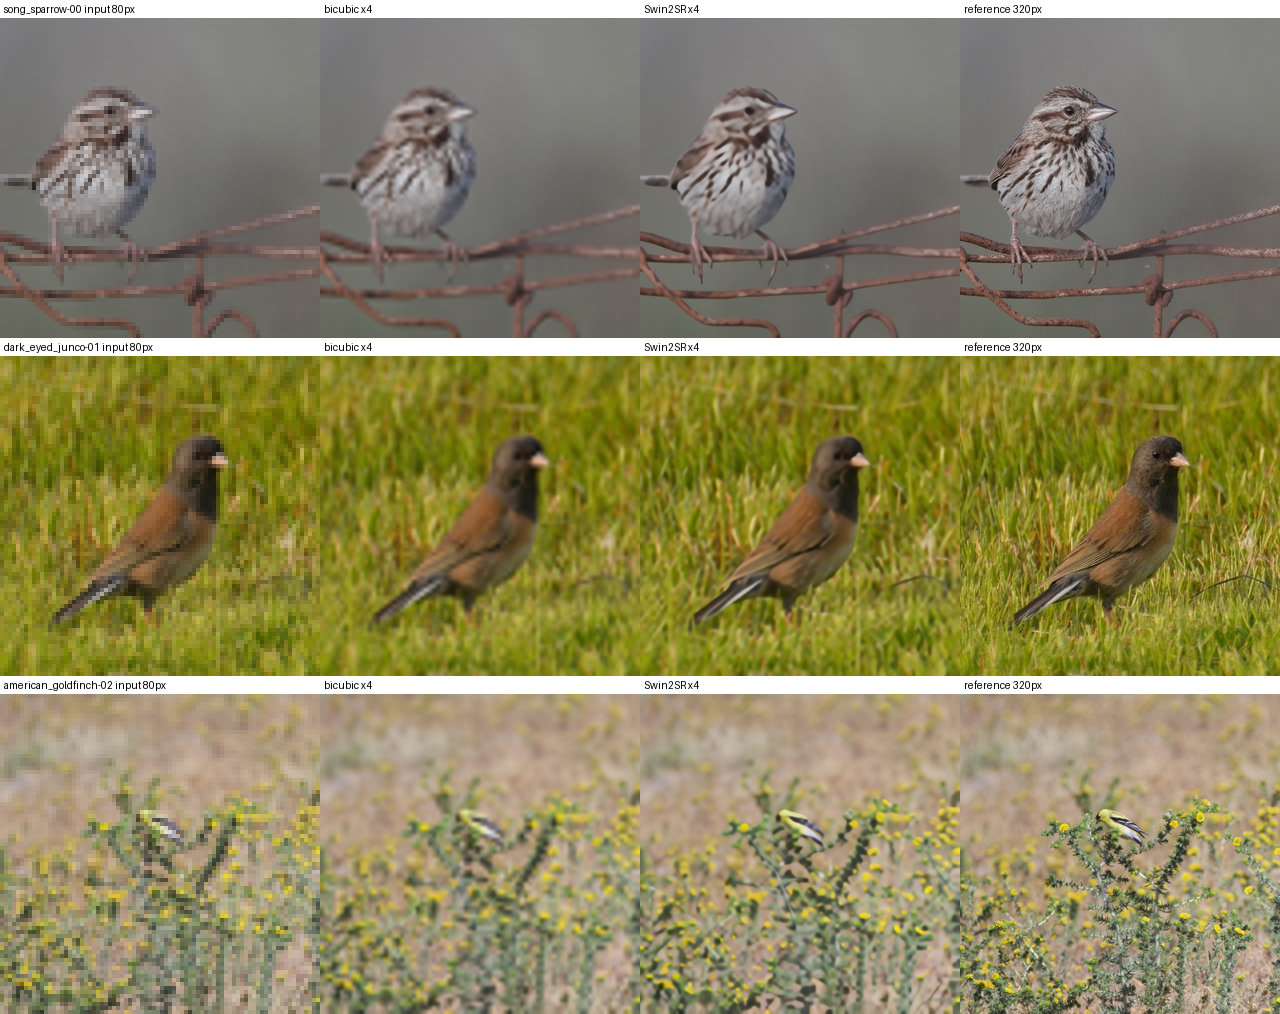

In [ ]:
run_stage('evaluate')
show_image('swin2sr_x4_super_resolution_panels.png', 'Input (80 px, enlarged for display) | bicubic x4 | Swin2SR x4 | reference (320 px)')

**What to notice:** the `psnr_y`, `ssim_y` and `psnr_rgb` rows each list nearest, bicubic and model means; the `model_minus_bicubic` rows give the mean per-image difference, its 95 % bootstrap interval, and how many of the 24 images the model won; one line per species follows — **four crops per species, descriptive only**: four images cannot rank species, so do not read a difference between species lines as a property of the birds. In the panels, compare feather edges and the background: bicubic is smooth and soft, the model's output has crisper edges. The per-image numbers are in `outputs/swin2sr_x4_super_resolution_scores.csv`, every output image in `outputs/swin2sr_x4_super_resolution_sample_outputs/`, and the full record in `outputs/swin2sr_x4_super_resolution_evaluation_report.json`.

**Checkpoint:** suppose, as in the recorded T4 run, the model wins by a few dB on average (there +2.69 dB PSNR-Y, 95 % bootstrap interval 2.09 to 3.35) and on every one of the 24 images. What does that interval tell you, and what does it *not* tell you?

<details>
<summary>Check your reasoning (open after answering)</summary>

The interval says that, among images like these 24, the average advantage is unlikely to be zero: resampling the per-image differences rarely produces a mean near zero. It does not say the model wins on every image (read `wins`), it does not extend to other kinds of images (all 24 are centred crops of bird photographs from one website, shrunk by one filter), and it says nothing about how the output looks to a person — PSNR rewards getting average brightness right and penalises plausible texture placed slightly wrong, so a sharper-looking image can score lower. Two further limits: the comparison is one deterministic pass, so the interval reflects image-to-image variation only; and because the photos are public, overlap with the model's training data cannot be ruled out, although the upstream training sets are general photo collections rather than iNaturalist. A win on every image here is a statement about these 24 bicubic crops, not a guarantee on yours. If your run shows a different gap, trust your run.

</details>

## 6. New-image inference and exported outputs · [Concept]

**Question tested:** what does the model produce on inputs that were *not* made by shrinking a sharper image, and what can be said about those outputs?

The `infer` stage upscales four reference-free inputs: three native 96 px crops of photographs outside the evaluation set, and a seeded synthetic scene of 100 × 76 px (gradient, sharp rectangle, ring, fine stripes, mild noise) whose odd size shows 4 px of padding on each padded side. It writes each output as a PNG with its SHA-256, a predictions CSV (input size, output size, padding, file, digest — one row per input id), a comparison panel, and `outputs/swin2sr_x4_super_resolution_result.json`: the model id and revision, the weight digest, device and precision, the runtime versions, the sample digest, the evaluation summary and every prediction. Finally it lists every file under `outputs/`.

**Predict before running:** on the native photo crops, will the model's output look as convincing as in Section 5? What will the synthetic scene's stripes look like?

Running stage 'infer' in the isolated environment; log: /content/outputs/swin2sr_x4_super_resolution/f80f1454373f/logs/infer.log


`self.pad_size` attribute is deprecated and will be removed in v5. Use `self.size_divisor` instead


{'id': 'new-song_sparrow-04', 'seconds': 0.5866, 'output_file': 'outputs/swin2sr_x4_super_resolution_new_outputs/new-song_sparrow-04_x4.png', 'input_size': (96, 96), 'output_size': (384, 384), 'padding': {'right': 8, 'bottom': 8, 'mode': 'symmetric', 'removed_after_upscale': True}}


{'id': 'new-dark_eyed_junco-04', 'seconds': 0.207, 'output_file': 'outputs/swin2sr_x4_super_resolution_new_outputs/new-dark_eyed_junco-04_x4.png', 'input_size': (96, 96), 'output_size': (384, 384), 'padding': {'right': 8, 'bottom': 8, 'mode': 'symmetric', 'removed_after_upscale': True}}


{'id': 'new-american_goldfinch-04', 'seconds': 0.1985, 'output_file': 'outputs/swin2sr_x4_super_resolution_new_outputs/new-american_goldfinch-04_x4.png', 'input_size': (96, 96), 'output_size': (384, 384), 'padding': {'right': 8, 'bottom': 8, 'mode': 'symmetric', 'removed_after_upscale': True}}


...

  - outputs/swin2sr_x4_super_resolution_scores.csv (2.4 KB)


  - outputs/weights.json (0.4 KB)


  - outputs/swin2sr_x4_super_resolution_sample_outputs/ (24 PNG files)


{'stage': 'infer', 'status': 'ok', 'seconds': 7.3}


New inputs (no reference): input | bicubic x4 | Swin2SR x4 -> /content/outputs/swin2sr_x4_super_resolution/f80f1454373f/outputs/swin2sr_x4_super_resolution_new_panels.png


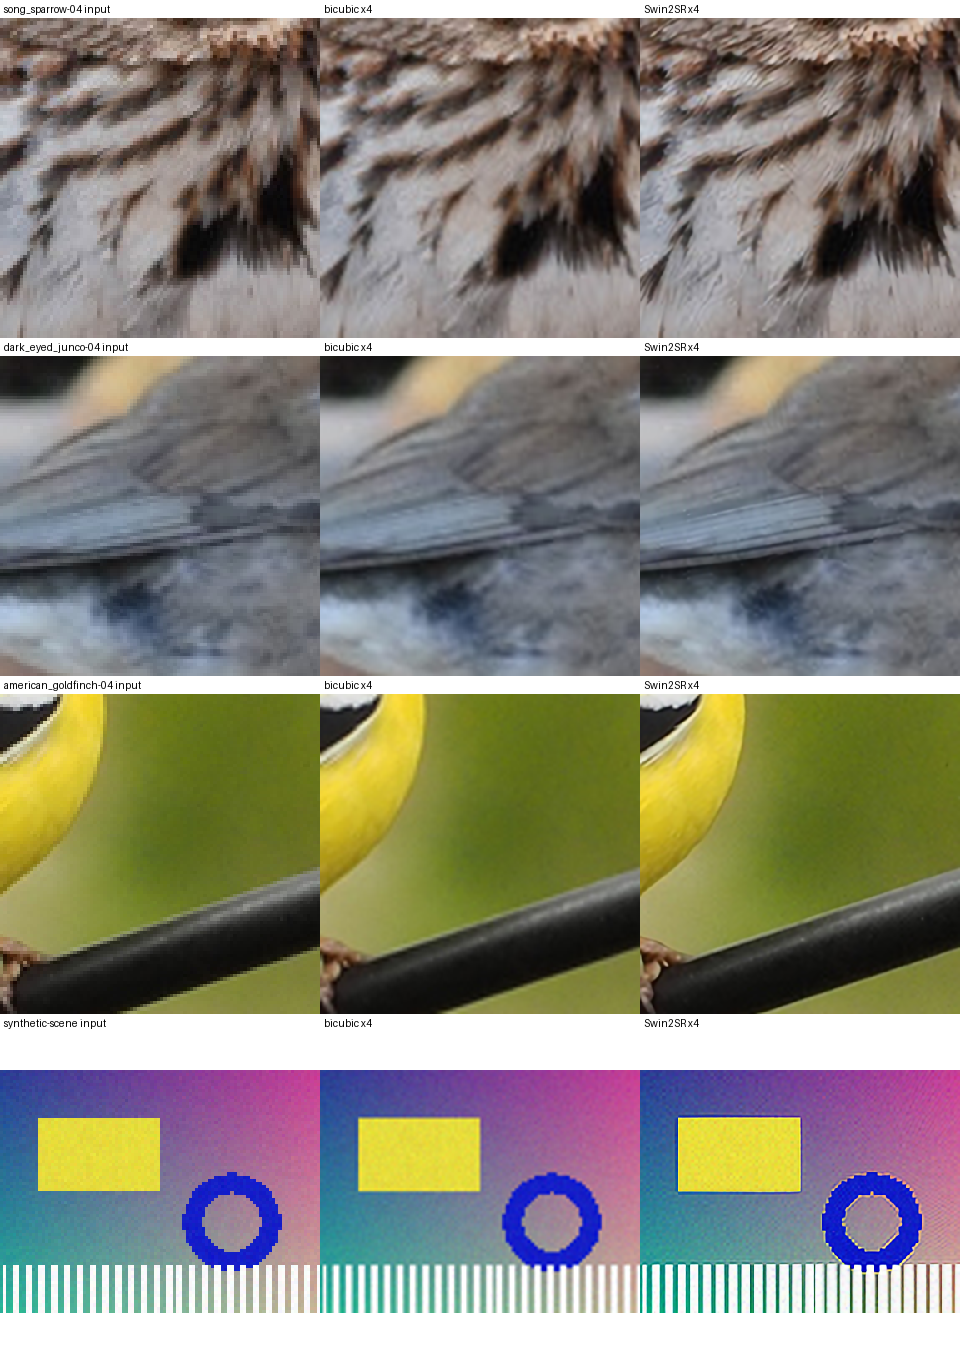

In [ ]:
run_stage('infer')
show_image('swin2sr_x4_super_resolution_new_panels.png', 'New inputs (no reference): input | bicubic x4 | Swin2SR x4')

**What to notice:** each new input prints its size, its 4x output size and its padding, and its `verdict` in the result record is `not-measurable`: there is no reference to score against. The native crops carry the camera's own blur, sharpening and JPEG compression, which is not the degradation the model learned to invert, so its added detail can look different from Section 5. The synthetic stripes are close to the finest pattern 96 px can hold; watch for invented or bent lines. This is the end of the canonical path; everything it produced is under `outputs/` in the run directory.

**Checkpoint:** a colleague says the output of a native crop "shows the bird's real feathers in 4x more detail". How would you correct them?

<details>
<summary>Check your reasoning (open after answering)</summary>

The extra pixels are the model's prediction of what a sharp original *might* have looked like, learned from training photographs; they are not information recovered from the scene. Without a reference there is no evidence that any particular added feather edge is real. A correct description is "a 4x enlargement whose added detail is synthetic". That distinction matters most when an output could be used as evidence — a face, a licence plate, a medical image — which is why the repository rules those uses out.

</details>

## Interpretation and limits · [Evaluation practice]

The question this notebook can answer is narrow: on 24 centred crops of CC0 bird photographs, shrunk 4x by Pillow's bicubic filter, does the pinned Swin2SR x4 checkpoint reconstruct the references more closely than bicubic or nearest-neighbour interpolation of the same inputs? Your run answers it in Section 5, with the per-image differences and a bootstrap interval; read the size and direction of the gap there rather than from this text.

The numbers are tutorial sample evidence, not a benchmark. PSNR and SSIM measure closeness to one reference, not perceived quality; 24 images from one source and one degradation give an interval over those images only; the upstream paper's Set5, Set14 or Urban100 results are not reproduced here and must not be quoted as this notebook's. On real small images (Section 6) the model's added detail cannot be scored at all.

Successful execution proves that the recorded repository revision's package and stage runner, carried in this standalone notebook and run in an isolated hash-locked environment, can stage and digest-verify the pinned safetensors snapshot, fetch and validate digest-pinned photographs, run 4x super-resolution with reported padding, score it against two baselines with a stated metric convention, run reference-free inference, and emit the shown machine-readable outputs — without the repository being reachable. It does **not** establish benchmark superiority, production fitness, or image quality beyond the checks shown.

## Conclude with evidence · [Evaluation practice]

Complete this in your own words, using the numbers your run printed:

> On [24 bicubic-downsampled 320 px bird-photo crops / your BYOD `hr` images], the Swin2SR classical x4 checkpoint reached a mean Y-PSNR of [model] dB against [bicubic] dB for bicubic and [nearest] dB for nearest-neighbour interpolation (SSIM [model] vs [bicubic]). The model won on [wins] of [n] images; the mean per-image difference to bicubic was [difference] dB with a 95 % bootstrap interval of [low, high]. The most important uncertainty or failure mode is [for example: one degradation and one image source; PSNR's blindness to perceived sharpness; invented detail on native crops]. These numbers do not show [behaviour on real low-resolution captures / perceived quality / other image types]. Next I would [specific next experiment].

<details>
<summary>Check your reasoning: what makes a conclusion strong? (open after writing yours)</summary>

A strong conclusion names the data (24 crops, one source, one degradation), reports the model beside **both** baselines, gives the paired difference with its interval and the win count rather than the mean alone, and states that PSNR and SSIM measure closeness to a reference, not perceived quality. It keeps the reference-free outputs of Section 6 out of the score, and does not generalise to other degradations — Section 7 is where that assumption is tested. It ends with a specific next step: more and more varied images, another degradation, or a perceptual comparison by people. A weak conclusion says only that "the model makes images sharper".

</details>

## 7. Optional activity: change one thing — the degradation · [Concept]

**Predict → Change one thing → Run → Observe → Explain.** This activity is off by default and changes nothing the canonical path produced: with `RUN_ACTIVITY = False` the next cell only prints how to switch it on. It runs the `activity` stage, which rebuilds the same 24 references, makes their inputs with a **different** degradation, and scores the model and bicubic again exactly as in Section 5. It downloads nothing new.

**Change one thing:** set `ACTIVITY_KERNEL` to `'bilinear'`, `'box'` or `'nearest'` (the downsampling filter), or keep `'bicubic'` and set `ACTIVITY_JPEG_QUALITY` to a value such as 30 to add JPEG compression after downsampling (0 means none). Then set `RUN_ACTIVITY = True` and run the cell. The references, the model and the metric stay fixed; only the way the input was made changes.

**Predict before running:** with box-filter or JPEG-compressed inputs, will the model's advantage over bicubic grow, shrink, or reverse? Write your prediction down.

In [ ]:
RUN_ACTIVITY = False  # @param {type:"boolean"}
ACTIVITY_KERNEL = 'bilinear'  # @param ["bicubic", "bilinear", "box", "nearest"]
ACTIVITY_JPEG_QUALITY = 0  # @param {type:"integer"}

if RUN_ACTIVITY:
    run_stage('activity', '--kernel', ACTIVITY_KERNEL, '--jpeg-quality', ACTIVITY_JPEG_QUALITY)
else:
    print({'activity': 'skipped (optional)', 'to_run': 'set RUN_ACTIVITY = True, choose ACTIVITY_KERNEL or ACTIVITY_JPEG_QUALITY, then run this cell'})

{'activity': 'skipped (optional)', 'to_run': 'set RUN_ACTIVITY = True, choose ACTIVITY_KERNEL or ACTIVITY_JPEG_QUALITY, then run this cell'}


**Observe:** two rows (`psnr_y`, `ssim_y`), each with the model and bicubic under the default bicubic-made inputs and under your degradation, then the model-minus-bicubic difference for both with the new bootstrap interval. The full record is `outputs/swin2sr_x4_super_resolution_activity.json`.

**Explain:** did the result match your prediction? Is the model's advantage a property of the model alone, or of the model *and* the degradation it was trained for?

<details>
<summary>Check your reasoning (open after answering)</summary>

A classical-SR model learns to invert one specific degradation. Change the filter and the input carries a different blur or aliasing pattern than the model expects; add JPEG and it carries 8 × 8 block artefacts that the model was never shown, which it often sharpens instead of removing. The usual result is that the advantage over bicubic shrinks, and with JPEG it can reverse — the x2 sibling of this checkpoint scored below bicubic on JPEG-compressed inputs. "Usually" is the honest word: 24 images are a small sample, and a result against that direction is an observation about this run. Only the degradation changed, so any difference is caused by it. The lesson carries to real data: before trusting an SR model's scores, ask how your small images were made.

</details>

## 8. Bring Your Own Data (optional) · [Evaluation practice]

This branch is off by default (`USE_BYOD = False`). It runs the same validation, inference and output contract as the sample path on your images, in one of two modes:

| `BYOD_MODE` | Your image is | What happens | Score |
|---|---|---|---|
| `'hr'` | the sharp original, 32..1024 px per side | cropped on the right/bottom to a multiple of 4 px if needed (the removed pixels are reported), shrunk 4x by bicubic, validated, upscaled | Y-PSNR, SSIM and RGB PSNR against your original, beside bicubic and nearest-neighbour |
| `'lr'` | the small input, 8..256 px per side | validated (converted to RGB, alpha discarded, padding reported), upscaled 4x | none — there is no reference |

**Accepted files:** one image, a folder, or a zip of up to 64 images (PNG, JPEG, BMP, TIFF or WebP; at most 4096 × 4096 decoded pixels each; 200 MB in total). Each file name becomes the output id, so names must be distinct. Zips are read in memory, never extracted: absolute paths, `..` traversal and symbolic links are refused. **Nothing is resized silently** — an image outside the limits is refused with a message that names the file, the rule and the fix, before any model is loaded.

**Where your data goes:** uploaded files are written under this run's directory in the runtime and read only by the `byod` stage; nothing is sent anywhere. Do not upload confidential or restricted data unless you are authorized to process it in this hosted runtime.

**How to run it:** set `USE_BYOD = True` and choose `BYOD_MODE`. Either set `BYOD_PATH` to a file, folder or zip that is already in the runtime (for example one you copied in from mounted storage), or leave it empty to get an upload dialog (Google Colab only). Then run the cell.

In [ ]:
USE_BYOD = False  # @param {type:"boolean"}
BYOD_MODE = 'hr'  # @param ["hr", "lr"]
BYOD_PATH = ''  # @param {type:"string"}

if USE_BYOD:
    if BYOD_PATH:
        byod_path = Path(BYOD_PATH)
    else:
        from google.colab import files
        uploaded = files.upload()
        byod_path = ROOT / 'byod' / uuid.uuid4().hex[:8]
        byod_path.mkdir(parents=True)
        for file_name, payload in uploaded.items():
            (byod_path / Path(file_name).name).write_bytes(payload)
    run_stage('byod', '--byod-path', byod_path.resolve(), '--byod-mode', BYOD_MODE)
    show_image('swin2sr_x4_super_resolution_byod_' + BYOD_MODE + '/panels.png', 'Your images: input | bicubic x4 | Swin2SR x4' + (' | your original' if BYOD_MODE == 'hr' else ''))
else:
    print({'byod': 'skipped (optional)', 'to_run': "set USE_BYOD = True, BYOD_MODE = 'hr' or 'lr', and optionally BYOD_PATH, then run this cell"})

{'byod': 'skipped (optional)', 'to_run': "set USE_BYOD = True, BYOD_MODE = 'hr' or 'lr', and optionally BYOD_PATH, then run this cell"}


**What to notice:** one line per image with its input size, output size, padding and any preprocessing (for `'hr'`, whether pixels were cropped to reach a multiple of 4); in `'hr'` mode, per-image scores and — with two or more images — the same comparison table as Section 5. Results go to `outputs/swin2sr_x4_super_resolution_byod_<mode>/`: the 4x PNGs with their SHA-256, a panel, and `byod_result.json` with the input manifest, preprocessing, scores and provenance. An invalid image stops the cell with `RuntimeError: Stage 'byod' failed …` followed by the validator's own message, for example `longer side 300 px > MAX_INPUT_SIDE 256 … crop or downscale the input`.

Remember that `'hr'` mode scores your images under a degradation the notebook made, so it tells you how the model handles your *content*, not how it handles your camera's real small images.

## Troubleshooting · [Engineering]

| Symptom | Likely cause | What to do |
|---|---|---|
| Section 1 stops with `This notebook needs a Linux x86_64 runtime` | a local Windows or macOS kernel, or an ARM machine | Use Google Colab, Kaggle, or a Linux x86_64 machine: the locked environment is built for manylinux x86_64 wheels. |
| Section 1 prints `none: the stages will run on the CPU` | no GPU is attached | Nothing to fix: the notebook works on the CPU. For speed, choose *Runtime → Change runtime type → T4 GPU* and run all again from the top. |
| Section 1 stops with `Not enough free disk` | the check asks for about 7 GB for the isolated environment (5.5 GB measured, plus a margin) | Start a fresh runtime with more free disk; an environment built from the same lock earlier in this runtime is reused and needs no more. |
| `The run directory … has no carried files, or the isolated environment is gone: run the three Infrastructure cells again in order (Sections 1, 2 and 3)` | Section 1 was run with `NEW_RUN_DIRECTORY` ticked (a fresh, empty run directory), or the runtime's temporary directory was cleared | Run Sections 1, 2 and 3 again in order, then the cell you wanted, or choose *Runtime → Run all*. Re-running the Section 1 cell on its own with the default setting keeps the run directory and needs nothing else. |
| `Carried file integrity failure` in Section 2 | a carried file was edited in the notebook | Do not edit the infrastructure cells; open a fresh copy of the notebook from the repository. |
| `uv 0.12.15 wheel size/hash mismatch`, or a `URLError` / timeout while downloading it | a network failure or an unexpected response from PyPI | Re-run the Section 2 install cell. Never replace the pinned URL or digest. |
| `CalledProcessError` from `uv venv` or `uv pip install` (a hash mismatch, `Failed to download`, HTTP 5xx) | a transient PyPI or network failure | Re-run the Section 2 install cell: `uv` reuses what it already downloaded. If a hash mismatch repeats, stop and report it — never remove `--require-hashes`, a pin or a hash to get past it. |
| `RuntimeError: Stage '…' failed (exit 2): …` | the stage raised an error; the text after the colon is the stage's own message, and its full log (with the traceback) is printed above it and kept in the run directory's `logs/` | Find the message in the rows below. A stage reads only files, so after fixing the cause you can re-run that cell and the cells after it. |
| Section 3: `this notebook revision carries no immutable revision` | the notebook was generated before the maintainer pinned the snapshot (`MODEL_REVISION = "unpinned"`) | Use a newer copy of the notebook from the repository. A maintainer runs `python tools/pin_snapshot.py` where huggingface.co is reachable, commits the manifest and regenerates the notebook. Never edit the manifest or the revision by hand. |
| A download error (timeout, HTTP 429/5xx) in Section 3 | a transient Hugging Face Hub failure | Re-run the Section 3 cell: staging only fetches the files that are still absent. |
| `ValueError: ...: size ... != manifest ...` or `sha256 ... != manifest ...` | a partial or corrupted download | Delete the named file under `weights/` and re-run the Section 3 cell. Never edit a manifest to get past a mismatch. |
| A photograph fetch fails in Section 4 (`URLError`, or `... bytes, pinned ...` / `sha256 ... != pinned ...`) | a network failure or an unexpected response from the iNaturalist bucket | Re-run the Section 4 cell; photographs already verified are kept in `weights/inat-birds/` and reused. A repeated digest mismatch means the served file changed: do not use it. |
| `… is missing: run the stage that writes it before …` | a learner cell was run before an earlier stage | Run the notebook from the top, or re-run the earlier cells in order. |
| `CUDA out of memory` | another program holds GPU memory | Re-run the cell: each stage is its own process, so the failed stage's memory was released. Inputs are capped at 256 px, so the model alone needs well under 1 GB. |
| `ModuleNotFoundError: No module named 'google.colab'` with `USE_BYOD = True` | the upload dialog needs Google Colab | Set `BYOD_PATH` to a file, folder or zip already in the runtime. |
| `BYOD path not found` | `BYOD_PATH` points nowhere | Check the path with the file browser; relative paths are resolved from the notebook's working directory. |
| `longer side … > MAX_INPUT_SIDE 256` (`'lr'` mode) or `longer side … > 1024 px` (`'hr'` mode) | the image is above the size ceiling | Crop or downscale it yourself; the notebook never resizes silently. |
| `too small to score in 'hr' mode` or `shorter side … < MIN_INPUT_SIDE 8` | the image is below the size floor | Use `'lr'` mode for a small input, or a larger original. |
| `not image files: [...]`, `not a decodable image`, `duplicate file names` or `has an absolute or parent-relative path` | the folder or zip holds other files, a corrupt image, two files with one name, or unsafe paths | Keep only distinct, decodable images in the folder or zip, with plain relative names. |

## Transfer

**Transfer:** switch on BYOD (Section 8) in `'hr'` mode with three or more sharp photographs of a different kind — text, architecture, satellite tiles, microscope images — and write the conclusion above for them. Before running, predict whether the model's advantage over bicubic will be larger or smaller than on the bird crops, and why. Then try one of your own small images in `'lr'` mode and describe its output without claiming that the added detail is real.

## References

- Conde, M. V., Choi, U.-J., Burchi, M., & Timofte, R. (2023). Swin2SR: SwinV2 transformer for compressed image super-resolution and restoration. In *Computer Vision – ECCV 2022 Workshops* (pp. 669–687). Springer. https://doi.org/10.1007/978-3-031-25063-7_42
- Efron, B. (1979). Bootstrap methods: Another look at the jackknife. *The Annals of Statistics, 7*(1), 1–26. https://doi.org/10.1214/aos/1176344552
- Liu, Z., Hu, H., Lin, Y., Yao, Z., Xie, Z., Wei, Y., Ning, J., Cao, Y., Zhang, Z., Dong, L., Wei, F., & Guo, B. (2022). Swin Transformer V2: Scaling up capacity and resolution. In *Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition* (pp. 12009–12019). https://doi.org/10.1109/CVPR52688.2022.01170
- Wang, Z., & Bovik, A. C. (2009). Mean squared error: Love it or leave it? A new look at signal fidelity measures. *IEEE Signal Processing Magazine, 26*(1), 98–117. https://doi.org/10.1109/MSP.2008.930649
- Wang, Z., Bovik, A. C., Sheikh, H. R., & Simoncelli, E. P. (2004). Image quality assessment: From error visibility to structural similarity. *IEEE Transactions on Image Processing, 13*(4), 600–612. https://doi.org/10.1109/TIP.2003.819861
- Hugging Face model repository: https://huggingface.co/caidas/swin2SR-classical-sr-x4-64 (revision `c69ef3e2d2ac5777ff4a9f2f5afcd86d20604b7e` as carried in the manifest)
- Upstream code: https://github.com/mv-lab/swin2sr
- Repository README: https://github.com/kurtvalcorza/swin2sr-x4-super-resolution-pipeline/blob/main/README.md
- Repository model card: https://github.com/kurtvalcorza/swin2sr-x4-super-resolution-pipeline/blob/main/MODEL_CARD.md
- Weights notes: https://github.com/kurtvalcorza/swin2sr-x4-super-resolution-pipeline/blob/main/docs/WEIGHTS.md
- uv (the installer that builds the isolated environment): https://docs.astral.sh/uv/
- DIMER Notebook Specification 2.2 and Model Card Specification 1.2 (in the ml-worker repository)